In [3]:
!brew install git-lfs

==> Auto-updating Homebrew...
Adjust how often this is run with `$HOMEBREW_AUTO_UPDATE_SECS` or disable with
`$HOMEBREW_NO_AUTO_UPDATE=1`. Hide these hints with `$HOMEBREW_NO_ENV_HINTS=1` (see `man brew`).
⠋ JSON API packages.arm64_tahoe.jws.json⠋ JSON API packages.arm64_tahoe.jws.json⠙ JSON API packages.arm64_tahoe.jws.json⠙ JSON API packages.arm64_tahoe.jws.json⠚ JSON API packages.arm64_tahoe.jws.json⠚ JSON API packages.arm64_tahoe.jws.json             Downloading 110.6KB/-------⠞ JSON API packages.arm64_tahoe.jws.json             Downloading 602.1KB/-------⠞ JSON API packages.arm64_tahoe.jws.json             Downloading   2.7MB/-------⠖ JSON API packages.arm64_tahoe.jws.json             Downloading   4.0MB/-------⠖ JSON API packages.arm64_tahoe.jws.json             Downloading   5.5MB/-------⠦ JSON API packages.arm64_tahoe.jws.json             Downloading   5.5MB/-------⠦ JSON API packages.arm64_tahoe.jws.json             Downloading   5.5MB/-------⠴ JSON API packages.arm64_tahoe.jw

In [5]:
!git lfs install
!git clone https://github.com/MuseumofModernArt/collection.git

Git LFS initialized.
Cloning into 'collection'...
remote: Enumerating objects: 1593, done.
remote: Counting objects: 100% (426/426), done.
remote: Compressing objects: 100% (120/120), done.
remote: Total 1593 (delta 374), reused 343 (delta 306), pack-reused 1167 (from 3)
Receiving objects: 100% (1593/1593), 36.99 MiB | 8.10 MiB/s, done.
Resolving deltas: 100% (502/502), done.
Filtering content: 100% (4/4), 211.92 MiB | 5.85 MiB/s, done.


In [6]:
!git lfs install && git clone https://github.com/MuseumofModernArt/collection.git

Git LFS initialized.
fatal: destination path 'collection' already exists and is not an empty directory.


In [11]:
import pandas as pd
df = pd.read_csv('collection/Artworks.csv', low_memory=False)
print(df.columns.tolist())
print(df.shape)
df[['Title','Artist','Nationality','CreditLine','DateAcquired']].head(10)


['Title', 'Artist', 'ConstituentID', 'ArtistBio', 'Nationality', 'BeginDate', 'EndDate', 'Gender', 'Date', 'Medium', 'Dimensions', 'CreditLine', 'AccessionNumber', 'Classification', 'Department', 'DateAcquired', 'Cataloged', 'ObjectID', 'URL', 'ImageURL', 'OnView', 'Circumference (cm)', 'Depth (cm)', 'Diameter (cm)', 'Height (cm)', 'Length (cm)', 'Weight (kg)', 'Width (cm)', 'Seat Height (cm)', 'Duration (sec.)']
(160597, 30)


,Title,Artist,Nationality,CreditLine,DateAcquired
0,"Ferdinandsbrücke Project, Vienna, Austria (Ele...",Otto Wagner,(Austrian),Fractional and promised gift of Jo Carole and ...,1996-04-09
1,"City of Music, National Superior Conservatory ...",Christian de Portzamparc,(French),Gift of the architect in honor of Lily Auchinc...,1995-01-17
2,"Villa project, outside Vienna, Austria (Elevat...",Emil Hoppe,(Austrian),Gift of Jo Carole and Ronald S. Lauder,1997-01-15
3,"The Manhattan Transcripts Project, New York, N...",Bernard Tschumi,(),Purchase and partial gift of the architect in ...,1995-01-17
4,"Villa project, outside Vienna, Austria (Exteri...",Emil Hoppe,(Austrian),Gift of Jo Carole and Ronald S. Lauder,1997-01-15
5,"The Manhattan Transcripts Project, New York, N...",Bernard Tschumi,(),Purchase and partial gift of the architect in ...,1995-01-17
6,"The Manhattan Transcripts Project, New York, N...",Bernard Tschumi,(),Purchase and partial gift of the architect in ...,1995-01-17
7,"The Manhattan Transcripts Project, New York, N...",Bernard Tschumi,(),Purchase and partial gift of the architect in ...,1995-01-17
8,"The Manhattan Transcripts Project, New York, N...",Bernard Tschumi,(),Purchase and partial gift of the architect in ...,1995-01-17
9,"The Manhattan Transcripts Project, New York, N...",Bernard Tschumi,(),Purchase and partial gift of the architect in ...,1995-01-17


In [12]:
for i, col in enumerate(df.columns.tolist()):
    print(f"{i:02d}. {col}")
    print(f"     non-null: {df[col].notna().sum():,} / {len(df):,}")
    print(f"     sample: {df[col].dropna().iloc[0] if df[col].notna().any() else 'ALL NULL'}")
    print()

00. Title
     non-null: 160,549 / 160,597
     sample: Ferdinandsbrücke Project, Vienna, Austria (Elevation, preliminary version)

01. Artist
     non-null: 159,339 / 160,597
     sample: Otto Wagner

02. ConstituentID
     non-null: 159,339 / 160,597
     sample: 6210

03. ArtistBio
     non-null: 153,911 / 160,597
     sample: (Austrian, 1841–1918)

04. Nationality
     non-null: 159,339 / 160,597
     sample: (Austrian)

05. BeginDate
     non-null: 159,339 / 160,597
     sample: (1841)

06. EndDate
     non-null: 159,339 / 160,597
     sample: (1918)

07. Gender
     non-null: 159,339 / 160,597
     sample: (male)

08. Date
     non-null: 158,584 / 160,597
     sample: 1896

09. Medium
     non-null: 151,827 / 160,597
     sample: Ink and cut-and-pasted painted pages on paper

10. Dimensions
     non-null: 152,248 / 160,597
     sample: 19 1/8 x 66 1/2" (48.6 x 168.9 cm)

11. CreditLine
     non-null: 159,241 / 160,597
     sample: Fractional and promised gift of Jo Carole and Ron

In [14]:
print("=== ACQUISITION ===")
print(df['DateAcquired'].dropna().sort_values().tail(5))

print("\n=== CATALOGED ===")
print(df['Cataloged'].dropna().sort_values().tail(5))


=== ACQUISITION ===
160424    2026-05-27
160419    2026-05-27
160313    2026-05-27
160232    2026-05-27
160596    2026-05-27
Name: DateAcquired, dtype: str

=== CATALOGED ===
68007    Y
68006    Y
68004    Y
68002    Y
80298    Y
Name: Cataloged, dtype: str


In [21]:
def classify_credit(text):
    if pd.isna(text):
        return 'Unknown'
    t = text.lower()
    if 'gift of the artist' in t:
        return 'Gift of the artist'
    elif 'promised gift' in t or 'fractional and promised' in t:
        return 'Promised gift'
    elif 'fractional gift' in t:
        return 'Fractional gift'
    elif 'purchase' in t and 'gift' in t:
        return 'Purchase and gift (mixed)'
    elif 'gift' in t:
        return 'Gift'
    elif 'purchase' in t:
        return 'Purchase'
    elif 'bequest' in t:
        return 'Bequest'
    elif 'fund' in t:
        return 'Fund'
    elif 'exchange' in t:
        return 'Exchange'
    elif 'transfer' in t:
        return 'Transfer'
    elif 'anonymous' in t:
        return 'Anonymous'
    else:
        return 'Other'

df['AcquisitionType'] = df['CreditLine'].apply(classify_credit)

print("=== ACQUISITION TYPE BREAKDOWN ===")
counts = df['AcquisitionType'].value_counts()
total = len(df)
for acq_type, count in counts.items():
    print(f"  {acq_type}: {count:,} ({count/total*100:.1f}%)")

print("\n=== TOP 30 DONORS (by name frequency in CreditLine) ===")
# Extract donor names — text after 'gift of' or 'purchase of'
def extract_donor(text):
    if pd.isna(text):
        return None
    t = text.lower()
    for pattern in ['gift of ', 'bequest of ', 'purchase of ']:
        if pattern in t:
            idx = t.index(pattern) + len(pattern)
            return text[idx:].strip()
    return None

df['Donor'] = df['CreditLine'].apply(extract_donor)
top_donors = df['Donor'].value_counts().head(30)
for donor, count in top_donors.items():
    print(f"  {count:,}x — {donor}")

=== ACQUISITION TYPE BREAKDOWN ===
  Gift: 80,930 (50.4%)
  Fund: 30,560 (19.0%)
  Other: 19,809 (12.3%)
  Gift of the artist: 12,096 (7.5%)
  Purchase: 10,282 (6.4%)
  Bequest: 1,858 (1.2%)
  Anonymous: 1,536 (1.0%)
  Unknown: 1,356 (0.8%)
  Purchase and gift (mixed): 929 (0.6%)
  Transfer: 736 (0.5%)
  Exchange: 389 (0.2%)
  Promised gift: 110 (0.1%)
  Fractional gift: 6 (0.0%)

=== TOP 30 DONORS (by name frequency in CreditLine) ===
  17,205x — the architect
  10,867x — the artist
  2,733x — Kleiner, Bell & Co.
  2,046x — Jack Shear
  1,889x — Abby Aldrich Rockefeller
  1,688x — The Judith Rothschild Foundation
  1,341x — Peter J. Cohen
  1,329x — the designer
  1,270x — the manufacturer
  1,084x — Philip Johnson
  952x — Mr. and Mrs. Ralph F. Colin
  723x — Lawrence Benenson and the Committee on Architecture and Design Funds
  648x — Emily Fisher Landau
  553x — the Roy Lichtenstein Foundation in honor of Jennifer Winkworth and Kynaston McShine and in memory of Harry Shunk and Jáno

In [28]:
# What does "Fund" actually look like in the raw data?
funds = df[df['AcquisitionType'] == 'Fund']
print(f"Total classified as Fund: {len(funds):,}")
print(f"\nAll unique CreditLine variations containing 'fund':")
print(funds['CreditLine'].value_counts().head(40).to_string())

Total classified as Fund: 30,560

All unique CreditLine variations containing 'fund':
CreditLine
Abbott-Levy Collection. Acquired through the generosity of Shirley C. Burden, and Family of Man Fund                                                                                                                                                                                                                                                                                   4909
Fund for the Twenty-First Century                                                                                                                                                                                                                                                                                                                                                      1727
John B. Turner Fund                                                                                                                            

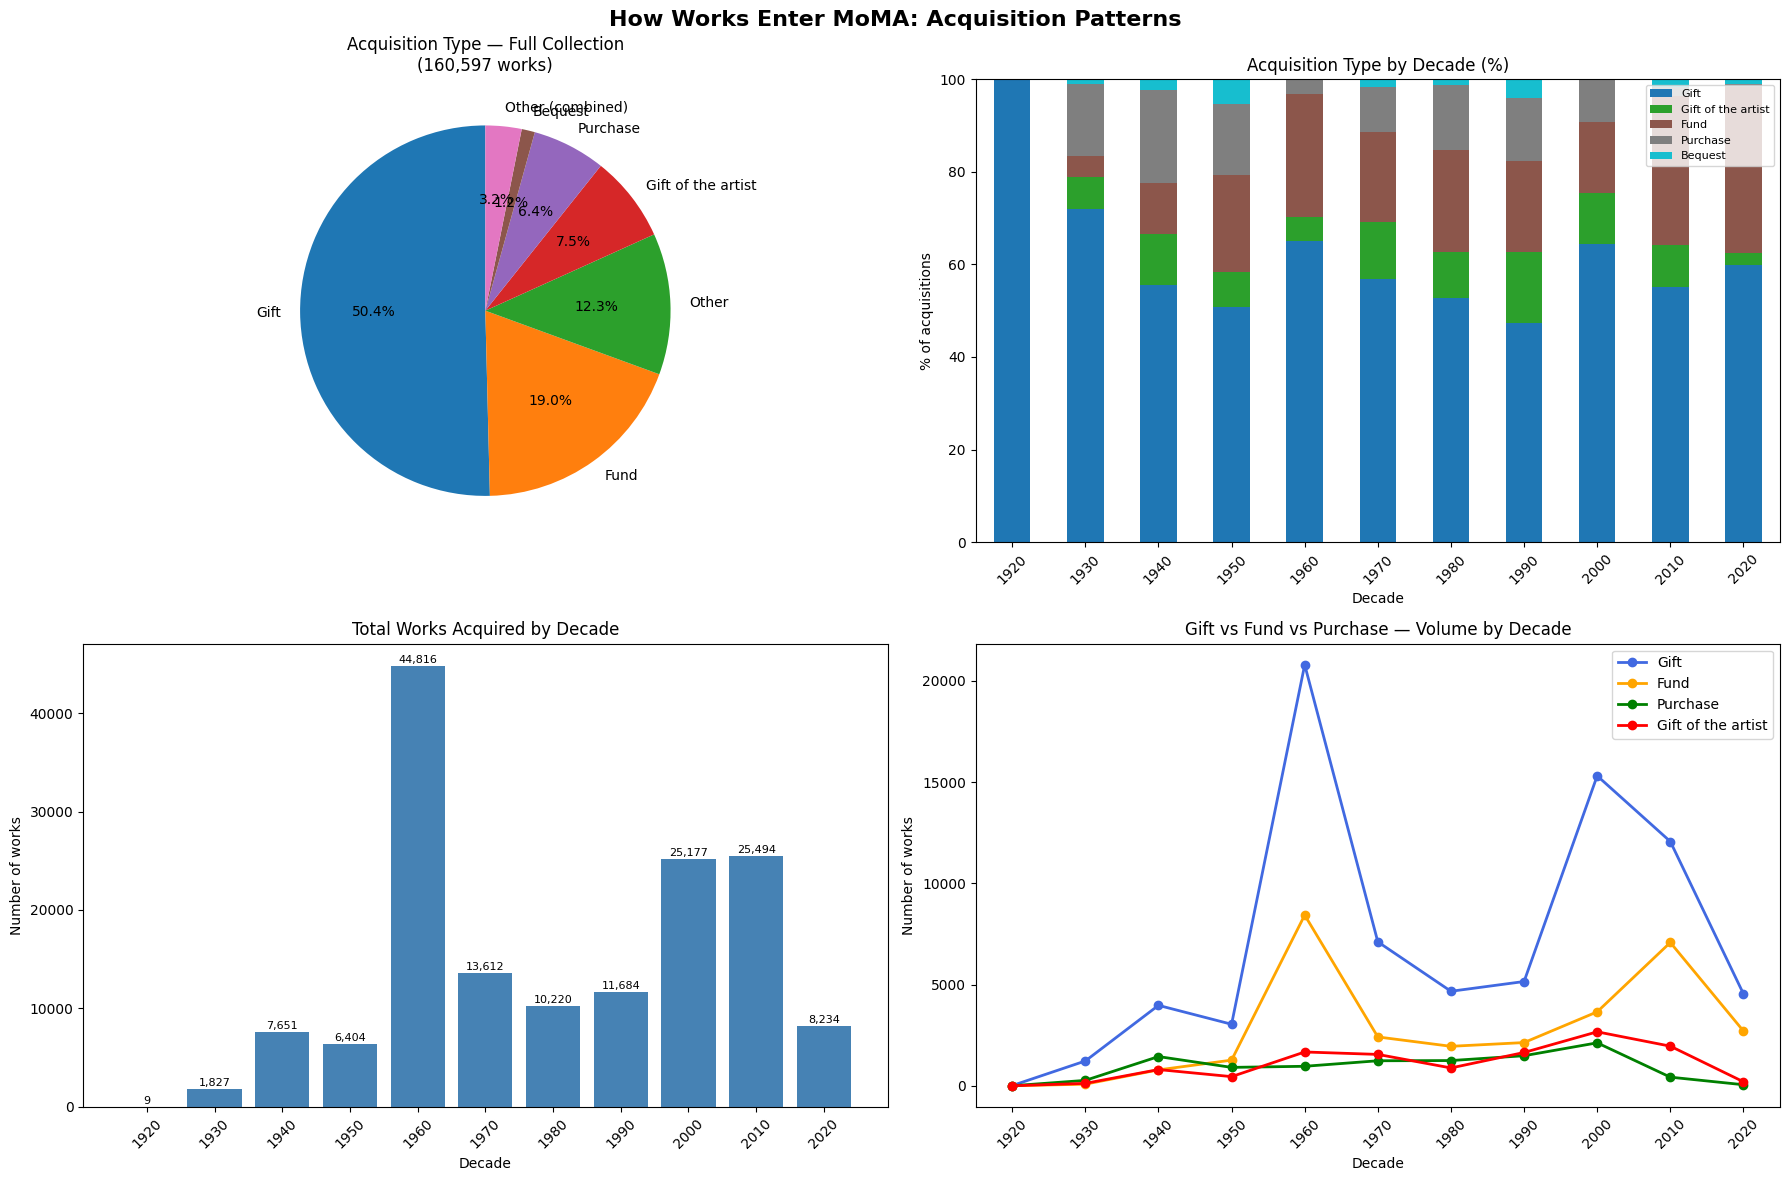

Saved.


In [26]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('How Works Enter MoMA: Acquisition Patterns', fontsize=16, fontweight='bold')

# ── Chart 1: Acquisition type overall (pie) ──
ax1 = axes[0, 0]
type_counts = df['AcquisitionType'].value_counts()
# Group small categories
threshold = len(df) * 0.01
main = type_counts[type_counts >= threshold]
other_sum = type_counts[type_counts < threshold].sum()
if other_sum > 0:
    main['Other (combined)'] = other_sum
ax1.pie(main.values, labels=main.index, autopct='%1.1f%%', startangle=90)
ax1.set_title('Acquisition Type — Full Collection\n(160,597 works)')

# ── Chart 2: Acquisition type by decade (stacked bar) ──
ax2 = axes[0, 1]
decade_type = df.groupby(['Decade', 'AcquisitionType']).size().unstack(fill_value=0)
main_types = ['Gift', 'Gift of the artist', 'Fund', 'Purchase', 'Bequest']
available = [c for c in main_types if c in decade_type.columns]
decade_type_pct = decade_type[available].div(decade_type[available].sum(axis=1), axis=0) * 100
decade_type_pct = decade_type_pct[decade_type_pct.index.notna()]
decade_type_pct.index = decade_type_pct.index.astype(int)
decade_type_pct.plot(kind='bar', stacked=True, ax=ax2, colormap='tab10')
ax2.set_title('Acquisition Type by Decade (%)')
ax2.set_xlabel('Decade')
ax2.set_ylabel('% of acquisitions')
ax2.legend(loc='upper right', fontsize=8)
ax2.tick_params(axis='x', rotation=45)

# ── Chart 3: Volume of acquisitions by decade ──
ax3 = axes[1, 0]
decade_volume = df.groupby('Decade').size()
decade_volume = decade_volume[decade_volume.index.notna()]
decade_volume.index = decade_volume.index.astype(int)
bars = ax3.bar(decade_volume.index.astype(str), decade_volume.values, color='steelblue')
ax3.set_title('Total Works Acquired by Decade')
ax3.set_xlabel('Decade')
ax3.set_ylabel('Number of works')
ax3.tick_params(axis='x', rotation=45)
for bar, val in zip(bars, decade_volume.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'{val:,}', ha='center', va='bottom', fontsize=8)

# ── Chart 4: Purchase vs Gift vs Fund over time (line) ──
ax4 = axes[1, 1]
for acq_type, color in [('Gift', 'royalblue'), ('Fund', 'orange'), 
                          ('Purchase', 'green'), ('Gift of the artist', 'red')]:
    if acq_type in decade_type.columns:
        data = decade_type[acq_type]
        data = data[data.index.notna()]
        data.index = data.index.astype(int)
        ax4.plot(data.index.astype(str), data.values, 
                marker='o', label=acq_type, color=color, linewidth=2)
ax4.set_title('Gift vs Fund vs Purchase — Volume by Decade')
ax4.set_xlabel('Decade')
ax4.set_ylabel('Number of works')
ax4.legend()
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('data/acquisition_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [27]:
# Check what years we actually have
print("=== YEARS IN DATASET ===")
print(df['YearAcquired'].value_counts().sort_index().tail(20))

# Check decade grouping
print("\n=== DECADE GROUPING CHECK ===")
print(df[df['YearAcquired'] >= 2019][['YearAcquired', 'Decade']].value_counts().sort_index())

=== YEARS IN DATASET ===
YearAcquired
2007.0    2362
2008.0    7438
2009.0    1537
2010.0    2074
2011.0    1921
2012.0    2962
2013.0    3127
2014.0    2866
2015.0    3882
2016.0    2060
2017.0    1800
2018.0    2507
2019.0    2295
2020.0    2627
2021.0     922
2022.0    1639
2023.0     470
2024.0    1214
2025.0     839
2026.0     523
Name: count, dtype: int64

=== DECADE GROUPING CHECK ===
YearAcquired  Decade
2019.0        2010      2295
2020.0        2020      2627
2021.0        2020       922
2022.0        2020      1639
2023.0        2020       470
2024.0        2020      1214
2025.0        2020       839
2026.0        2020       523
Name: count, dtype: int64


In [54]:
# How many "generosity" acquisitions are in our PURCHASE category?
purchase_works = df_gender[df_gender['AcquisitionFinal'] == 'PURCHASE']

generosity = purchase_works[
    purchase_works['CreditLine'].str.contains('generosity', case=False, na=False)
]

print(f"=== 'ACQUIRED THROUGH GENEROSITY' IN PURCHASE CATEGORY ===")
print(f"Total: {len(generosity):,} ({len(generosity)/len(purchase_works)*100:.1f}% of all PURCHASE)")
print(f"\nTop CreditLines:")
print(generosity['CreditLine'].value_counts().head(15).to_string())

=== 'ACQUIRED THROUGH GENEROSITY' IN PURCHASE CATEGORY ===
Total: 10,864 (23.8% of all PURCHASE)

Top CreditLines:
CreditLine
Abbott-Levy Collection. Acquired through the generosity of Shirley C. Burden, and Family of Man Fund                                                                                                                                                                                                                                                                                                    4909
Acquired through the generosity of the family of August Sander                                                                                                                                                                                                                                                                                                                                           669
Acquired through the generosity of Jon L. Stryker and Committee on Photography F

In [104]:
print("=== SELF-DONATIONS: ARTIST, ARCHITECT, DESIGNER ===\n")

self_donors = {
    'Gift of the artist':      df[df['CreditLine'].str.contains('gift of the artist', case=False, na=False)],
    'Gift of the architect':   df[df['CreditLine'].str.contains('gift of the architect', case=False, na=False)],
    'Gift of the architects':  df[df['CreditLine'].str.contains('gift of the architects', case=False, na=False)],
    'Gift of the designer':    df[df['CreditLine'].str.contains('gift of the designer', case=False, na=False)],
    'Gift of the photographer':df[df['CreditLine'].str.contains('gift of the photographer', case=False, na=False)],
    'Gift of the manufacturer':df[df['CreditLine'].str.contains('gift of the manufacturer', case=False, na=False)],
}

total = len(df)
self_total = 0

for label, subset in self_donors.items():
    count = len(subset)
    self_total += count
    pct = count/total*100
    print(f"{label}: {count:,} ({pct:.1f}%)")
    print(f"  Departments: {dict(subset['Department'].value_counts().head(3))}")
    print(f"  Top nationalities: {dict(subset['Nationality'].value_counts().head(5))}")
    print()

print(f"TOTAL SELF-DONATIONS: {self_total:,} ({self_total/total*100:.1f}% of full collection)")
print(f"\nAs % of all DONATIONS ({len(df[df['AcquisitionFinal']=='DONATION']):,}):")
print(f"  {self_total/len(df[df['AcquisitionFinal']=='DONATION'])*100:.1f}%")

=== SELF-DONATIONS: ARTIST, ARCHITECT, DESIGNER ===

Gift of the artist: 12,096 (7.5%)
  Departments: {'Drawings & Prints': np.int64(7302), 'Photography': np.int64(3739), 'Media and Performance': np.int64(517)}
  Top nationalities: {'(American)': np.int64(8137), '(French)': np.int64(650), '(Belgian)': np.int64(397), '(Colombian)': np.int64(370), '(British)': np.int64(275)}

Gift of the architect: 17,672 (11.0%)
  Departments: {'Architecture & Design': np.int64(17642), 'Architecture & Design - Image Archive': np.int64(30)}
  Top nationalities: {'(American)': np.int64(16537), '(Swiss)': np.int64(197), '(Mexican)': np.int64(75), '()': np.int64(72), '(Japanese)': np.int64(54)}

Gift of the architects: 287 (0.2%)
  Departments: {'Architecture & Design': np.int64(287)}
  Top nationalities: {'(American) (American) (American)': np.int64(30), '(Mexican)': np.int64(30), '(Chinese) (Chinese)': np.int64(28), '(American) (American)': np.int64(24), '(Chinese) (Chinese) (Chinese)': np.int64(21)}

Gif

In [ ]:
#Methodological_Note: Classification of Acquisition Types:

The CreditLine field
The MoMA dataset contains a field called CreditLine that describes in 
free text how each work entered the collection. There is no official dictionary 
or standardized categorization — each entry is a unique narrative description. 
The classification below is an editorial decision, based on the analysis of patterns 
found across 159,241 records with a non-null CreditLine.

The four categories

#DONATION

The donor chooses what enters the museum. The work is given without direct financial compensation. 
The museum may decline, but does not select the object. Includes:

Gift — direct donation from a collector, heir, or institution
Gift of the artist — donated by the artist themselves
Promised gift — committed donation, not yet transferred
Fractional gift — partial donation, transferred in stages
Bequest — donation by will after the donor's death
Anonymous — donation from an undisclosed source

#PURCHASE

The museum chooses what enters. A curator identifies the work, an internal committee 
approves it, and the museum acquires it using its own resources. 
The named source of funding does not change who makes the decision. Includes:
Purchase — direct acquisition with museum funds
Committee funds — acquisitions financed by funds managed by MoMA's curatorial committees 
(e.g. Committee on Photography Fund, Committee on Architecture and Design Funds)
Named endowment funds — permanent funds created by donors (e.g. Abby Aldrich Rockefeller 
Fund, Monroe Wheeler Fund). Although these carry a donor's name, the acquisition decision 
belongs to the museum's curatorial staff and trustees. The donor financed the capacity to buy — 
not the specific choice of what to buy. Thematic and geographic funds — funds with a specific 
purpose (e.g. Latin American and Caribbean Fund, Fund for the Twenty-First Century). 
These may restrict the domain of eligible acquisitions, but the curatorial decision within 
that domain remains internal.

#HYBRID

A combination of partial donation and partial purchase in the same transaction. 
    The donor contributes part of the value — often obtaining a tax deduction — while the 
museum pays the remainder. Neither pure generosity nor a straightforward purchase. Includes:
Any explicit combination of purchase and gift in the same CreditLine (e.g. 
Purchase and partial gift of...)

#OTHER

Uncertain origin, inter-institutional transfer, or unreadable record. Includes:

Exchange — work traded for another
Transfer — transferred from another institution
Records with absent or unreadable CreditLine


#A_note_on_funds
Although all funds are classified under PURCHASE for analytical purposes, 
the investigation will dedicate a separate section to mapping the funds 
identified in the CreditLine. This includes who created them, which trustee and 
donor names they carry, what each fund has acquired over time, and whether specific 
funds show concentration by art type, nationality, or period. 
The money is not neutral even when the curatorial decision is internal.

#Key_limitation
The classification is performed by pattern recognition on free text — not by access to 
MoMA's internal documents. Ambiguous cases — where a CreditLine contains both a named fund 
and a committee, or combines multiple acquisition types — are classified by order of priority: 
HYBRID first, then DONATION, then PURCHASE, then OTHER. We estimate ambiguous cases affect fewer 
than 5% of records and do not compromise the macro-level analysis.

In [55]:
print("=== IMPACT OF RECLASSIFICATION ===\n")

total = len(df_gender)
donation = len(df_gender[df_gender['AcquisitionFinal'] == 'DONATION'])
purchase = len(df_gender[df_gender['AcquisitionFinal'] == 'PURCHASE'])
generosity_in_purchase = 10864

print(f"Current classification:")
print(f"  DONATION: {donation:,} ({donation/total*100:.1f}%)")
print(f"  PURCHASE: {purchase:,} ({purchase/total*100:.1f}%)")

print(f"\nIf 'generosity' moves to DONATION:")
new_donation = donation + generosity_in_purchase
new_purchase = purchase - generosity_in_purchase
print(f"  DONATION: {new_donation:,} ({new_donation/total*100:.1f}%)")
print(f"  PURCHASE: {new_purchase:,} ({new_purchase/total*100:.1f}%)")

print(f"\nIf 'generosity' becomes a new category PHILANTHROPIC PURCHASE:")
print(f"  DONATION: {donation:,} ({donation/total*100:.1f}%)")
print(f"  PHILANTHROPIC PURCHASE: {generosity_in_purchase:,} ({generosity_in_purchase/total*100:.1f}%)")
print(f"  PURCHASE (pure): {new_purchase:,} ({new_purchase/total*100:.1f}%)")

=== IMPACT OF RECLASSIFICATION ===

Current classification:
  DONATION: 96,796 (60.3%)
  PURCHASE: 45,658 (28.4%)

If 'generosity' moves to DONATION:
  DONATION: 107,660 (67.0%)
  PURCHASE: 34,794 (21.7%)

If 'generosity' becomes a new category PHILANTHROPIC PURCHASE:
  DONATION: 96,796 (60.3%)
  PHILANTHROPIC PURCHASE: 10,864 (6.8%)
  PURCHASE (pure): 34,794 (21.7%)


In [107]:
print("=== IMPACT OF DONATIONS ACQUISITION TAXONOMY ===\n")

total = len(df)

# Current classification
donation = len(df[df['AcquisitionFinal'] == 'DONATION'])
purchase = len(df[df['AcquisitionFinal'] == 'PURCHASE'])

# Self-donations within DONATION
self_donation = 32985

# External donations
external_donation = donation - self_donation

print(f"Total works: {total:,}")
print(f"\nCurrent classification:")
print(f"  DONATION:  {donation:,} ({donation/total*100:.1f}%)")
print(f"  PURCHASE:  {purchase:,} ({purchase/total*100:.1f}%)")

print(f"\nRevised classification:")
print(f"  SELF-DONATION (artist/architect/designer): {self_donation:,} ({self_donation/total*100:.1f}%)")
print(f"  EXTERNAL DONATION (collectors/foundations): {external_donation:,} ({external_donation/total*100:.1f}%)")
print(f"  PURCHASE (funds + direct):  {purchase:,} ({purchase/total*100:.1f}%)")

print(f"\nKey insight:")
print(f"  Of all DONATIONS, {self_donation/donation*100:.1f}% are self-donations")
print(f"  Architecture & Design self-donations alone: {17672+287+1641+1280:,}")
print(f"  That is {(17672+287+1641+1280)/self_donation*100:.1f}% of all self-donations")

=== IMPACT OF DONATIONS ACQUISITION TAXONOMY ===

Total works: 160,597

Current classification:
  DONATION:  96,796 (60.3%)
  PURCHASE:  45,658 (28.4%)

Revised classification:
  SELF-DONATION (artist/architect/designer): 32,985 (20.5%)
  EXTERNAL DONATION (collectors/foundations): 63,811 (39.7%)
  PURCHASE (funds + direct):  45,658 (28.4%)

Key insight:
  Of all DONATIONS, 34.1% are self-donations
  Architecture & Design self-donations alone: 20,880
  That is 63.3% of all self-donations


In [109]:
print("=== SELF-DONATION: WHO ARE THESE ARTISTS? ===\n")

# Combine all self-donation patterns
self_mask = df['CreditLine'].str.contains(
    'gift of the artist|gift of the architect|gift of the architects|'
    'gift of the designer|gift of the photographer|gift of the manufacturer',
    case=False, na=False
)

self_df = df[self_mask].copy()

print(f"Total self-donations: {len(self_df):,}")

print(f"\n=== BY DEPARTMENT ===")
print(self_df['Department'].value_counts())

print(f"\n=== BY NATIONALITY (top 20) ===")
print(self_df['Nationality'].value_counts().head(20))

print(f"\n=== BY DECADE ACQUIRED ===")
self_df['Decade'] = (self_df['YearAcquired'] // 10 * 10).astype('Int64')
print(self_df['Decade'].value_counts().sort_index())

print(f"\n=== ARTWORK PERIOD ===")
self_df['ArtworkYear'] = pd.to_numeric(
    self_df['Date'].str.extract(r'(\d{4})')[0], errors='coerce')

def classify_century(year):
    if pd.isna(year): return 'Unknown'
    elif year < 1800: return 'Before 1800'
    elif year < 1900: return '19th century'
    elif year < 1945: return '1900–1944'
    elif year < 1970: return '1945–1969'
    elif year < 1990: return '1970–1989'
    elif year < 2010: return '1990–2009'
    else: return '2010–present'

self_df['ArtworkPeriod'] = self_df['ArtworkYear'].apply(classify_century)
print(self_df['ArtworkPeriod'].value_counts())
print((self_df['ArtworkPeriod'].value_counts(normalize=True)*100).round(1))

print(f"\n=== BY CREDITLINE TYPE ===")
for pattern in ['gift of the artist', 'gift of the architect',
                'gift of the architects', 'gift of the designer',
                'gift of the manufacturer']:
    count = self_df['CreditLine'].str.contains(pattern, case=False, na=False).sum()
    print(f"  {pattern}: {count:,}")

print(f"\n=== TOP 20 ARTISTS BY NUMBER OF SELF-DONATED WORKS ===")
top_self = self_df.groupby('Artist').size().sort_values(ascending=False).head(20)
for artist, count in top_self.items():
    nat = self_df[self_df['Artist'] == artist]['Nationality'].iloc[0]
    dept = self_df[self_df['Artist'] == artist]['Department'].iloc[0]
    print(f"  {artist} ({nat}, {dept}): {count:,} works")

=== SELF-DONATION: WHO ARE THESE ARTISTS? ===

Total self-donations: 32,698

=== BY DEPARTMENT ===
Department
Architecture & Design                    20973
Drawings & Prints                         7302
Photography                               3748
Media and Performance                      517
Painting & Sculpture                       126
Architecture & Design - Image Archive       30
Film                                         2
Name: count, dtype: int64

=== BY NATIONALITY (top 20) ===
Nationality
(American)               25699
(French)                   733
(Japanese)                 599
(German)                   482
(Italian)                  435
(Belgian)                  409
(Colombian)                373
(British)                  371
(Swiss)                    348
(Argentine)                270
(Spanish)                  231
(American) (American)      198
(Dutch)                    198
(Canadian)                 175
(Danish)                   149
(Polish)                 

In [110]:
# When did Mies van der Rohe's works enter the collection?
mies = self_df[self_df['Artist'].str.contains('Mies van der Rohe', na=False)]
print(f"=== MIES VAN DER ROHE SELF-DONATIONS ===")
print(f"Total works: {len(mies):,}")
print(f"\nBy decade acquired:")
print(mies['Decade'].value_counts().sort_index())
print(f"\nBy CreditLine:")
print(mies['CreditLine'].value_counts().head(10))

=== MIES VAN DER ROHE SELF-DONATIONS ===
Total works: 16,239

By decade acquired:
Decade
1950        1
1960    13688
1970      773
Name: count, dtype: Int64

By CreditLine:
CreditLine
Mies van der Rohe Archive, gift of the architect        14777
Mies van der Rohe Archive, gift of the architect\r\n     1460
Gift of the manufacturer                                    1
Gift of the architect                                       1
Name: count, dtype: int64


In [111]:
print("=== IMPACT OF MIES VAN DER ROHE ON THE COLLECTION ===\n")

total = len(df)
mies_count = 16239

print(f"Total collection: {total:,}")
print(f"Mies van der Rohe works: {mies_count:,} ({mies_count/total*100:.1f}%)")

print(f"\n=== WITHOUT MIES: SELF-DONATION BREAKDOWN ===")
self_no_mies = self_df[~self_df['Artist'].str.contains('Mies van der Rohe', na=False)]
print(f"Self-donations without Mies: {len(self_no_mies):,}")
print(f"\nBy department:")
print(self_no_mies['Department'].value_counts())

print(f"\nTop 10 artists without Mies:")
top_no_mies = self_no_mies.groupby('Artist').size().sort_values(ascending=False).head(10)
for artist, count in top_no_mies.items():
    nat = self_no_mies[self_no_mies['Artist'] == artist]['Nationality'].iloc[0]
    dept = self_no_mies[self_no_mies['Artist'] == artist]['Department'].iloc[0]
    print(f"  {artist} ({nat}, {dept}): {count:,} works")

=== IMPACT OF MIES VAN DER ROHE ON THE COLLECTION ===

Total collection: 160,597
Mies van der Rohe works: 16,239 (10.1%)

=== WITHOUT MIES: SELF-DONATION BREAKDOWN ===
Self-donations without Mies: 16,459

By department:
Department
Drawings & Prints                        7302
Architecture & Design                    4755
Photography                              3748
Media and Performance                     517
Painting & Sculpture                      126
Architecture & Design - Image Archive       9
Film                                        2
Name: count, dtype: int64

Top 10 artists without Mies:
  Louise Bourgeois ((American), Drawings & Prints): 3,210 works
  Pierre Alechinsky ((Belgian), Drawings & Prints): 391 works
  José Antonio Suárez Londoño ((Colombian), Drawings & Prints): 284 works
  Henri Cartier-Bresson ((French), Photography): 235 works
  Edward Steichen ((American), Photography): 221 works
  León Ferrari ((Argentine), Drawings & Prints): 204 works
  Daniel Grataloup

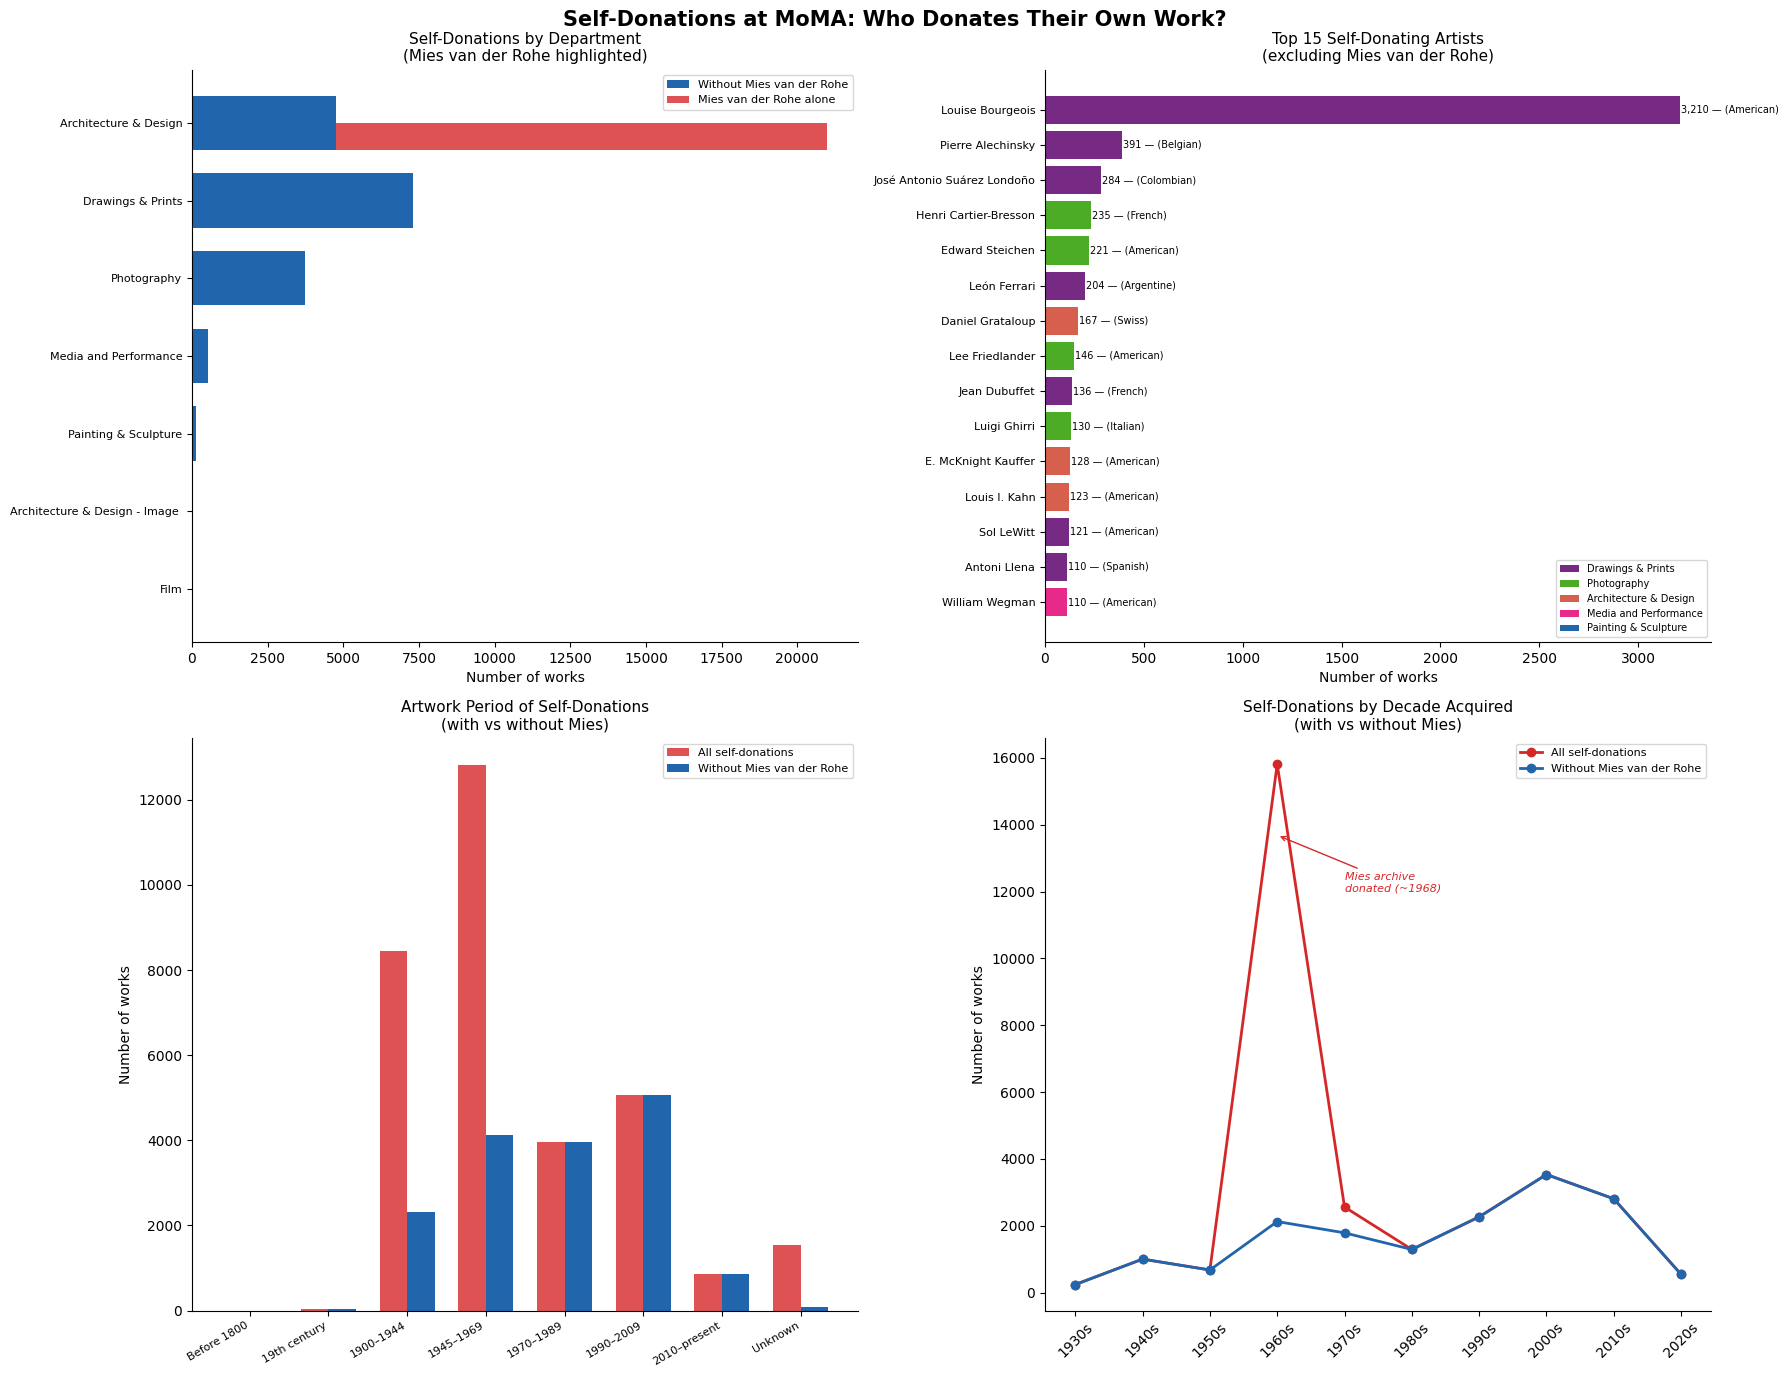

Saved.


In [112]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Self-Donations at MoMA: Who Donates Their Own Work?',
             fontsize=15, fontweight='bold')

# ── Chart 1: By department (with and without Mies) ──
ax1 = axes[0, 0]

dept_all = self_df['Department'].value_counts()
dept_no_mies = self_no_mies['Department'].value_counts()

depts = dept_all.index.tolist()
vals_all = dept_all.reindex(depts, fill_value=0).values
vals_no_mies = dept_no_mies.reindex(depts, fill_value=0).values
mies_contribution = vals_all - vals_no_mies

x = range(len(depts))
width = 0.35

ax1.barh([i + width/2 for i in x], vals_no_mies,
         height=width, color='#2166ac', label='Without Mies van der Rohe')
ax1.barh([i + width/2 for i in x], mies_contribution,
         height=width, left=vals_no_mies,
         color='#d62728', label='Mies van der Rohe alone', alpha=0.8)
ax1.barh([i - width/2 for i in x], vals_no_mies,
         height=width, color='#2166ac')

ax1.set_yticks(x)
ax1.set_yticklabels([d[:30] for d in depts], fontsize=8)
ax1.invert_yaxis()
ax1.set_title('Self-Donations by Department\n(Mies van der Rohe highlighted)', fontsize=11)
ax1.set_xlabel('Number of works')
ax1.legend(fontsize=8)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ── Chart 2: Top 15 self-donating artists (without Mies) ──
ax2 = axes[0, 1]

top15 = self_no_mies.groupby('Artist').size().sort_values(ascending=False).head(15)
artist_depts = {a: self_no_mies[self_no_mies['Artist']==a]['Department'].iloc[0] 
                for a in top15.index}

dept_color_map = {
    'Drawings & Prints':    '#762a83',
    'Photography':          '#4dac26',
    'Architecture & Design':'#d6604d',
    'Media and Performance':'#e7298a',
    'Painting & Sculpture': '#2166ac',
}
bar_colors = [dept_color_map.get(artist_depts[a], '#bababa') for a in top15.index]

bars = ax2.barh(range(len(top15)), top15.values, color=bar_colors)
ax2.set_yticks(range(len(top15)))
ax2.set_yticklabels([f"{a[:30]}" for a in top15.index], fontsize=8)
ax2.invert_yaxis()
ax2.set_title('Top 15 Self-Donating Artists\n(excluding Mies van der Rohe)', fontsize=11)
ax2.set_xlabel('Number of works')

for bar, val, artist in zip(bars, top15.values, top15.index):
    nat = self_no_mies[self_no_mies['Artist']==artist]['Nationality'].iloc[0]
    ax2.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             f'{val:,} — {nat}', va='center', fontsize=7)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in dept_color_map.items()]
ax2.legend(handles=legend_elements, fontsize=7, loc='lower right')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# ── Chart 3: Artwork period of self-donations ──
ax3 = axes[1, 0]

periods = ['Before 1800', '19th century', '1900–1944', '1945–1969',
           '1970–1989', '1990–2009', '2010–present', 'Unknown']

period_all = self_df['ArtworkPeriod'].value_counts().reindex(periods, fill_value=0)
period_no_mies = self_no_mies['ArtworkPeriod'].value_counts().reindex(periods, fill_value=0)

x = range(len(periods))
ax3.bar([i - width/2 for i in x], period_all.values,
        width=width, color='#d62728', label='All self-donations', alpha=0.8)
ax3.bar([i + width/2 for i in x], period_no_mies.values,
        width=width, color='#2166ac', label='Without Mies van der Rohe')

ax3.set_xticks(x)
ax3.set_xticklabels(periods, rotation=30, ha='right', fontsize=8)
ax3.set_title('Artwork Period of Self-Donations\n(with vs without Mies)', fontsize=11)
ax3.set_ylabel('Number of works')
ax3.legend(fontsize=8)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# ── Chart 4: Self-donations by decade acquired ──
ax4 = axes[1, 1]

decade_all = self_df['Decade'].value_counts().sort_index()
decade_no_mies = self_no_mies['Decade'].value_counts().sort_index()
decade_all = decade_all[decade_all.index.notna()]
decade_no_mies = decade_no_mies[decade_no_mies.index.notna()]
decade_all.index = decade_all.index.astype(int).astype(str) + 's'
decade_no_mies.index = decade_no_mies.index.astype(int).astype(str) + 's'

ax4.plot(decade_all.index, decade_all.values, color='#d62728',
         marker='o', linewidth=2, label='All self-donations')
ax4.plot(decade_no_mies.index, decade_no_mies.values, color='#2166ac',
         marker='o', linewidth=2, label='Without Mies van der Rohe')

ax4.set_title('Self-Donations by Decade Acquired\n(with vs without Mies)', fontsize=11)
ax4.set_ylabel('Number of works')
ax4.tick_params(axis='x', rotation=45)
ax4.legend(fontsize=8)

# Annotate 1960s spike
ax4.annotate('Mies archive\ndonated (~1968)',
             xy=('1960s', 13688), xytext=('1970s', 12000),
             fontsize=8, color='#d62728', style='italic',
             arrowprops=dict(arrowstyle='->', color='#d62728'))

ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('data/self_donations.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [113]:
print("=== SELF-DONATIONS 2000-2026 ===\n")

self_recent = self_df[self_df['YearAcquired'] >= 2000].copy()

print(f"Total self-donations 2000-2026: {len(self_recent):,}")
print(f"As % of all self-donations: {len(self_recent)/len(self_df)*100:.1f}%")

print(f"\n=== BY DEPARTMENT ===")
print(self_recent['Department'].value_counts())

print(f"\n=== BY YEAR ACQUIRED ===")
print(self_recent['YearAcquired'].value_counts().sort_index().to_string())

print(f"\n=== BY CREDITLINE TYPE ===")
for pattern in ['gift of the artist', 'gift of the architect',
                'gift of the architects', 'gift of the designer',
                'gift of the manufacturer']:
    count = self_recent['CreditLine'].str.contains(pattern, case=False, na=False).sum()
    print(f"  {pattern}: {count:,}")

print(f"\n=== BY NATIONALITY (top 20) ===")
print(self_recent['Nationality'].value_counts().head(20))

print(f"\n=== ARTWORK PERIOD ===")
print(self_recent['ArtworkPeriod'].value_counts())
print((self_recent['ArtworkPeriod'].value_counts(normalize=True)*100).round(1))

print(f"\n=== TOP 20 ARTISTS ===")
top_recent = self_recent.groupby('Artist').size().sort_values(ascending=False).head(20)
for artist, count in top_recent.items():
    nat = self_recent[self_recent['Artist']==artist]['Nationality'].iloc[0]
    dept = self_recent[self_recent['Artist']==artist]['Department'].iloc[0]
    print(f"  {artist} ({nat}, {dept}): {count:,} works")

=== SELF-DONATIONS 2000-2026 ===

Total self-donations 2000-2026: 6,887
As % of all self-donations: 21.1%

=== BY DEPARTMENT ===
Department
Drawings & Prints        3447
Architecture & Design    2120
Photography              1037
Media and Performance     251
Painting & Sculpture       30
Film                        2
Name: count, dtype: int64

=== BY YEAR ACQUIRED ===
YearAcquired
2000.0     257
2001.0     185
2002.0      63
2003.0      43
2004.0     104
2005.0     368
2006.0     143
2007.0     451
2008.0    1324
2009.0     596
2010.0     158
2011.0     181
2012.0     927
2013.0     402
2014.0     243
2015.0     228
2016.0      81
2017.0     259
2018.0      98
2019.0     230
2020.0     108
2021.0      32
2022.0      29
2023.0      55
2024.0      83
2025.0     158
2026.0      81

=== BY CREDITLINE TYPE ===
  gift of the artist: 4,818
  gift of the architect: 927
  gift of the architects: 265
  gift of the designer: 772
  gift of the manufacturer: 370

=== BY NATIONALITY (top 20) ===
Na

In [114]:
print("=== SELF-DONATIONS: ARTWORK PERIOD FROM 1999 ONWARDS ===\n")

self_recent_art = self_df[self_df['ArtworkYear'] >= 1999].copy()

print(f"Total self-donations with artwork year 1999+: {len(self_recent_art):,}")
print(f"As % of all self-donations: {len(self_recent_art)/len(self_df)*100:.1f}%")

print(f"\n=== BY DEPARTMENT ===")
print(self_recent_art['Department'].value_counts())

print(f"\n=== BY YEAR OF ARTWORK CREATION ===")
print(self_recent_art['ArtworkYear'].value_counts().sort_index().to_string())

print(f"\n=== BY CREDITLINE TYPE ===")
for pattern in ['gift of the artist', 'gift of the architect',
                'gift of the architects', 'gift of the designer',
                'gift of the manufacturer']:
    count = self_recent_art['CreditLine'].str.contains(pattern, case=False, na=False).sum()
    if count > 0:
        print(f"  {pattern}: {count:,}")

print(f"\n=== BY NATIONALITY (top 20) ===")
print(self_recent_art['Nationality'].value_counts().head(20))

print(f"\n=== TOP 20 ARTISTS ===")
top = self_recent_art.groupby('Artist').size().sort_values(ascending=False).head(20)
for artist, count in top.items():
    nat = self_recent_art[self_recent_art['Artist']==artist]['Nationality'].iloc[0]
    dept = self_recent_art[self_recent_art['Artist']==artist]['Department'].iloc[0]
    yr = self_recent_art[self_recent_art['Artist']==artist]['YearAcquired'].min()
    print(f"  {artist} ({nat}, {dept}): {count:,} works — first acquired: {int(yr)}")

=== SELF-DONATIONS: ARTWORK PERIOD FROM 1999 ONWARDS ===

Total self-donations with artwork year 1999+: 3,675
As % of all self-donations: 11.2%

=== BY DEPARTMENT ===
Department
Drawings & Prints        2390
Architecture & Design     991
Photography               239
Media and Performance      43
Painting & Sculpture       12
Name: count, dtype: int64

=== BY YEAR OF ARTWORK CREATION ===
ArtworkYear
1999.0    374
2000.0    311
2001.0    283
2002.0    341
2003.0    214
2004.0    228
2005.0    269
2006.0    244
2007.0    212
2008.0    138
2009.0    209
2010.0     92
2011.0     69
2012.0     80
2013.0     66
2014.0     27
2015.0     67
2016.0    136
2017.0    106
2018.0     33
2019.0     39
2020.0      7
2021.0     33
2022.0     33
2023.0     34
2024.0     17
2025.0     12
3000.0      1

=== BY CREDITLINE TYPE ===
  gift of the artist: 2,716
  gift of the architect: 523
  gift of the architects: 234
  gift of the designer: 271
  gift of the manufacturer: 165

=== BY NATIONALITY (top 20) =

In [116]:
# Add ArtworkYear to df
df['ArtworkYear'] = pd.to_numeric(
    df['Date'].str.extract(r'(\d{4})')[0], errors='coerce')

print(f"ArtworkYear non-null: {df['ArtworkYear'].notna().sum():,}")
print(f"Range: {df['ArtworkYear'].min():.0f} to {df['ArtworkYear'].max():.0f}")

ArtworkYear non-null: 156,169
Range: 1768 to 3000


In [117]:
print("=== SELF-DONATIONS 1999+ vs OTHER ACQUISITION TYPES ===\n")

# All works with artwork year 1999+
recent_art = df[
    (df['ArtworkYear'] >= 1999) & 
    (df['ArtworkYear'] <= 2026)
].copy()

print(f"Total works with artwork year 1999+: {len(recent_art):,}")

# Breakdown by acquisition type
by_type = recent_art['AcquisitionFinal'].value_counts()
by_type_pct = (recent_art['AcquisitionFinal'].value_counts(normalize=True)*100).round(1)

print(f"\nBy acquisition type:")
for t, count in by_type.items():
    pct = by_type_pct[t]
    print(f"  {t}: {count:,} ({pct}%)")

# Self-donations within DONATION
self_recent_mask = (
    recent_art['CreditLine'].str.contains(
        'gift of the artist|gift of the architect|gift of the architects|'
        'gift of the designer|gift of the manufacturer',
        case=False, na=False
    )
)
self_in_recent = recent_art[self_recent_mask]
external_donation = recent_art[
    (recent_art['AcquisitionFinal'] == 'DONATION') & ~self_recent_mask
]

print(f"\nDONATION breakdown:")
print(f"  Self-donation (artist/architect/designer): {len(self_in_recent):,} ({len(self_in_recent)/len(recent_art)*100:.1f}%)")
print(f"  External donation (collectors/foundations): {len(external_donation):,} ({len(external_donation)/len(recent_art)*100:.1f}%)")

print(f"\n=== REVISED TAXONOMY FOR ARTWORK 1999+ ===")
purchase = recent_art[recent_art['AcquisitionFinal'] == 'PURCHASE']
hybrid = recent_art[recent_art['AcquisitionFinal'] == 'HYBRID']
other = recent_art[recent_art['AcquisitionFinal'] == 'OTHER']

total_recent = len(recent_art)
print(f"{'Category':<40} {'Count':>8} {'%':>8}")
print("-" * 58)
print(f"{'External Donation (collectors)':<40} {len(external_donation):>8,} {len(external_donation)/total_recent*100:>7.1f}%")
print(f"{'Purchase (funds + direct)':<40} {len(purchase):>8,} {len(purchase)/total_recent*100:>7.1f}%")
print(f"{'Self-Donation (artist/architect)':<40} {len(self_in_recent):>8,} {len(self_in_recent)/total_recent*100:>7.1f}%")
print(f"{'Other/Unknown':<40} {len(other):>8,} {len(other)/total_recent*100:>7.1f}%")
print(f"{'Hybrid':<40} {len(hybrid):>8,} {len(hybrid)/total_recent*100:>7.1f}%")
print(f"{'TOTAL':<40} {total_recent:>8,} {'100.0':>8}%")

print(f"\n=== SELF-DONATION 1999+: IMPACT OF BOURGEOIS ===")
bourgeois_recent = self_in_recent[
    self_in_recent['Artist'].str.contains('Louise Bourgeois', na=False)]
print(f"Louise Bourgeois: {len(bourgeois_recent):,} ({len(bourgeois_recent)/len(self_in_recent)*100:.1f}% of self-donations 1999+)")
print(f"Without Bourgeois: {len(self_in_recent)-len(bourgeois_recent):,} ({(len(self_in_recent)-len(bourgeois_recent))/len(self_in_recent)*100:.1f}%)")

=== SELF-DONATIONS 1999+ vs OTHER ACQUISITION TYPES ===

Total works with artwork year 1999+: 17,603

By acquisition type:
  DONATION: 9,182 (52.2%)
  PURCHASE: 8,115 (46.1%)
  OTHER: 270 (1.5%)
  HYBRID: 36 (0.2%)

DONATION breakdown:
  Self-donation (artist/architect/designer): 3,674 (20.9%)
  External donation (collectors/foundations): 5,515 (31.3%)

=== REVISED TAXONOMY FOR ARTWORK 1999+ ===
Category                                    Count        %
----------------------------------------------------------
External Donation (collectors)              5,515    31.3%
Purchase (funds + direct)                   8,115    46.1%
Self-Donation (artist/architect)            3,674    20.9%
Other/Unknown                                 270     1.5%
Hybrid                                         36     0.2%
TOTAL                                      17,603    100.0%

=== SELF-DONATION 1999+: IMPACT OF BOURGEOIS ===
Louise Bourgeois: 1,803 (49.1% of self-donations 1999+)
Without Bourgeois: 1,8

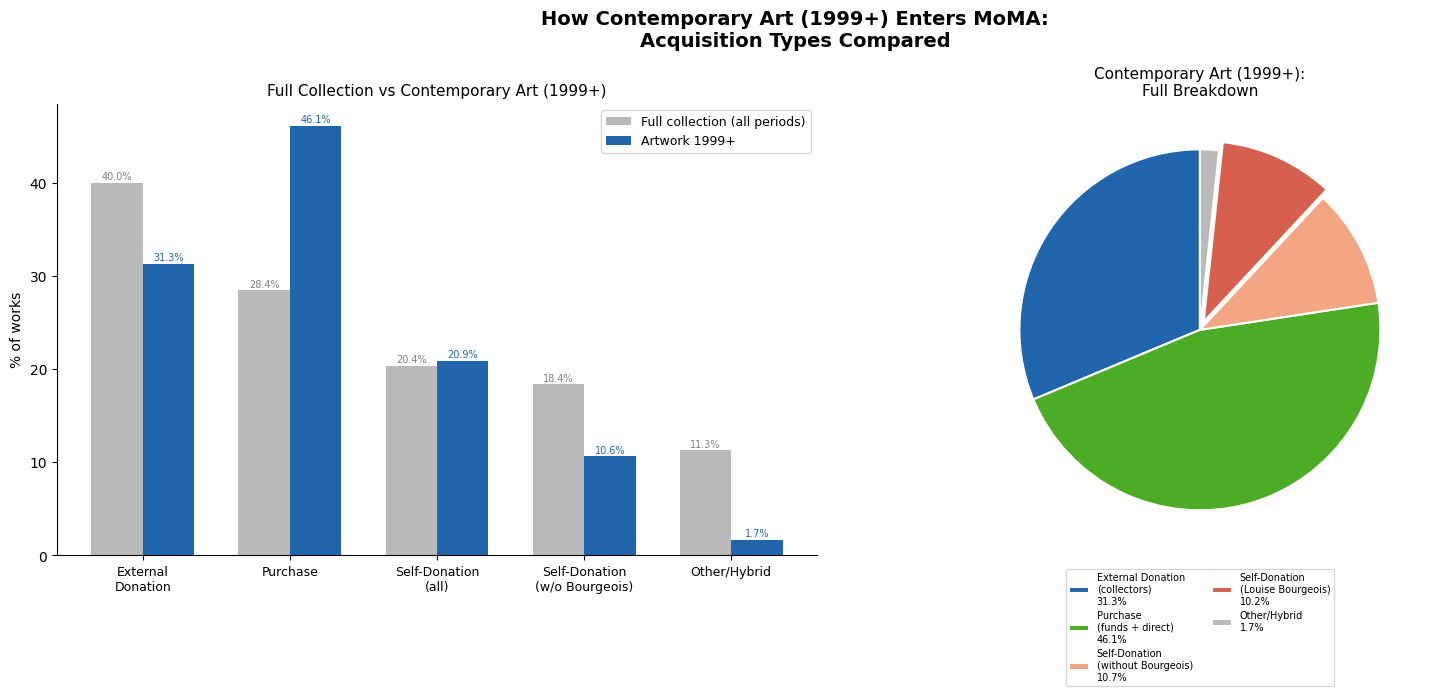

Saved.


In [118]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('How Contemporary Art (1999+) Enters MoMA:\nAcquisition Types Compared',
             fontsize=14, fontweight='bold')

# ── Chart 1: Full collection vs 1999+ ──
ax1 = axes[0]

categories = ['External\nDonation', 'Purchase', 'Self-Donation\n(all)', 
              'Self-Donation\n(w/o Bourgeois)', 'Other/Hybrid']

full_pcts = [
    len(df[df['AcquisitionFinal']=='DONATION'][~df[df['AcquisitionFinal']=='DONATION']['CreditLine'].str.contains(
        'gift of the artist|gift of the architect|gift of the architects|gift of the designer|gift of the manufacturer',
        case=False, na=True)]) / len(df) * 100,
    len(df[df['AcquisitionFinal']=='PURCHASE']) / len(df) * 100,
    32698 / len(df) * 100,
    (32698 - 3210) / len(df) * 100,  # without Bourgeois full collection
    (len(df[df['AcquisitionFinal']=='OTHER']) + len(df[df['AcquisitionFinal']=='HYBRID'])) / len(df) * 100
]

recent_pcts = [31.3, 46.1, 20.9, (1871/17603*100), 1.7]

x = range(len(categories))
width = 0.35

ax1.bar([i - width/2 for i in x], full_pcts,
        width=width, color='#bababa', label='Full collection (all periods)')
ax1.bar([i + width/2 for i in x], recent_pcts,
        width=width, color='#2166ac', label='Artwork 1999+')

ax1.set_xticks(x)
ax1.set_xticklabels(categories, fontsize=9)
ax1.set_title('Full Collection vs Contemporary Art (1999+)', fontsize=11)
ax1.set_ylabel('% of works')
ax1.legend(fontsize=9)

for i, (f, r) in enumerate(zip(full_pcts, recent_pcts)):
    ax1.text(i - width/2, f + 0.3, f'{f:.1f}%', ha='center', fontsize=7, color='gray')
    ax1.text(i + width/2, r + 0.3, f'{r:.1f}%', ha='center', fontsize=7, color='#2166ac')

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ── Chart 2: Contemporary art breakdown pie ──
ax2 = axes[1]

sizes = [31.3, 46.1, 20.9 - (1803/17603*100), 1803/17603*100, 1.7]
labels = [
    f'External Donation\n(collectors)\n31.3%',
    f'Purchase\n(funds + direct)\n46.1%',
    f'Self-Donation\n(without Bourgeois)\n{20.9-(1803/17603*100):.1f}%',
    f'Self-Donation\n(Louise Bourgeois)\n{1803/17603*100:.1f}%',
    f'Other/Hybrid\n1.7%'
]
colors = ['#2166ac', '#4dac26', '#f4a582', '#d6604d', '#bababa']
explode = (0, 0, 0, 0.05, 0)

wedges, texts = ax2.pie(sizes, colors=colors, explode=explode,
                         startangle=90, wedgeprops=dict(edgecolor='white', linewidth=1.5))

ax2.legend(wedges, labels, fontsize=7, loc='lower center',
           bbox_to_anchor=(0.5, -0.3), ncol=2)
ax2.set_title('Contemporary Art (1999+):\nFull Breakdown', fontsize=11)

plt.tight_layout()
plt.subplots_adjust(bottom=0.2)
plt.savefig('data/contemporary_acquisition_types.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [119]:
# Artists in the collection with artwork 1999+
recent_artists = set(df[
    (df['ArtworkYear'] >= 1999) & 
    (df['ArtworkYear'] <= 2026)
]['ConstituentID'].dropna().unique())

# Artists who debuted (first entry) in the collection
all_debuts = set(first['ConstituentID'].unique())

# First entry artists who have contemporary works
debuts_with_contemporary = recent_artists & all_debuts

print(f"=== CONTEMPORARY WORKS (1999+) IN PERMANENT COLLECTION ===\n")
print(f"Total unique artists with works 1999+: {len(recent_artists):,}")
print(f"Of those, how many debuted (first entry ever): {len(debuts_with_contemporary):,}")

# Of the debuts — when did they enter?
debut_recent = first[first['ConstituentID'].isin(debuts_with_contemporary)]
print(f"\nDebut year breakdown:")
print(debut_recent['YearAcquired'].value_counts().sort_index().tail(20))

print(f"\nDebut acquisition type:")
print(debut_recent['AcquisitionFinal'].value_counts())

print(f"\nDebut department:")
print(debut_recent['Department'].value_counts())

=== CONTEMPORARY WORKS (1999+) IN PERMANENT COLLECTION ===

Total unique artists with works 1999+: 2,909
Of those, how many debuted (first entry ever): 2,872

Debut year breakdown:
YearAcquired
2007.0    118
2008.0    102
2009.0     59
2010.0     55
2011.0     78
2012.0     74
2013.0    157
2014.0     76
2015.0    103
2016.0     68
2017.0     64
2018.0    100
2019.0     36
2020.0     66
2021.0     56
2022.0     45
2023.0     47
2024.0     45
2025.0     80
2026.0     34
Name: count, dtype: int64

Debut acquisition type:
AcquisitionFinal
DONATION    1452
PURCHASE    1420
Name: count, dtype: int64

Debut department:
Department
Drawings & Prints        1444
Architecture & Design     627
Photography               315
Media and Performance     309
Painting & Sculpture      163
Film                        9
Fluxus Collection           5
Name: count, dtype: int64


In [120]:
# Artists who debuted with contemporary works (1999+) via SELF-DONATION
debut_recent = first[first['ConstituentID'].isin(debuts_with_contemporary)].copy()

# Self-donation mask
self_mask = debut_recent['CreditLine'].str.contains(
    'gift of the artist|gift of the architect|gift of the architects|'
    'gift of the designer|gift of the manufacturer',
    case=False, na=False
)

self_debuts = debut_recent[self_mask]
external_donation = debut_recent[
    (debut_recent['AcquisitionFinal'] == 'DONATION') & ~self_mask
]
purchase_debuts = debut_recent[debut_recent['AcquisitionFinal'] == 'PURCHASE']

total = len(debut_recent)

print(f"=== HOW DID CONTEMPORARY ARTISTS DEBUT IN MOMA? ===\n")
print(f"Total debuts with contemporary works (1999+): {total:,}")
print(f"\n  Self-donation (artist/architect donated own work): {len(self_debuts):,} ({len(self_debuts)/total*100:.1f}%)")
print(f"  External donation (collector brought the work):   {len(external_donation):,} ({len(external_donation)/total*100:.1f}%)")
print(f"  Purchase (museum bought):                         {len(purchase_debuts):,} ({len(purchase_debuts)/total*100:.1f}%)")

print(f"\n=== SELF-DONATION DEBUTS: WHO ARE THEY? ===")
print(f"Total: {len(self_debuts)}")
print(f"\nBy department:")
print(self_debuts['Department'].value_counts())
print(f"\nBy nationality (top 15):")
print(self_debuts['NationalityClean'].value_counts().head(15))
print(f"\nBy CreditLine type:")
for pattern in ['gift of the artist', 'gift of the architect',
                'gift of the architects', 'gift of the designer',
                'gift of the manufacturer']:
    count = self_debuts['CreditLine'].str.contains(pattern, case=False, na=False).sum()
    if count > 0:
        print(f"  {pattern}: {count}")

=== HOW DID CONTEMPORARY ARTISTS DEBUT IN MOMA? ===

Total debuts with contemporary works (1999+): 2,872

  Self-donation (artist/architect donated own work): 303 (10.6%)
  External donation (collector brought the work):   1,149 (40.0%)
  Purchase (museum bought):                         1,420 (49.4%)

=== SELF-DONATION DEBUTS: WHO ARE THEY? ===
Total: 303

By department:
Department
Architecture & Design    244
Photography               22
Media and Performance     22
Drawings & Prints         12
Painting & Sculpture       3
Name: count, dtype: int64

By nationality (top 15):
NationalityClean
American                          44
Japanese                          18
American) (American               13
German                            11
                                  10
British                            9
Chinese) (Chinese                  9
Dutch                              8
Italian                            7
French                             7
Mexican                       

In [2]:
import os
print(os.getcwd())

/Users/arousell


In [4]:
artworks = pd.read_csv('/Users/arousell/collection/Artworks.csv')
artists = pd.read_csv('/Users/arousell/collection/Artists.csv')

In [7]:
debuts.to_csv('/Users/arousell/ps_debuts_2019_2026_full.csv', index=False)

In [9]:
print(f"Total debuts P&S 2019-2026: {len(debuts)}")
print(debuts.groupby('DebutYear').size())
print(debuts[['Artist','DebutYear','Nationality','CreditLine']].to_string())

Total debuts P&S 2019-2026: 0
Series([], dtype: int64)
Empty DataFrame
Columns: [Artist, DebutYear, Nationality, CreditLine]
Index: []


In [10]:
print(artworks['Department'].unique())

<StringArray>
[                'Architecture & Design',
                     'Drawings & Prints',
                  'Painting & Sculpture',
                           'Photography',
                 'Media and Performance',
                                  'Film',
 'Architecture & Design - Image Archive',
                     'Fluxus Collection']
Length: 8, dtype: str


In [11]:
ps = artworks[artworks['Department'] == 'Painting & Sculpture'].copy()
ps['DateAcquired'] = pd.to_datetime(ps['DateAcquired'], errors='coerce')
ps['YearAcquired'] = ps['DateAcquired'].dt.year

first_year = ps.groupby('Artist')['YearAcquired'].min().reset_index()
first_year.columns = ['Artist', 'DebutYear']

debuts = first_year[first_year['DebutYear'].between(2019, 2026)].copy()

acq_map = ps.groupby('Artist')['CreditLine'].first().reset_index()
debuts = debuts.merge(acq_map, on='Artist', how='left')

artist_info = artists[['DisplayName','Nationality','Gender','BeginDate']].copy()
artist_info.columns = ['Artist','Nationality','Gender','BirthYear']
debuts = debuts.merge(artist_info, on='Artist', how='left')

debuts = debuts.sort_values('DebutYear')

print(f"Total debuts P&S 2019-2026: {len(debuts)}")
print(debuts.groupby('DebutYear').size())
print(debuts[['Artist','DebutYear','Nationality','CreditLine']].to_string())

Total debuts P&S 2019-2026: 147
DebutYear
2019.0    19
2020.0    10
2021.0    27
2022.0    29
2023.0    18
2024.0    28
2025.0    14
2026.0     2
dtype: int64
                             Artist  DebutYear             Nationality                                                                                                                                                                                                                    CreditLine
45                     Ivan Kožarić     2019.0                Croatian                                                                                                                                                                 Gift of Neda Young, and James Keith Brown and Eric Diefenbach
106                 Romuald Hazoumè     2019.0                Beninese                                                                                                                                                                The Jean Pigozzi African 

In [16]:
#Painting & Sculpture Debuts
import pandas as pd

artworks = pd.read_csv('/Users/arousell/collection/Artworks.csv')
artists = pd.read_csv('/Users/arousell/collection/Artists.csv')

ps = artworks[artworks['Department'] == 'Painting & Sculpture'].copy()
ps['DateAcquired'] = pd.to_datetime(ps['DateAcquired'], errors='coerce')
ps['YearAcquired'] = ps['DateAcquired'].dt.year

first_year = ps.groupby('Artist')['YearAcquired'].min().reset_index()
first_year.columns = ['Artist', 'DebutYear']
debuts = first_year[first_year['DebutYear'].between(2019, 2026)].copy()

artists['BeginDate'] = pd.to_numeric(artists['BeginDate'], errors='coerce')
artists['EndDate'] = pd.to_numeric(artists['EndDate'], errors='coerce')

merged2 = debuts.merge(
    artists[['DisplayName', 'BeginDate', 'EndDate', 'Nationality', 'Gender', 'Wiki QID']], 
    left_on='Artist', right_on='DisplayName', how='left'
)

contemporary = merged2[
    (merged2['BeginDate'] >= 1940) & 
    ((merged2['EndDate'] == 0) | (merged2['EndDate'] >= 1990))
].copy()

print(f"Total debuts 2019-2026: {len(merged2)}")
print(f"Contemporary artists only (born 1940+): {len(contemporary)}")
print(f"\nExcluded as historical:")
excluded = merged2[~merged2.index.isin(contemporary.index)]
print(excluded[['Artist', 'BeginDate', 'EndDate']].to_string())

Total debuts 2019-2026: 147
Contemporary artists only (born 1940+): 90

Excluded as historical:
                             Artist  BeginDate  EndDate
0                 Abdias Nascimento       1914     2011
2                      Agnes Pelton       1881     1961
3                       Ahmed Morsi       1930        0
4    Alexander "Skunder" Boghossian       1937     2003
9                Anwar Jalal Shemza       1928     1985
10        Archibald John Motley Jr.       1891     1981
12                    Bertina Lopes       1924     2012
14                   Carlos Almaraz       1941     1989
15                    Carlos Mérida       1891     1984
17             Charlotte Posenenske       1930     1985
25              Emily Kam Kngwarray       1910     1996
26                    Evelyne Axell       1935     1972
27                      Fanny Sanin       1938        0
30                 François Dufrêne       1930     1982
33                     Gazbia Sirry       1925     2021
34      

In [17]:
print(f"Contemporary debuts P&S 2019-2026: {len(contemporary)}")
print(f"\nBy year:")
print(contemporary.groupby('DebutYear').size())

print(f"\nBy nationality (top 15):")
print(contemporary['Nationality'].value_counts().head(15))

print(f"\nBy gender:")
print(contemporary['Gender'].value_counts())

print(f"\nFull list:")
print(contemporary[['Artist', 'DebutYear', 'BeginDate', 'Nationality', 'Gender']].sort_values('DebutYear').to_string())


Contemporary debuts P&S 2019-2026: 90

By year:
DebutYear
2019.0    10
2020.0     9
2021.0    16
2022.0    22
2023.0    13
2024.0    12
2025.0     8
dtype: int64

By nationality (top 15):
Nationality
American         42
Brazilian         6
British           4
German            3
Argentine         2
Congolese         2
Chinese           2
South African     2
Korean            2
Canadian          2
Lebanese          2
Kenyan            2
Thai              2
Nigerian          2
Indian            2
Name: count, dtype: int64

By gender:
Gender
male      46
female    44
Name: count, dtype: int64

Full list:
                           Artist  DebutYear  BeginDate    Nationality  Gender
113               Sigfredo Chacón     2019.0       1950     Venezuelan    male
88                           Moké     2019.0       1950      Congolese    male
106               Romuald Hazoumè     2019.0       1962       Beninese    male
78                     Mary Corse     2019.0       1945       American  fem

In [19]:
import json
import pandas as pd

with open('/Users/arousell/data/scraped/exhibitions_raw.json', 'r') as f:
    exhibitions_raw = json.load(f)

exh_list = []
for exh in exhibitions_raw:
    if not exh.get('artists'):
        continue
    for artist in exh['artists']:
        exh_list.append({
            'exhibition_id': exh.get('id'),
            'exhibition_title': exh.get('title'),
            'exhibition_type': exh.get('type'),
            'year': str(exh.get('begin_date', ''))[:4] if exh.get('begin_date') else str(exh.get('year', '')),
            'artist': artist
        })

exh_df = pd.DataFrame(exh_list)
print(f"Total exhibition-artist records: {len(exh_df)}")
print(f"Date range: {exh_df['year'].min()} - {exh_df['year'].max()}")
print(exh_df.head())

Total exhibition-artist records: 8291
Date range:  - 
   exhibition_id          exhibition_title exhibition_type year  \
0           1700  Five Recent Acquisitions            None        
1           1700  Five Recent Acquisitions            None        
2           1700  Five Recent Acquisitions            None        
3           1700  Five Recent Acquisitions            None        
4           1700  Five Recent Acquisitions            None        

                                      artist  
0  {'id': '5053', 'name': 'Georges Rouault'}  
1    {'id': '3832', 'name': 'Henri Matisse'}  
2    {'id': '665', 'name': 'Pierre Bonnard'}  
3     {'id': '4164', 'name': 'Edvard Munch'}  
4  {'id': '3408', 'name': 'Marie Laurencin'}  


In [20]:
# Fix artist extraction
exh_list2 = []
for exh in exhibitions_raw:
    if not exh.get('artists'):
        continue
    # Get year from begin_date or year field
    year = ''
    if exh.get('begin_date'):
        year = str(exh['begin_date'])[:4]
    elif exh.get('year'):
        year = str(exh['year'])
    
    for artist in exh['artists']:
        # Artist can be dict or string
        if isinstance(artist, dict):
            artist_name = artist.get('name', '')
            artist_id = artist.get('id', '')
        else:
            artist_name = str(artist)
            artist_id = ''
        
        exh_list2.append({
            'exhibition_id': exh.get('id'),
            'exhibition_title': exh.get('title', ''),
            'exhibition_type': exh.get('type', ''),
            'year': year,
            'artist_name': artist_name,
            'artist_id': artist_id
        })

exh_df = pd.DataFrame(exh_list2)
exh_df['year'] = pd.to_numeric(exh_df['year'], errors='coerce')

print(f"Total records: {len(exh_df)}")
print(f"Date range: {exh_df['year'].min()} - {exh_df['year'].max()}")
print(f"Unique artists: {exh_df['artist_name'].nunique()}")
print(f"\nSample:")
print(exh_df[exh_df['year'] >= 2019].head(10))

Total records: 8291
Date range: nan - nan
Unique artists: 5574

Sample:
Empty DataFrame
Columns: [exhibition_id, exhibition_title, exhibition_type, year, artist_name, artist_id]
Index: []


In [21]:
# Check raw structure of first few exhibitions
for exh in exhibitions_raw[:3]:
    print(exh.keys())
    print(exh)
    print("---")

dict_keys(['id', 'title', 'date', 'description', 'artists', 'artist_count'])
{'id': 1700, 'title': 'Five Recent Acquisitions', 'date': 'Apr\xa018–Jun\xa022, 1975', 'description': 'We use our own and third-party cookies to personalize your experience and the promotions you see.', 'artists': [{'id': '5053', 'name': 'Georges Rouault'}, {'id': '3832', 'name': 'Henri Matisse'}, {'id': '665', 'name': 'Pierre Bonnard'}, {'id': '4164', 'name': 'Edvard Munch'}, {'id': '3408', 'name': 'Marie Laurencin'}], 'artist_count': 5}
---
dict_keys(['id', 'title', 'date', 'description', 'artists', 'artist_count'])
{'id': 1701, 'title': 'The Masterworks of Edvard Munch', 'date': 'Mar\xa015–Apr\xa024, 1979', 'description': 'In 2018–19, MoMA collaborated with Google Arts & Culture Lab on a project using machine learning to identify artworks in installation photos. That project has concluded, and works are now being identified by MoMA staff.', 'artists': [{'id': '4164', 'name': 'Edvard Munch'}], 'artist_count'

In [22]:
import re

exh_list3 = []
for exh in exhibitions_raw:
    if not exh.get('artists'):
        continue
    
    # Extract year from date string like "Apr 18–Jun 22, 1975"
    date_str = exh.get('date', '')
    year_match = re.search(r'\b(19|20)\d{2}\b', date_str)
    year = int(year_match.group()) if year_match else None
    
    for artist in exh['artists']:
        artist_name = artist.get('name', '') if isinstance(artist, dict) else str(artist)
        artist_id = artist.get('id', '') if isinstance(artist, dict) else ''
        
        exh_list3.append({
            'exhibition_id': exh.get('id'),
            'exhibition_title': exh.get('title', ''),
            'year': year,
            'artist_name': artist_name,
            'artist_id': artist_id
        })

exh_df = pd.DataFrame(exh_list3)
print(f"Total records: {len(exh_df)}")
print(f"Date range: {exh_df['year'].min()} - {exh_df['year'].max()}")
print(f"\nPost-2019 exhibitions:")
print(exh_df[exh_df['year'] >= 2019]['artist_name'].value_counts().head(20))

Total records: 8291
Date range: 1929.0 - 2026.0

Post-2019 exhibitions:
artist_name
Various Artists      4
Henri Matisse        4
Joan Miró            3
Andy Warhol          3
Joan Jonas           3
Pablo Picasso        3
Louise Bourgeois     2
Betye Saar           2
David Hammons        2
Senga Nengudi        2
Sable Elyse Smith    2
Ulrike Müller        2
Formafantasma        2
Claude Cahun         2
Frida Kahlo          2
Meret Oppenheim      2
Carolina Caycedo     2
Jim Dine             2
Aaron Horkey         2
Fototeca Gildari     2
Name: count, dtype: int64


In [23]:
# Cross-reference exhibitions with our 90 contemporary debut artists
contemporary_names = set(contemporary['Artist'].tolist())

# Find which of our 90 appeared in exhibitions BEFORE their MoMA debut
results = []
for _, artist_row in contemporary.iterrows():
    name = artist_row['Artist']
    debut_year = artist_row['DebutYear']
    
    # Find exhibitions for this artist
    artist_exh = exh_df[exh_df['artist_name'] == name]
    
    before = artist_exh[artist_exh['year'] < debut_year]
    after = artist_exh[artist_exh['year'] >= debut_year]
    
    results.append({
        'artist': name,
        'debut_year': debut_year,
        'exhibitions_before': len(before),
        'exhibitions_after': len(after),
        'first_exhibition': before['year'].min() if len(before) > 0 else None,
        'exhibition_titles_before': ', '.join(before['exhibition_title'].tolist()[:3])
    })

results_df = pd.DataFrame(results)

# Summary
had_exh_before = results_df[results_df['exhibitions_before'] > 0]
print(f"Total contemporary debuts: {len(results_df)}")
print(f"Had MoMA exhibition BEFORE acquisition: {len(had_exh_before)} ({len(had_exh_before)/len(results_df)*100:.1f}%)")
print(f"No prior MoMA exhibition: {len(results_df) - len(had_exh_before)}")
print(f"\nArtists with prior MoMA exhibitions:")
print(had_exh_before[['artist', 'debut_year', 'first_exhibition', 'exhibitions_before', 'exhibition_titles_before']].to_string())

Total contemporary debuts: 90
Had MoMA exhibition BEFORE acquisition: 16 (17.8%)
No prior MoMA exhibition: 74

Artists with prior MoMA exhibitions:
                  artist  debut_year  first_exhibition  exhibitions_before                                                                                            exhibition_titles_before
4             Anne Imhof      2023.0            2015.0                   1                                                                                                    Anne Imhof: DEAL
6    Bodys Isek Kingelez      2019.0            2018.0                   1                                                                                  Bodys Isek Kingelez\n\nCity Dreams
10               Cui Jie      2021.0            2017.0                   1                                                                                                           Past Skin
21          Helen Marten      2022.0            2012.0                   1              

In [24]:
# Merge with credit line data for the 74 without prior exhibitions
no_prior_exh = results_df[results_df['exhibitions_before'] == 0]['artist'].tolist()

# Get their acquisition info
acq_info = ps.copy()
acq_info['DateAcquired'] = pd.to_datetime(acq_info['DateAcquired'], errors='coerce')
acq_info['YearAcquired'] = acq_info['DateAcquired'].dt.year

# First acquisition per artist
first_acq = acq_info.groupby('Artist').agg(
    YearAcquired=('YearAcquired', 'min'),
    CreditLine=('CreditLine', 'first')
).reset_index()

no_prior_df = first_acq[first_acq['Artist'].isin(no_prior_exh)].copy()

# Classify acquisition type
def classify(cl):
    cl = str(cl).lower()
    if 'gift' in cl:
        return 'DONATION'
    elif 'purchase' in cl or 'fund' in cl:
        return 'PURCHASE/FUND'
    elif 'promised' in cl:
        return 'PROMISED GIFT'
    elif 'bequest' in cl:
        return 'BEQUEST'
    else:
        return 'OTHER'

no_prior_df['AcqType'] = no_prior_df['CreditLine'].apply(classify)

print(f"Artists with NO prior MoMA exhibition: {len(no_prior_df)}")
print(f"\nBy acquisition type:")
print(no_prior_df['AcqType'].value_counts())
print(f"\nBreakdown:")
for acq_type in no_prior_df['AcqType'].unique():
    subset = no_prior_df[no_prior_df['AcqType'] == acq_type]
    print(f"\n--- {acq_type} ({len(subset)}) ---")
    for _, row in subset.iterrows():
        print(f"  {row['Artist']}: {str(row['CreditLine'])[:80]}")

Artists with NO prior MoMA exhibition: 74

By acquisition type:
AcqType
DONATION         48
PURCHASE/FUND    21
OTHER             5
Name: count, dtype: int64

Breakdown:

--- PURCHASE/FUND (21) ---
  Abdoulaye Konaté: Committee on Painting and Sculpture Funds
  Analia Saban: Latin American and Caribbean Fund
  Anne Chu: Acquired through the generosity of Anne and Joel Ehrenkranz and Committee on Pai
  Christine Sun Kim: Fund for the Twenty-First Century
  David Diao: Committee on Painting and Sculpture Funds
  Diamond Stingily: Fund for the Twenty-First Century

  Fernanda Gomes: Latin American and Caribbean Fund
  Guadalupe Maravilla: Fund for the Twenty-First Century
  Jana Euler: Fund for the Twenty-First Century
  Lauren Halsey: The Jill and Peter Kraus Endowed Fund for Contemporary Acquisitions
  Marwan Rechmaoui: Fund for the Twenty-First Century
  Monika Baer: Fund for the Twenty-First Century
  Nike Davies-Okundaye: Painting and Sculpture Deaccession Funds
  Rochelle Feinstein:

In [12]:
# Who repeats as donor/fund
from collections import Counter

creditlines = debuts['CreditLine'].dropna().tolist()

# Search for recurring key names
keywords = [
    'Joyner', 'Tisch', 'Kravis', 'Tamer', 'Gund', 
    'Ehrenkranz', 'Dubin', 'Twenty-First Century', 
    'Latin American', 'Kraus', 'Cohen', 'Tananbaum',
    'Heyman', 'Pigozzi', 'Weir', 'Rockefeller',
    'Anonymous', 'Purchase', 'Deaccession', 'Haupt',
    'Paley', 'Lewisohn', 'Heinz', 'Ovitz', 'Ebers'
]

print("=== FREQUENCY BY KEY NAME (147 artists) ===")
for kw in keywords:
    count = sum(1 for cl in creditlines if kw in str(cl))
    artists = [debuts.iloc[i]['Artist'] for i, cl in enumerate(debuts['CreditLine'].tolist()) if kw in str(cl)]
    print(f"\n  {kw}: {count}x")
    for a in artists:
        print(f"    - {a}")

=== FREQUENCY BY KEY NAME (147 artists) ===

  Joyner: 6x
    - Jordan Casteel
    - Leonardo Drew
    - Suzanne Jackson
    - Abdias Nascimento
    - Janet Olivia Henry
    - Ficre Ghebreyesus

  Tisch: 8x
    - Suzanne Duchamp
    - Tarsila do Amaral
    - Suzanne Jackson
    - Rosemary Mayer
    - Agnes Pelton
    - Jay DeFeo
    - Ruth Asawa
    - Emily Kam Kngwarray

  Kravis: 7x
    - Dalton Paula
    - Noah Davis
    - Kamala Ibrahim Ishag
    - Suzanne Jackson
    - Gazbia Sirry
    - Alexander "Skunder" Boghossian
    - Ndidi Dike

  Tamer: 4x
    - Abdias Nascimento
    - Huguette Caland
    - Mohamed Melehi
    - Miyoko Ito

  Gund: 5x
    - Fred Wilson
    - Ouattara Watts
    - Titus Kaphar
    - Julian Lethbridge
    - Stephen Antonakos

  Ehrenkranz: 5x
    - Suzanne Jackson
    - Zhang Huan
    - Hung Liu
    - Anne Chu
    - Pacita Abad

  Dubin: 2x
    - Malangatana Valente Ngwenya
    - Ulla Wiggen

  Twenty-First Century: 12x
    - Guadalupe Maravilla
    - Marwan R

In [121]:
print("=== SELF-DONATION DEBUTS BY CATEGORY AND COUNTRY ===\n")

for pattern, label in [
    ('gift of the artist', 'ARTIST'),
    ('gift of the architect', 'ARCHITECT'),
    ('gift of the architects', 'ARCHITECTS (multiple)'),
    ('gift of the designer', 'DESIGNER'),
    ('gift of the manufacturer', 'MANUFACTURER'),
]:
    mask = self_debuts['CreditLine'].str.contains(pattern, case=False, na=False)
    subset = self_debuts[mask]
    
    if len(subset) == 0:
        continue
        
    print(f"\n{'='*60}")
    print(f"{label}: {len(subset)} artists")
    print(f"{'='*60}")
    
    # By nationality
    print(f"\nBy nationality:")
    nat_counts = subset['NationalityClean'].value_counts()
    for nat, count in nat_counts.items():
        if nat:
            print(f"  {nat}: {count}")
    
    # Artist list
    print(f"\nArtist list:")
    for _, row in subset.sort_values('NationalityClean').iterrows():
        print(f"  {row['Artist']} ({row['NationalityClean']}) — {int(row['YearAcquired'])} — {row['Department']}")

=== SELF-DONATION DEBUTS BY CATEGORY AND COUNTRY ===


ARTIST: 64 artists

By nationality:
  American: 22
  German: 5
  Italian: 3
  French: 2
  Brazilian: 2
  Mexican: 2
  American) (American: 2
  Colombian: 2
  Japanese: 2
  South African: 1
  Icelandic: 1
  Canadian: 1
  British) (British: 1
  Danish: 1
  American) (Vietnamese) (Vietnamese) (American) (Vietnamese: 1
  (Japanese) (German) (American) (Swedish) (American: 1
  British) (American: 1
  American) (British: 1
  French) (Italian: 1
  Scottish: 1
  Japanese) (German: 1
  Polish: 1
  German) (German) () () (Japanese: 1
  Portuguese: 1
  Australian: 1
  Italian): 1
  Danish) (Filipino: 1
  Zimbabwean: 1
  Iranian: 1

Artist list:
  Felix Harlan () — 2012 — Drawings & Prints
  UNITED BROTHERS, DAS INSTITUT () — 2013 — Media and Performance
  Grand Openings, Ei Arakawa, Jutta Koether, Jay Sanders, Emily Sundblad, Stefan Tcherepnin ((Japanese) (German) (American) (Swedish) (American) — 2011 — Media and Performance
  Richard Avedon

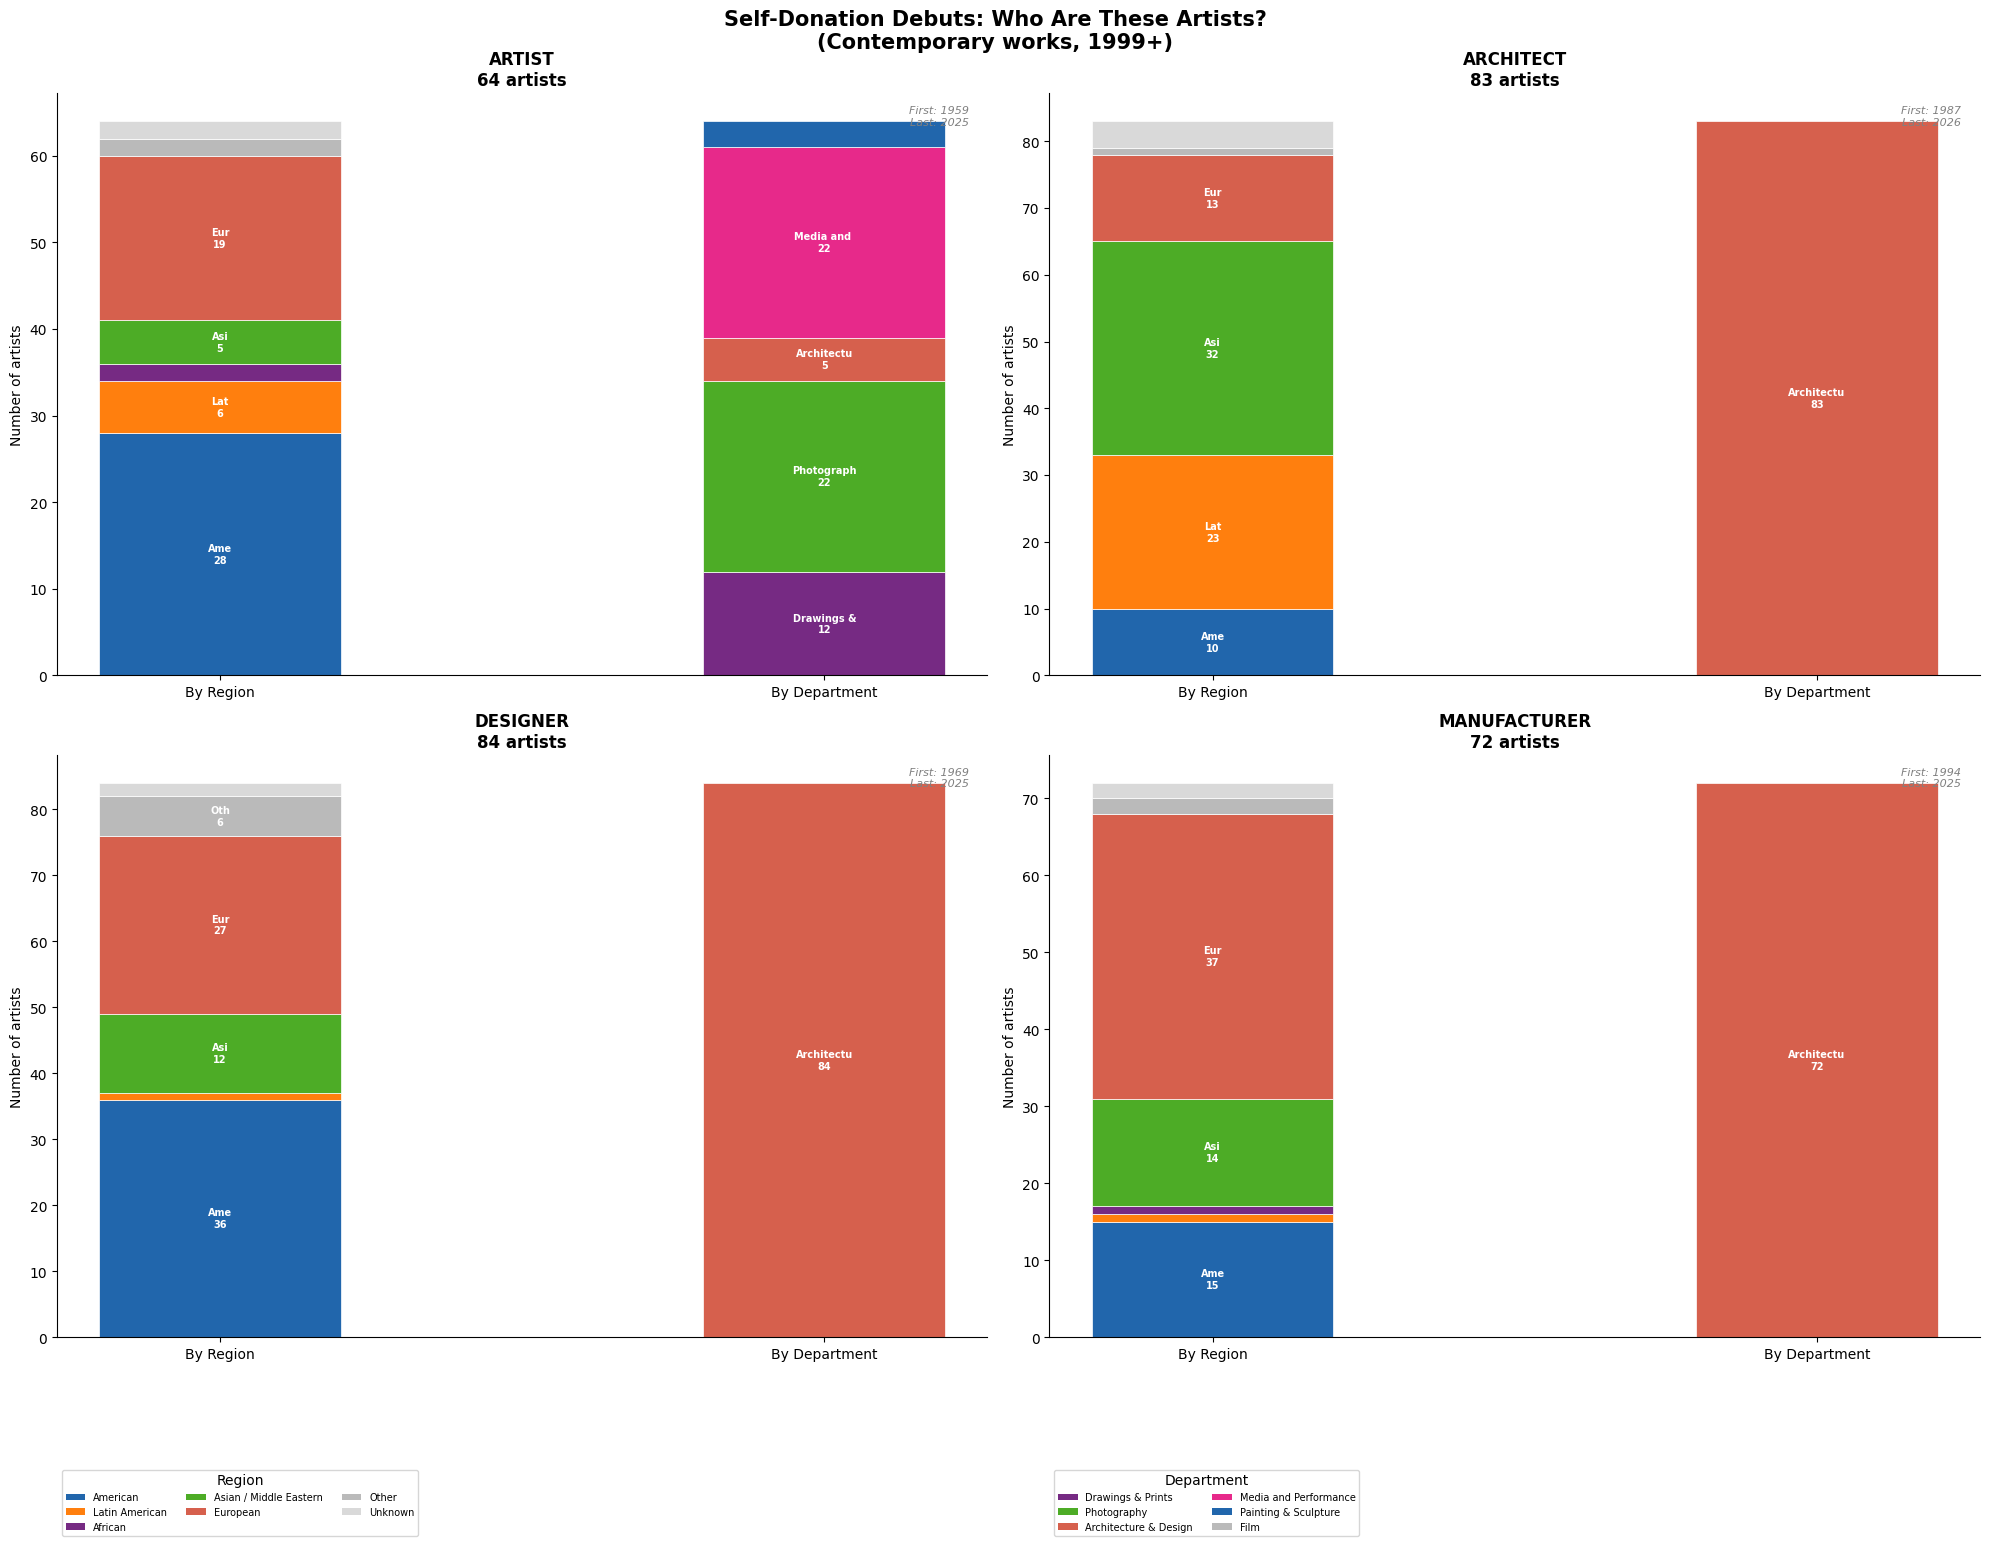

Saved.


In [122]:
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
fig.suptitle('Self-Donation Debuts: Who Are These Artists?\n(Contemporary works, 1999+)',
             fontsize=15, fontweight='bold')

categories = {
    'gift of the artist':       'ARTIST',
    'gift of the architect':    'ARCHITECT',
    'gift of the designer':     'DESIGNER',
    'gift of the manufacturer': 'MANUFACTURER',
}

category_data = {}
for pattern, label in categories.items():
    mask = self_debuts['CreditLine'].str.contains(pattern, case=False, na=False)
    category_data[label] = self_debuts[mask].copy()

# Clean nationality for region
def get_region(nat):
    if pd.isna(nat) or nat.strip() == '':
        return 'Unknown'
    nat = nat.lower()
    if 'american' in nat and not any(x in nat for x in ['latin','south','central',
                                                          'brazilian','mexican','colombian',
                                                          'argentine','salvadoran','cuban']):
        return 'American'
    elif any(x in nat for x in ['brazilian','mexican','colombian','argentine','peruvian',
                                  'chilean','venezuelan','cuban','salvadoran','uruguayan',
                                  'bolivian']):
        return 'Latin American'
    elif any(x in nat for x in ['nigerian','congolese','beninese','kenyan','malian',
                                  'ghanaian','egyptian','south african','zimbabwean',
                                  'senegalese']):
        return 'African'
    elif any(x in nat for x in ['japanese','korean','chinese','thai','indian','iraqi',
                                  'lebanese','israeli','syrian','vietnamese','iranian',
                                  'turkish','pakistani','bangladeshi']):
        return 'Asian / Middle Eastern'
    elif any(x in nat for x in ['french','german','british','belgian','croatian','swedish',
                                  'italian','dutch','swiss','austrian','polish','czech',
                                  'danish','norwegian','portuguese','spanish','scottish',
                                  'icelandic','russian','welsh','finnish']):
        return 'European'
    return 'Other'

region_colors = {
    'American':               '#2166ac',
    'Latin American':         '#ff7f0e',
    'African':                '#762a83',
    'Asian / Middle Eastern': '#4dac26',
    'European':               '#d6604d',
    'Other':                  '#bababa',
    'Unknown':                '#d9d9d9',
}

dept_colors = {
    'Drawings & Prints':    '#762a83',
    'Photography':          '#4dac26',
    'Architecture & Design':'#d6604d',
    'Media and Performance':'#e7298a',
    'Painting & Sculpture': '#2166ac',
    'Film':                 '#bababa',
}

for idx, (label, data) in enumerate(category_data.items()):
    ax = axes[idx // 2, idx % 2]
    
    data['Region'] = data['NationalityClean'].apply(get_region)
    
    total = len(data)
    
    # Stacked bar: region breakdown
    region_counts = data['Region'].value_counts()
    dept_counts = data['Department'].value_counts()
    
    # Two sub-bars: region and department
    x = ['Region', 'Department']
    
    # Region
    bottom = 0
    for region in region_colors:
        count = region_counts.get(region, 0)
        if count > 0:
            pct = count/total*100
            bar = ax.bar(0, count, bottom=bottom,
                        color=region_colors[region], 
                        edgecolor='white', linewidth=0.5,
                        width=0.4, label=region)
            if pct > 5:
                ax.text(0, bottom + count/2,
                       f'{region[:3]}\n{count}',
                       ha='center', va='center',
                       fontsize=7, color='white', fontweight='bold')
            bottom += count
    
    # Department
    bottom = 0
    for dept in dept_colors:
        count = dept_counts.get(dept, 0)
        if count > 0:
            pct = count/total*100
            ax.bar(1, count, bottom=bottom,
                  color=dept_colors[dept],
                  edgecolor='white', linewidth=0.5,
                  width=0.4)
            if pct > 5:
                ax.text(1, bottom + count/2,
                       f'{dept[:10]}\n{count}',
                       ha='center', va='center',
                       fontsize=7, color='white', fontweight='bold')
            bottom += count
    
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['By Region', 'By Department'], fontsize=10)
    ax.set_title(f'{label}\n{total} artists', fontsize=12, fontweight='bold')
    ax.set_ylabel('Number of artists')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Year range annotation
    yr_min = int(data['YearAcquired'].min())
    yr_max = int(data['YearAcquired'].max())
    ax.text(0.98, 0.98, f'First: {yr_min}\nLast: {yr_max}',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=8, color='gray', style='italic')

# Shared legends
from matplotlib.patches import Patch
region_legend = [Patch(facecolor=v, label=k) for k, v in region_colors.items()]
dept_legend = [Patch(facecolor=v, label=k) for k, v in dept_colors.items()]

axes[1,0].legend(handles=region_legend, title='Region',
                  fontsize=7, loc='lower left', bbox_to_anchor=(0, -0.35),
                  ncol=3)
axes[1,1].legend(handles=dept_legend, title='Department',
                  fontsize=7, loc='lower left', bbox_to_anchor=(0, -0.35),
                  ncol=2)

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.savefig('data/self_donation_categories.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [123]:
print("=== SELF-DONATION DEBUTS: ARTISTS BY CATEGORY AND DEPARTMENT ===\n")

for pattern, label in categories.items():
    data = category_data[label]
    print(f"\n{'='*60}")
    print(f"{label}: {len(data)} artists")
    print(f"{'='*60}")
    
    for dept in data['Department'].value_counts().index:
        dept_data = data[data['Department'] == dept]
        print(f"\n  {dept} ({len(dept_data)}):")
        for _, row in dept_data.sort_values('YearAcquired').iterrows():
            print(f"    {row['Artist']} ({row['NationalityClean']}) — {int(row['YearAcquired'])}")

=== SELF-DONATION DEBUTS: ARTISTS BY CATEGORY AND DEPARTMENT ===


ARTIST: 64 artists

  Photography (22):
    Richard Avedon (American) — 1959
    William Eggleston (American) — 1969
    David Goldblatt (South African) — 1978
    Sage Sohier (American) — 1981
    Mark Klett (American) — 1983
    Reagan Louie (American) — 1987
    Accra Shepp (American) — 1996
    Vik Muniz (Brazilian) — 1997
    Marco Breuer (German) — 1999
    Susan Unterberg (American) — 2000
    Cedric Buchet (Danish) — 2004
    Phillip Pisciotta (American) — 2005
    Shirana Shahbazi (German) — 2013
    Anna Ostoya (Polish) — 2013
    DIS (American) — 2016
    Lele Saveri, Various Artists (Italian)) — 2016
    Adelita Husni-Bey (Italian) — 2018
    Paolo Roversi (Italian) — 2019
    Ulrik Heltoft, Miljohn Ruperto (Danish) (Filipino) — 2019
    Artie Vierkant (American) — 2021
    Martine Gutierrez (American) — 2022
    Tania Franco Klein (Mexican) — 2023

  Media and Performance (22):
    Steina (Icelandic) — 1980

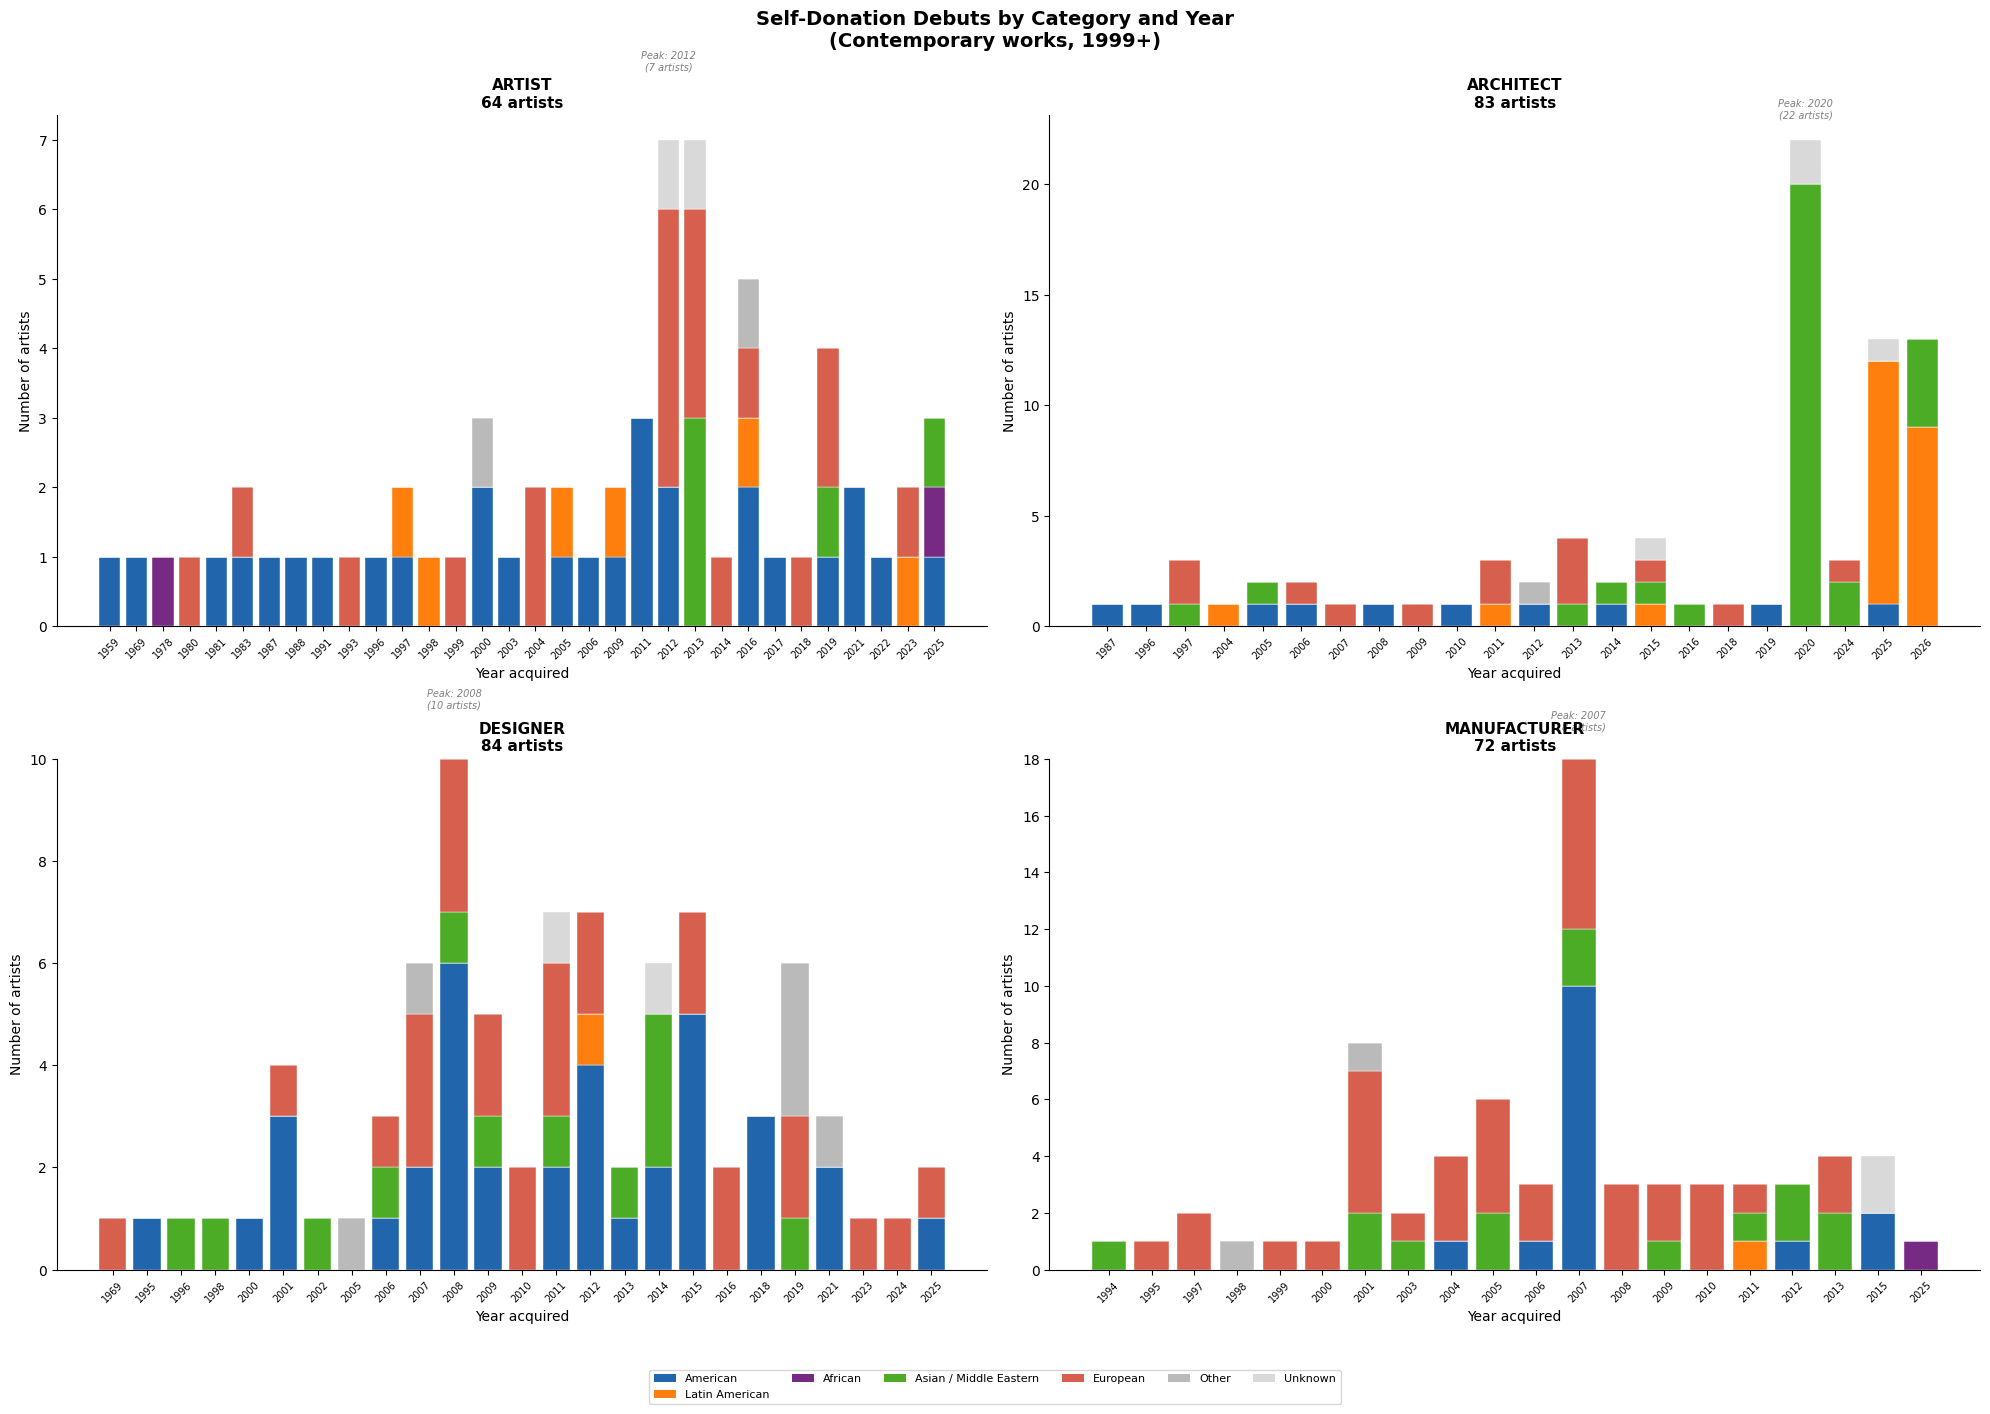

Saved.


In [124]:
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle('Self-Donation Debuts by Category and Year\n(Contemporary works, 1999+)',
             fontsize=14, fontweight='bold')

for idx, (label, data) in enumerate(category_data.items()):
    ax = axes[idx // 2, idx % 2]
    
    data['Region'] = data['NationalityClean'].apply(get_region)
    
    # Group by year and region
    year_region = data.groupby(['YearAcquired', 'Region']).size().unstack(fill_value=0)
    year_region.index = year_region.index.astype(int)
    
    # Ensure all regions present
    for region in region_colors:
        if region not in year_region.columns:
            year_region[region] = 0
    
    regions_order = [r for r in region_colors if r in year_region.columns]
    
    bottom = [0] * len(year_region)
    for region in regions_order:
        vals = year_region[region].values
        ax.bar(year_region.index.astype(str), vals,
               bottom=bottom, color=region_colors[region],
               label=region, edgecolor='white', linewidth=0.3)
        bottom = [b + v for b, v in zip(bottom, vals)]
    
    ax.set_title(f'{label}\n{len(data)} artists', fontsize=11, fontweight='bold')
    ax.set_xlabel('Year acquired')
    ax.set_ylabel('Number of artists')
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Annotate peaks
    total_by_year = year_region.sum(axis=1)
    peak_year = total_by_year.idxmax()
    peak_val = total_by_year.max()
    ax.annotate(f'Peak: {peak_year}\n({peak_val} artists)',
                xy=(str(peak_year), peak_val),
                xytext=(str(peak_year), peak_val + 1),
                fontsize=7, color='gray', style='italic',
                ha='center')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in region_colors.items()]
fig.legend(handles=legend_elements, fontsize=8,
           loc='lower center', ncol=6,
           bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.subplots_adjust(bottom=0.08)
plt.savefig('data/self_donation_by_year.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [128]:
# Check columns after merge
print(self_with_bio.columns.tolist())

['Title', 'Artist', 'ConstituentID', 'ArtistBio_x', 'Nationality', 'BeginDate_x', 'EndDate_x', 'Gender', 'Date', 'Medium', 'Dimensions', 'CreditLine', 'AccessionNumber', 'Classification', 'Department', 'DateAcquired', 'Cataloged', 'ObjectID', 'URL', 'ImageURL', 'OnView', 'Circumference (cm)', 'Depth (cm)', 'Diameter (cm)', 'Height (cm)', 'Length (cm)', 'Weight (kg)', 'Width (cm)', 'Seat Height (cm)', 'Duration (sec.)', 'AcquisitionType', 'Donor', 'CleanDonor', 'YearAcquired', 'Decade', 'AcquisitionFinal', 'NationalityClean', 'ArtistGender', 'GenderSimple', 'ArtworkYear', 'AgeAtAcquisition', 'ArtworkPeriod', 'EndDate_artist', 'ArtistStatus', 'IsFirstEntry', 'EntryType', 'EraSimple', 'DisplayName', 'ArtistBio_y', 'BeginDate_y', 'EndDate_y']


In [131]:
# Fix: replace 0 with NaN in BirthYear
self_with_bio['BirthYear'] = pd.to_numeric(
    self_with_bio['BeginDate_y'], errors='coerce')
self_with_bio['BirthYear'] = self_with_bio['BirthYear'].replace(0, pd.NA)

# Also filter unrealistic ages
self_with_bio['AgeAtDonation'] = self_with_bio['YearAcquired'] - self_with_bio['BirthYear']
self_with_bio['AgeAtDonation'] = self_with_bio['AgeAtDonation'].where(
    (self_with_bio['AgeAtDonation'] > 0) & 
    (self_with_bio['AgeAtDonation'] < 110)
)

print("=== BIRTH YEAR OF SELF-DONATING ARTISTS ===")
valid = self_with_bio['AgeAtDonation'].notna()
print(f"Artists with valid age: {valid.sum()} of {len(self_with_bio)}")
print(f"Average age at donation: {self_with_bio['AgeAtDonation'].mean():.0f}")
print(f"Median age at donation: {self_with_bio['AgeAtDonation'].median():.0f}")

print(f"\nAge distribution:")
print(pd.cut(self_with_bio['AgeAtDonation'].dropna(),
             bins=[0,30,40,50,60,70,80,100]).value_counts().sort_index())

print(f"\n=== BY CATEGORY AND AGE ===")
for pattern, label in categories.items():
    mask = self_with_bio['CreditLine'].str.contains(pattern, case=False, na=False)
    subset = self_with_bio[mask]
    avg_age = subset['AgeAtDonation'].mean()
    median_age = subset['AgeAtDonation'].median()
    n = subset['AgeAtDonation'].notna().sum()
    print(f"  {label}: avg {avg_age:.0f} | median {median_age:.0f} | n={n}")

print(f"\n=== ARTISTS ALREADY IN COLLECTION BEFORE SELF-DONATION ===")
all_works = df.copy()
all_works['ConstituentID'] = all_works['ConstituentID'].astype(str)

already_in = []
for _, row in self_with_bio.iterrows():
    cid = row['ConstituentID']
    donation_year = row['YearAcquired']
    prior_works = all_works[
        (all_works['ConstituentID'] == cid) &
        (all_works['YearAcquired'] < donation_year)
    ]
    if len(prior_works) > 0:
        already_in.append({
            'artist': row['Artist'],
            'prior_works': len(prior_works),
            'donation_year': int(donation_year),
            'category': next((label for pat, label in categories.items() 
                             if pat in str(row['CreditLine']).lower()), 'OTHER')
        })

print(f"Artists with prior works in collection: {len(already_in)} of {len(self_with_bio)}")
print(f"\nBreakdown:")
for a in sorted(already_in, key=lambda x: x['prior_works'], reverse=True)[:20]:
    print(f"  {a['artist']} ({a['category']}): "
          f"{a['prior_works']} prior works before {a['donation_year']}")

=== BIRTH YEAR OF SELF-DONATING ARTISTS ===
Artists with valid age: 153 of 303
Average age at donation: 41
Median age at donation: 39

Age distribution:
AgeAtDonation
(0, 30]      20
(30, 40]     69
(40, 50]     35
(50, 60]     17
(60, 70]      8
(70, 80]      4
(80, 100]     0
Name: count, dtype: int64

=== BY CATEGORY AND AGE ===
  ARTIST: avg 40 | median 36 | n=50
  ARCHITECT: avg 43 | median 47 | n=27
  DESIGNER: avg 39 | median 38 | n=42
  MANUFACTURER: avg 42 | median 39 | n=34

=== ARTISTS ALREADY IN COLLECTION BEFORE SELF-DONATION ===
Artists with prior works in collection: 0 of 303

Breakdown:


In [132]:
# Debug: check why no prior works found
# Test with a known artist — Louise Bourgeois
print("=== DEBUG: Louise Bourgeois ===")
lb = self_with_bio[self_with_bio['Artist'].str.contains('Louise Bourgeois', na=False)]
print(f"In self_with_bio: {len(lb)} entries")
if len(lb) > 0:
    cid = lb.iloc[0]['ConstituentID']
    year = lb.iloc[0]['YearAcquired']
    print(f"ConstituentID: {cid}, type: {type(cid)}")
    print(f"Donation year: {year}")
    
    # Check in all_works
    match = all_works[all_works['ConstituentID'] == cid]
    print(f"Works in all_works with same CID: {len(match)}")
    
    # Check types
    print(f"\nall_works ConstituentID type: {all_works['ConstituentID'].dtype}")
    print(f"self_with_bio ConstituentID type: {self_with_bio['ConstituentID'].dtype}")
    
    # Sample from all_works
    print(f"\nSample CIDs in all_works:")
    print(all_works['ConstituentID'].head(5).tolist())

=== DEBUG: Louise Bourgeois ===
In self_with_bio: 2 entries
ConstituentID: 7545, 710, type: <class 'str'>
Donation year: 2012.0
Works in all_works with same CID: 15

all_works ConstituentID type: str
self_with_bio ConstituentID type: str

Sample CIDs in all_works:
['6210', '7470', '7605', '7056', '7605']


In [133]:
print("=== ARTISTS ALREADY IN COLLECTION BEFORE SELF-DONATION ===")
all_works = df.copy()
all_works['ConstituentID'] = all_works['ConstituentID'].astype(str)

already_in = []
for _, row in self_with_bio.iterrows():
    # Split multiple IDs
    cids = [c.strip() for c in str(row['ConstituentID']).split(',')]
    donation_year = row['YearAcquired']
    
    for cid in cids:
        prior_works = all_works[
            (all_works['ConstituentID'].str.contains(cid, na=False)) &
            (all_works['YearAcquired'] < donation_year)
        ]
        if len(prior_works) > 0:
            already_in.append({
                'artist': row['Artist'],
                'cid': cid,
                'prior_works': len(prior_works),
                'donation_year': int(donation_year),
                'category': next((label for pat, label in categories.items()
                                 if pat in str(row['CreditLine']).lower()), 'OTHER')
            })
            break  # avoid duplicates per artist

print(f"Artists with prior works: {len(already_in)} of {len(self_with_bio)}")
print(f"\nTop 20 by prior works:")
for a in sorted(already_in, key=lambda x: x['prior_works'], reverse=True)[:20]:
    print(f"  {a['artist']} ({a['category']}): "
          f"{a['prior_works']} prior works before {a['donation_year']}")

print(f"\nArtists with NO prior works (true debut via self-donation):")
all_artists = set(self_with_bio['Artist'].tolist())
prior_artists = set(a['artist'] for a in already_in)
true_debuts = all_artists - prior_artists
print(f"  {len(true_debuts)} of {len(all_artists)} ({len(true_debuts)/len(all_artists)*100:.1f}%)")

=== ARTISTS ALREADY IN COLLECTION BEFORE SELF-DONATION ===
Artists with prior works: 54 of 303

Top 20 by prior works:
  Louise Bourgeois, Tracey Emin (ARTIST): 2790 prior works before 2012
  Lele Saveri, Various Artists (ARTIST): 648 prior works before 2016
  Massimo Vignelli, Beatriz Cifuentes, Yoshiki Waterhouse (DESIGNER): 86 prior works before 2015
  Christopher Wool, Richard Hell (ARTIST): 63 prior works before 2017
  Pentagram, John Tang, Peter Cazalet, Benjamin Chia, Robert Brunner, Bob Olodort (DESIGNER): 28 prior works before 2000
  Rem Koolhaas (ARCHITECT): 23 prior works before 1997
  Rafael Gamo, Mauricio Rocha (ARCHITECT): 22 prior works before 2026
  Mauricio Rocha, Rafael Gamo (ARCHITECT): 22 prior works before 2026
  Steven Holl, Solange Fabião (ARCHITECT): 19 prior works before 2004
  Thom Mayne (ARCHITECT): 16 prior works before 2010
  Tord Boontje (MANUFACTURER): 11 prior works before 2005
  Tracey Emin, Louise Bourgeois (ARTIST): 6 prior works before 2012
  Kerstin

In [134]:
print("=== SELF-DONATION TRUE DEBUTS: VIA FUND OR DIRECT? ===\n")

# True debuts — no prior works
true_debut_artists = all_artists - prior_artists
true_debuts_df = self_with_bio[self_with_bio['Artist'].isin(true_debut_artists)].copy()

print(f"Total true debuts via self-donation: {len(true_debuts_df)}")

# Check if CreditLine mentions a fund alongside the self-donation
def has_fund(credit):
    if pd.isna(credit):
        return False
    t = credit.lower()
    return 'fund' in t

true_debuts_df['HasFund'] = true_debuts_df['CreditLine'].apply(has_fund)

print(f"\nWith fund mentioned in CreditLine: {true_debuts_df['HasFund'].sum()} ({true_debuts_df['HasFund'].sum()/len(true_debuts_df)*100:.1f}%)")
print(f"Direct self-donation only: {(~true_debuts_df['HasFund']).sum()} ({(~true_debuts_df['HasFund']).sum()/len(true_debuts_df)*100:.1f}%)")

print(f"\n=== SELF-DONATIONS MENTIONING A FUND ===")
fund_debuts = true_debuts_df[true_debuts_df['HasFund']]
print(fund_debuts[['Artist','NationalityClean','YearAcquired','CreditLine']]\
      .sort_values('YearAcquired').to_string())

=== SELF-DONATION TRUE DEBUTS: VIA FUND OR DIRECT? ===

Total true debuts via self-donation: 249

With fund mentioned in CreditLine: 2 (0.8%)
Direct self-donation only: 247 (99.2%)

=== SELF-DONATIONS MENTIONING A FUND ===
                          Artist NationalityClean  YearAcquired                                                                 CreditLine
118  José Antonio Suárez Londoño        Colombian        2009.0           Gift of the artist through the Latin American and Caribbean Fund
214               Hudinilson Jr.        Brazilian        2016.0  Gift of the artist's estate through the Latin American and Caribbean Fund


In [135]:
print("=== TRUE DEBUT SELF-DONORS: FULL PROFILE ===\n")

print(f"Total: {len(true_debuts_df)}")

print(f"\n=== ARTIST BIO SAMPLE ===")
print(true_debuts_df[['Artist','ArtistBio_y','NationalityClean',
                        'YearAcquired','Department','CreditLine']]\
      .sort_values('YearAcquired')\
      .to_string())

=== TRUE DEBUT SELF-DONORS: FULL PROFILE ===

Total: 249

=== ARTIST BIO SAMPLE ===
                                                                                                                                                                         Artist                                ArtistBio_y                                                     NationalityClean  YearAcquired             Department                                                                                                                     CreditLine
1                                                                                                                                                                A. G. Fronzoni                         Italian, 1923–2002                                                              Italian        1969.0  Architecture & Design                                                                                                           Gift of the designer
2           

In [136]:
# Find self-donations that mention a gallery or exhibition
print("=== SELF-DONATIONS WITH GALLERY OR EXHIBITION MENTIONED ===\n")

gallery_mask = true_debuts_df['CreditLine'].str.contains(
    'gallery|galerie|galleria|exhibition|museo|museum',
    case=False, na=False
)
print(true_debuts_df[gallery_mask][['Artist','NationalityClean',
                                     'YearAcquired','Department','CreditLine']]\
      .to_string())

=== SELF-DONATIONS WITH GALLERY OR EXHIBITION MENTIONED ===

                Artist NationalityClean  YearAcquired   Department                                                                                                                     CreditLine
224  Adelita Husni-Bey          Italian        2018.0  Photography  Created on the occasion of the exhibition "Being: New Photography 2018". Gift of the artist and Laveronica arte contemporanea
263  Martine Gutierrez         American        2022.0  Photography                                                                          Gift of the artist and Ryan Lee Gallery, New York, NY


In [137]:
print("=== SELF-DONATION TRUE DEBUTS BY DEPARTMENT — FULL PROFILE ===\n")

for dept in true_debuts_df['Department'].value_counts().index:
    dept_data = true_debuts_df[true_debuts_df['Department'] == dept].copy()
    
    print(f"\n{'='*60}")
    print(f"{dept.upper()}: {len(dept_data)} artists")
    print(f"{'='*60}")
    
    # By category
    print(f"\nBy category:")
    for pattern, label in categories.items():
        mask = dept_data['CreditLine'].str.contains(pattern, case=False, na=False)
        count = mask.sum()
        if count > 0:
            print(f"  {label}: {count}")
    
    # By nationality
    print(f"\nBy nationality:")
    print(dept_data['NationalityClean'].value_counts().head(10).to_string())
    
    # By year
    print(f"\nBy year acquired:")
    print(dept_data['YearAcquired'].value_counts().sort_index().to_string())
    
    # Birth year / age
    valid_age = dept_data['AgeAtDonation'].dropna()
    if len(valid_age) > 0:
        print(f"\nAge at donation: avg {valid_age.mean():.0f} | median {valid_age.median():.0f} | n={len(valid_age)}")
    
    # Gallery mentions
    gallery_mask = dept_data['CreditLine'].str.contains(
        'gallery|galerie|galleria|exhibition|museo|museum',
        case=False, na=False)
    if gallery_mask.sum() > 0:
        print(f"\nWith gallery/exhibition mentioned: {gallery_mask.sum()}")
        print(dept_data[gallery_mask][['Artist','CreditLine']].to_string())
    
    # Full artist list
    print(f"\nFull artist list:")
    for _, row in dept_data.sort_values('YearAcquired').iterrows():
        print(f"  {int(row['YearAcquired'])} — {row['Artist']} ({row['NationalityClean']})")

=== SELF-DONATION TRUE DEBUTS BY DEPARTMENT — FULL PROFILE ===


ARCHITECTURE & DESIGN: 206 artists

By category:
  ARTIST: 5
  ARCHITECT: 66
  DESIGNER: 76
  MANUFACTURER: 59

By nationality:
NationalityClean
American                          21
Japanese                          16
American) (American               11
British                            9
Chinese) (Chinese                  9
                                   8
German                             5
Dutch                              5
American) (American) (American     5
Mexican                            5

By year acquired:
YearAcquired
1969.0     1
1994.0     1
1995.0     2
1996.0     2
1997.0     3
1998.0     2
2000.0     1
2001.0    10
2002.0     1
2003.0     2
2004.0     4
2005.0     6
2006.0     5
2007.0    21
2008.0    12
2009.0     6
2010.0     5
2011.0    14
2012.0    12
2013.0     7
2014.0     8
2015.0    14
2016.0     3
2018.0     3
2019.0     7
2020.0    22
2021.0     4
2023.0     1
2024.0     3
2025.0    1

In [106]:
def classify_credit_final(text):
    if pd.isna(text):
        return 'OTHER'
    
    t = text.lower()
    
    # HYBRID: explicit mix of purchase and gift
    if 'purchase' in t and 'gift' in t:
        return 'HYBRID'
    
    # DONATION: donor chooses what enters
    if any(x in t for x in ['gift', 'bequest', 
                              'promised', 'fractional',
                              'anonymous', 'given by']):
        return 'DONATION'
    
    # PURCHASE: museum chooses what enters
    # includes direct purchases AND all funds (named or committee)
    if any(x in t for x in ['purchase', 'fund', 
                              'acquired', 'exchange']):
        return 'PURCHASE'
    
    # OTHER: transfer, unknown, unreadable
    return 'OTHER'


df['AcquisitionFinal'] = df['CreditLine'].apply(classify_credit_final)

print("=== FINAL ACQUISITION TAXONOMY AFTER RECLASSIFICATION ===\n")
counts = df['AcquisitionFinal'].value_counts()
total = len(df)
for cat, count in counts.items():
    print(f"  {cat}: {count:,} ({count/total*100:.1f}%)")

print(f"\n  Classified: {counts.sum():,} / {total:,}")
print(f"  Unclassified (null CreditLine): {df['CreditLine'].isna().sum():,}")

=== FINAL ACQUISITION TAXONOMY AFTER RECLASSIFICATION ===

  DONATION: 96,796 (60.3%)
  PURCHASE: 45,658 (28.4%)
  OTHER: 17,161 (10.7%)
  HYBRID: 982 (0.6%)

  Classified: 160,597 / 160,597
  Unclassified (null CreditLine): 1,356


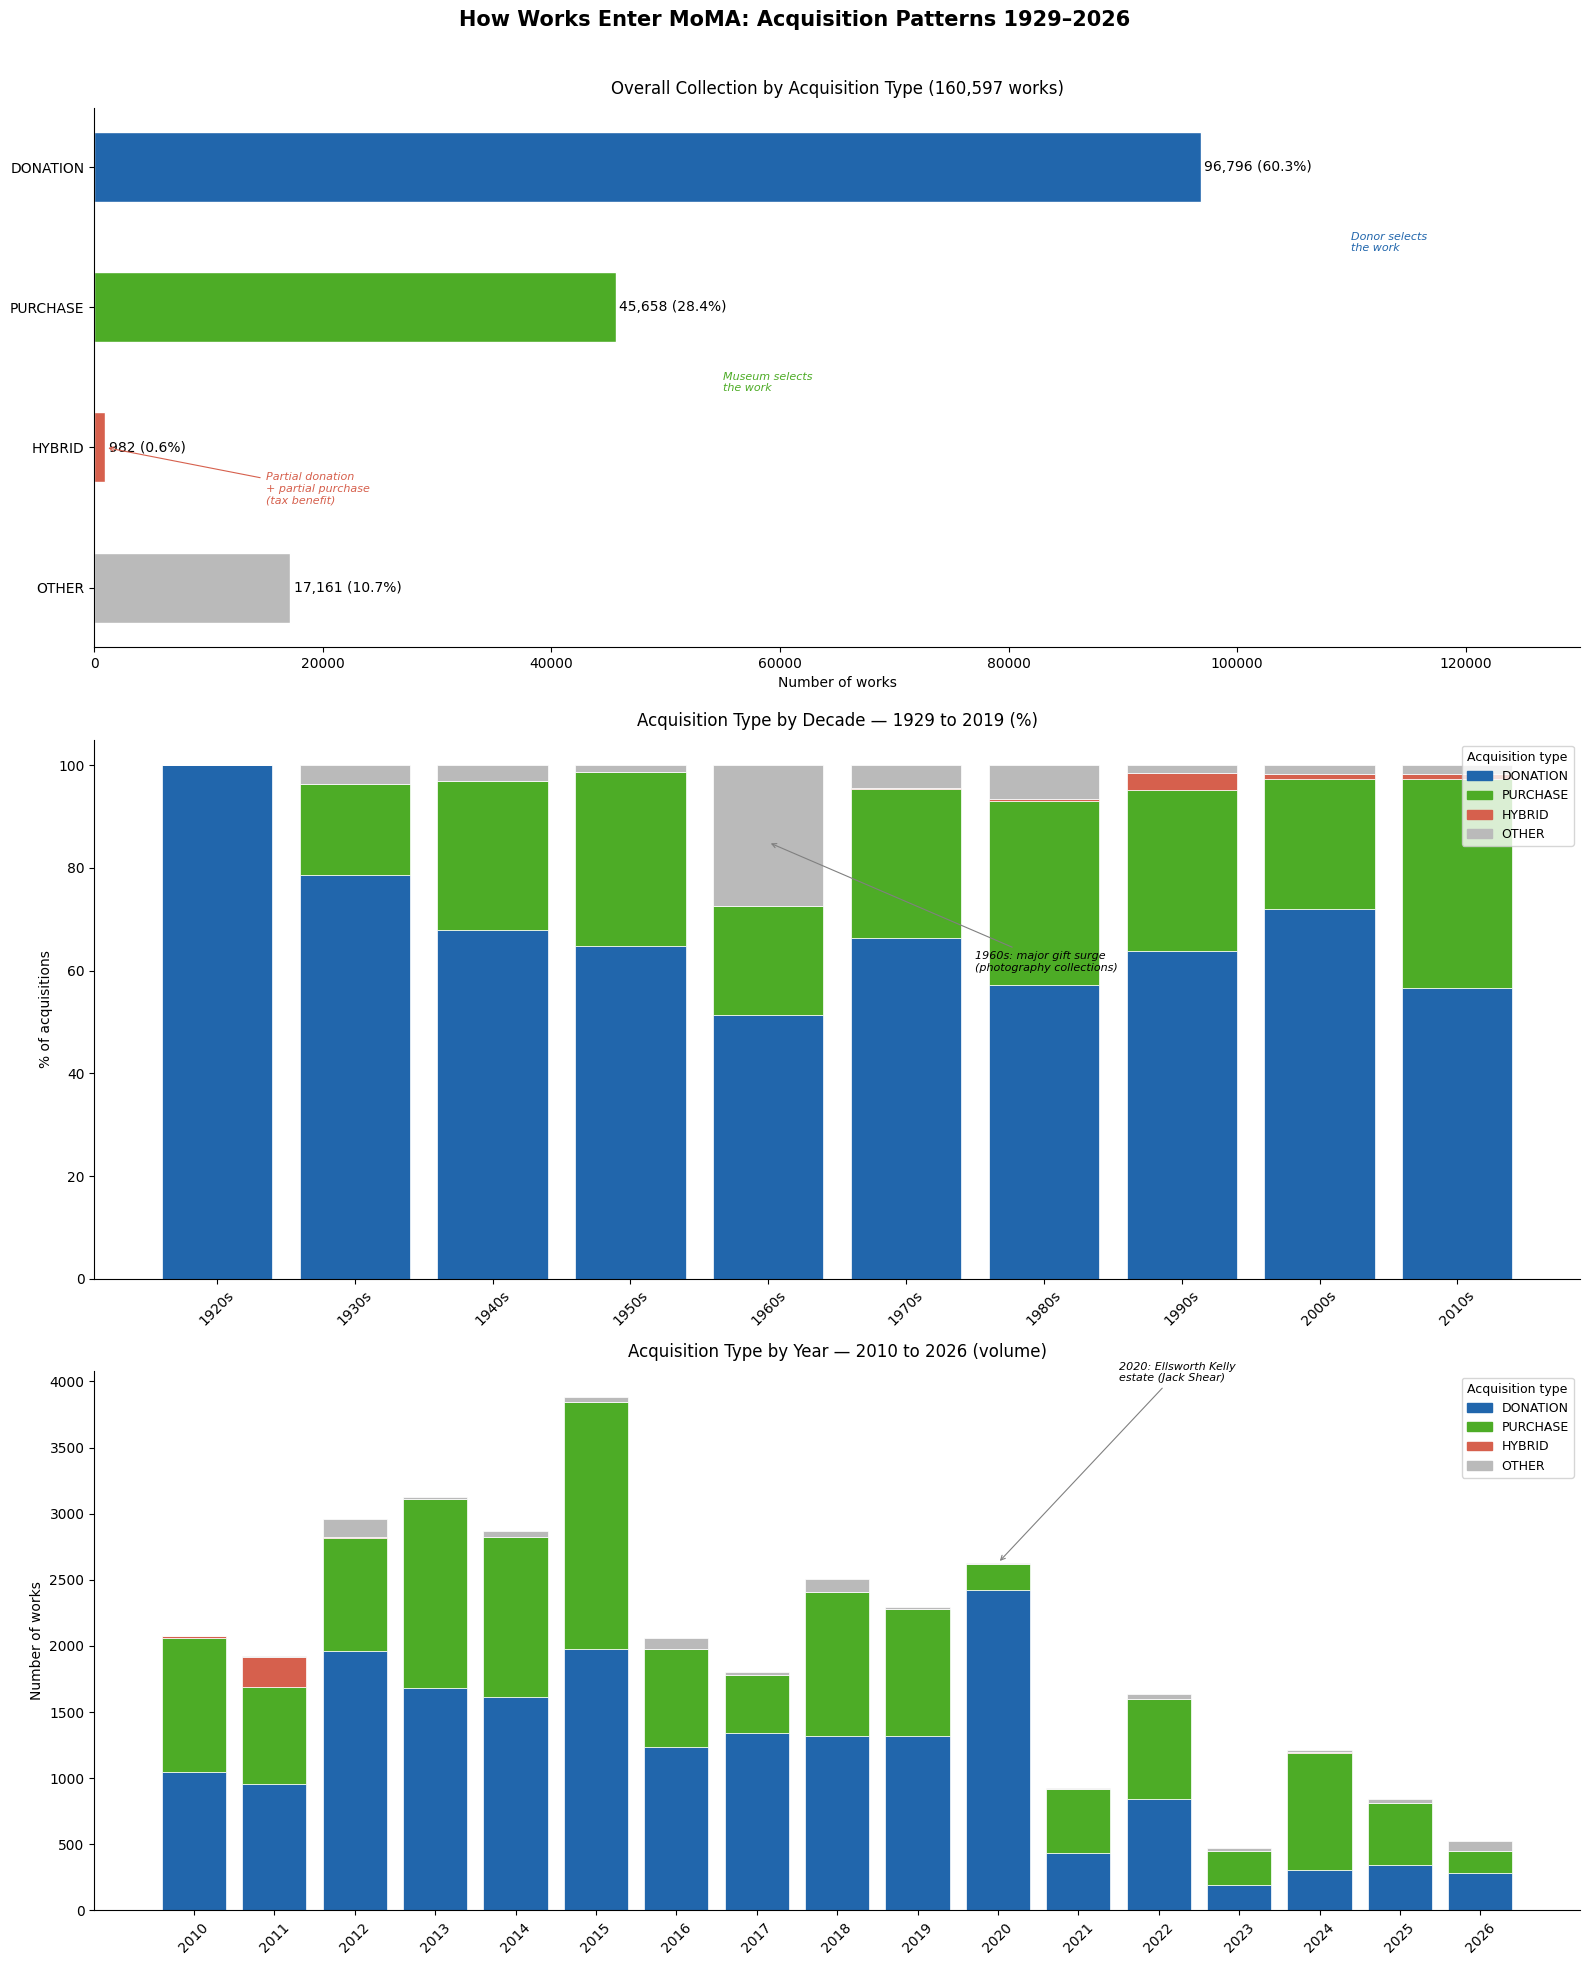

Saved.


In [32]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Prep data
df['YearAcquired'] = pd.to_datetime(df['DateAcquired'], errors='coerce').dt.year

# Color palette for the four categories
palette = {
    'DONATION': '#2166ac',
    'PURCHASE': '#4dac26',
    'HYBRID':   '#d6604d',
    'OTHER':    '#bababa'
}

fig, axes = plt.subplots(3, 1, figsize=(16, 20))
fig.suptitle('How Works Enter MoMA: Acquisition Patterns 1929–2026',
             fontsize=15, fontweight='bold', y=0.98)

# ── Chart 1: Overall breakdown (horizontal bar) ──
ax1 = axes[0]
cats = ['DONATION', 'PURCHASE', 'HYBRID', 'OTHER']
values = [df[df['AcquisitionFinal'] == c].shape[0] for c in cats]
pcts = [v / len(df) * 100 for v in values]
colors = [palette[c] for c in cats]

bars = ax1.barh(cats, values, color=colors, edgecolor='white', height=0.5)
ax1.set_title('Overall Collection by Acquisition Type (160,597 works)', 
              fontsize=12, pad=10)
ax1.set_xlabel('Number of works')
ax1.invert_yaxis()

for bar, val, pct in zip(bars, values, pcts):
    ax1.text(bar.get_width() + 300, bar.get_y() + bar.get_height()/2,
             f'{val:,} ({pct:.1f}%)', va='center', fontsize=10)

# Annotations
ax1.annotate('Donor selects\nthe work', xy=(96796, 0), xytext=(110000, 0.6),
             fontsize=8, color='#2166ac', style='italic')
ax1.annotate('Museum selects\nthe work', xy=(45658, 1), xytext=(55000, 1.6),
             fontsize=8, color='#4dac26', style='italic')
ax1.annotate('Partial donation\n+ partial purchase\n(tax benefit)', 
             xy=(982, 2), xytext=(15000, 2.4),
             fontsize=8, color='#d6604d', style='italic',
             arrowprops=dict(arrowstyle='->', color='#d6604d', lw=0.8))

ax1.set_xlim(0, 130000)
ax1.axvline(x=0, color='black', lw=0.5)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ── Chart 2: By decade (stacked bar, % view) — up to 2010 ──
ax2 = axes[1]

decade_data = df[df['YearAcquired'] <= 2019].copy()
decade_data['Decade'] = (decade_data['YearAcquired'] // 10 * 10).astype('Int64')
decade_type = decade_data.groupby(['Decade', 'AcquisitionFinal']).size().unstack(fill_value=0)
decade_pct = decade_type.div(decade_type.sum(axis=1), axis=0) * 100
decade_pct = decade_pct[decade_pct.index.notna()]
decade_pct.index = [f"{int(d)}s" for d in decade_pct.index]

# Reorder columns
for col in cats:
    if col not in decade_pct.columns:
        decade_pct[col] = 0
decade_pct = decade_pct[cats]

bottom = np.zeros(len(decade_pct))
for cat in cats:
    ax2.bar(decade_pct.index, decade_pct[cat], bottom=bottom,
            color=palette[cat], label=cat, edgecolor='white', linewidth=0.5)
    bottom += decade_pct[cat].values

ax2.set_title('Acquisition Type by Decade — 1929 to 2019 (%)', fontsize=12, pad=10)
ax2.set_ylabel('% of acquisitions')
ax2.set_ylim(0, 105)
ax2.tick_params(axis='x', rotation=45)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Legend
legend_patches = [mpatches.Patch(color=palette[c], label=c) for c in cats]
ax2.legend(handles=legend_patches, loc='upper right', fontsize=9,
           title='Acquisition type', title_fontsize=9)

# Annotation on 1960s spike
ax2.annotate('1960s: major gift surge\n(photography collections)', 
             xy=(4, 85), xytext=(5.5, 60),
             fontsize=8, style='italic',
             arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))

# ── Chart 3: By year 2010–2026 (stacked bar, volume) ──
ax3 = axes[2]

year_data = df[df['YearAcquired'] >= 2010].copy()
year_type = year_data.groupby(['YearAcquired', 'AcquisitionFinal']).size().unstack(fill_value=0)
year_type = year_type[year_type.index.notna()]
year_type.index = year_type.index.astype(int)

for col in cats:
    if col not in year_type.columns:
        year_type[col] = 0
year_type = year_type[cats]

bottom = np.zeros(len(year_type))
x = range(len(year_type))
for cat in cats:
    ax3.bar(x, year_type[cat], bottom=bottom,
            color=palette[cat], label=cat, edgecolor='white', linewidth=0.5)
    bottom += year_type[cat].values

ax3.set_xticks(range(len(year_type)))
ax3.set_xticklabels(year_type.index.astype(str), rotation=45)
ax3.set_title('Acquisition Type by Year — 2010 to 2026 (volume)', fontsize=12, pad=10)
ax3.set_ylabel('Number of works')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

legend_patches = [mpatches.Patch(color=palette[c], label=c) for c in cats]
ax3.legend(handles=legend_patches, loc='upper right', fontsize=9,
           title='Acquisition type', title_fontsize=9)

# Annotation
ax3.annotate('2020: Ellsworth Kelly\nestate (Jack Shear)', 
             xy=(10, 2627), xytext=(11.5, 4000),
             fontsize=8, style='italic',
             arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('data/acquisition_final.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

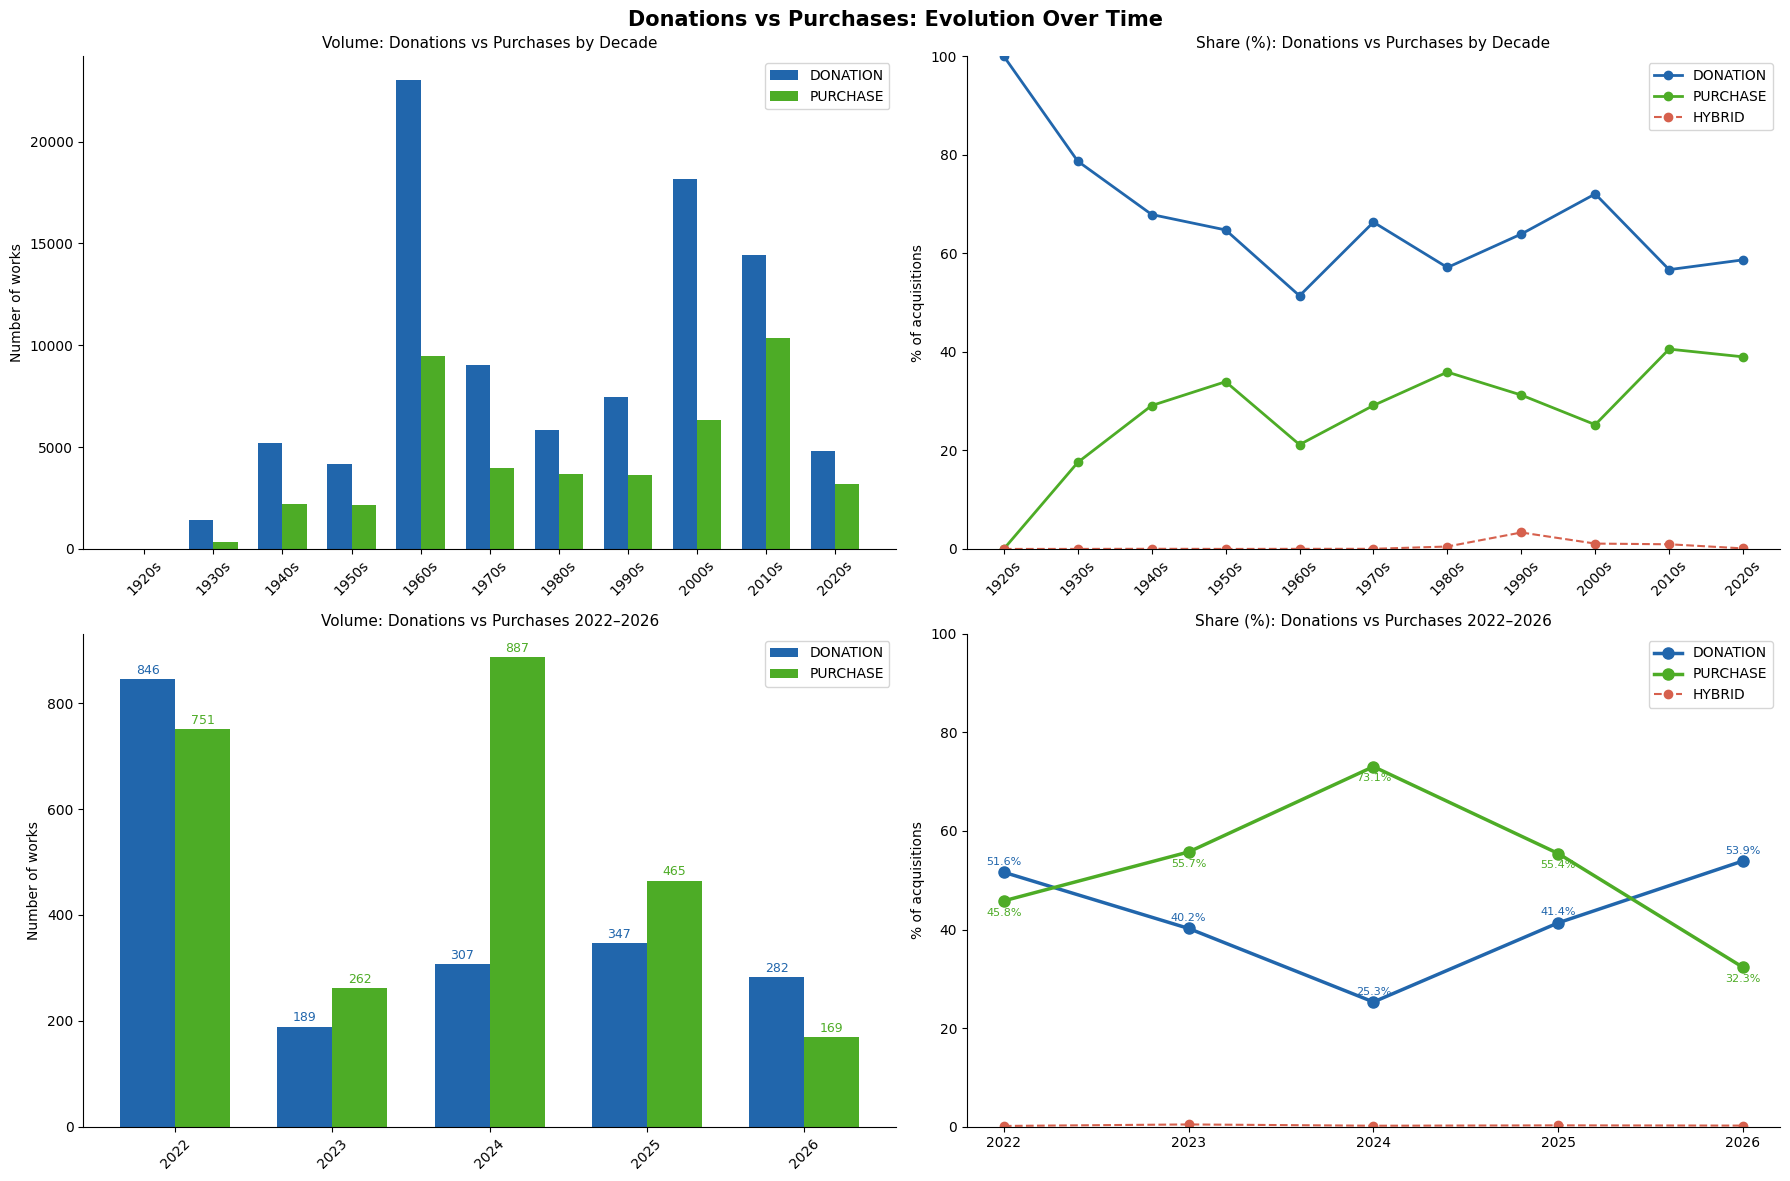

Saved.


In [33]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Donations vs Purchases: Evolution Over Time', 
             fontsize=15, fontweight='bold')

# Prep decade data (full history)
decade_data = df[df['YearAcquired'].notna()].copy()
decade_data['Decade'] = (decade_data['YearAcquired'] // 10 * 10).astype(int)

decade_counts = decade_data.groupby(['Decade', 'AcquisitionFinal']).size().unstack(fill_value=0)
for col in ['DONATION', 'PURCHASE', 'HYBRID', 'OTHER']:
    if col not in decade_counts.columns:
        decade_counts[col] = 0

decade_pct = decade_counts.div(decade_counts.sum(axis=1), axis=0) * 100
decade_counts.index = [f"{d}s" for d in decade_counts.index]
decade_pct.index = [f"{d}s" for d in decade_pct.index]

# Prep annual data (last 4 years: 2022-2026)
recent = df[df['YearAcquired'] >= 2022].copy()
recent_counts = recent.groupby(['YearAcquired', 'AcquisitionFinal']).size().unstack(fill_value=0)
recent_pct = recent_counts.div(recent_counts.sum(axis=1), axis=0) * 100
recent_counts.index = recent_counts.index.astype(int)
recent_pct.index = recent_pct.index.astype(int)

# ── Chart 1: Volume by decade ──
ax1 = axes[0, 0]
x = range(len(decade_counts))
width = 0.35
ax1.bar([i - width/2 for i in x], decade_counts['DONATION'], 
        width=width, color='#2166ac', label='DONATION')
ax1.bar([i + width/2 for i in x], decade_counts['PURCHASE'], 
        width=width, color='#4dac26', label='PURCHASE')
ax1.set_xticks(x)
ax1.set_xticklabels(decade_counts.index, rotation=45)
ax1.set_title('Volume: Donations vs Purchases by Decade', fontsize=11)
ax1.set_ylabel('Number of works')
ax1.legend()
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ── Chart 2: % by decade ──
ax2 = axes[0, 1]
ax2.plot(decade_pct.index, decade_pct['DONATION'], 
         color='#2166ac', marker='o', linewidth=2, label='DONATION')
ax2.plot(decade_pct.index, decade_pct['PURCHASE'], 
         color='#4dac26', marker='o', linewidth=2, label='PURCHASE')
ax2.plot(decade_pct.index, decade_pct['HYBRID'], 
         color='#d6604d', marker='o', linewidth=1.5, 
         linestyle='--', label='HYBRID')
ax2.set_title('Share (%): Donations vs Purchases by Decade', fontsize=11)
ax2.set_ylabel('% of acquisitions')
ax2.set_ylim(0, 100)
ax2.tick_params(axis='x', rotation=45)
ax2.legend()
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# ── Chart 3: Volume last 4 years ──
ax3 = axes[1, 0]
x = range(len(recent_counts))
width = 0.35
ax3.bar([i - width/2 for i in x], recent_counts['DONATION'], 
        width=width, color='#2166ac', label='DONATION')
ax3.bar([i + width/2 for i in x], recent_counts['PURCHASE'], 
        width=width, color='#4dac26', label='PURCHASE')
ax3.set_xticks(x)
ax3.set_xticklabels(recent_counts.index.astype(str), rotation=45)
ax3.set_title('Volume: Donations vs Purchases 2022–2026', fontsize=11)
ax3.set_ylabel('Number of works')
ax3.legend()
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# Add value labels
for i, (don, pur) in enumerate(zip(recent_counts['DONATION'], 
                                    recent_counts['PURCHASE'])):
    ax3.text(i - width/2, don + 10, f'{don:,}', 
             ha='center', fontsize=9, color='#2166ac')
    ax3.text(i + width/2, pur + 10, f'{pur:,}', 
             ha='center', fontsize=9, color='#4dac26')

# ── Chart 4: % last 4 years ──
ax4 = axes[1, 1]
ax4.plot(recent_pct.index.astype(str), recent_pct['DONATION'], 
         color='#2166ac', marker='o', linewidth=2.5, 
         markersize=8, label='DONATION')
ax4.plot(recent_pct.index.astype(str), recent_pct['PURCHASE'], 
         color='#4dac26', marker='o', linewidth=2.5, 
         markersize=8, label='PURCHASE')
ax4.plot(recent_pct.index.astype(str), recent_pct['HYBRID'], 
         color='#d6604d', marker='o', linewidth=1.5, 
         linestyle='--', markersize=6, label='HYBRID')

# Add value labels on points
for year, don, pur in zip(recent_pct.index.astype(str), 
                           recent_pct['DONATION'], 
                           recent_pct['PURCHASE']):
    ax4.text(year, don + 1.5, f'{don:.1f}%', 
             ha='center', fontsize=8, color='#2166ac')
    ax4.text(year, pur - 3, f'{pur:.1f}%', 
             ha='center', fontsize=8, color='#4dac26')

ax4.set_title('Share (%): Donations vs Purchases 2022–2026', fontsize=11)
ax4.set_ylabel('% of acquisitions')
ax4.set_ylim(0, 100)
ax4.legend()
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('data/donation_vs_purchase.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [36]:
artists_df = pd.read_csv('collection/Artists.csv')
print(artists_df.columns.tolist())
print(artists_df.head(3))

['ConstituentID', 'DisplayName', 'ArtistBio', 'Nationality', 'Gender', 'BeginDate', 'EndDate', 'Wiki QID', 'ULAN']
   ConstituentID     DisplayName            ArtistBio Nationality Gender  \
0              1  Robert Arneson  American, 1930–1992    American   male   
1              2  Doroteo Arnaiz   Spanish, born 1936     Spanish   male   
2              3     Bill Arnold  American, born 1941    American   male   

   BeginDate  EndDate Wiki QID  ULAN  
0       1930     1992      NaN   NaN  
1       1936        0      NaN   NaN  
2       1941        0      NaN   NaN  


In [40]:
artists_df = pd.read_csv('collection/Artists.csv')
artists_df['ConstituentID'] = artists_df['ConstituentID'].astype(str)

# Rename to avoid conflict with any existing Gender column in df
artists_df = artists_df[['ConstituentID', 'Gender']].rename(columns={'Gender': 'ArtistGender'})

df_gender = df.merge(artists_df, on='ConstituentID', how='left')

print(f"Merged: {len(df_gender):,} rows")
print(f"Gender coverage: {df_gender['ArtistGender'].notna().sum():,} ({df_gender['ArtistGender'].notna().sum()/len(df_gender)*100:.1f}%)")
print(df_gender['ArtistGender'].value_counts())

Merged: 160,597 rows
Gender coverage: 143,768 (89.5%)
ArtistGender
male                     123414
female                    20236
female (transwoman)          62
non-binary                   42
male (trans? ftm?)           11
gender non-conforming         2
transgender woman             1
Name: count, dtype: int64


In [39]:
print("=== ARTISTS CSV ===")
print(artists_df['Gender'].value_counts())
print(artists_df['ConstituentID'].dtype)

print("\n=== ARTWORKS CSV ===")
print(df['ConstituentID'].dtype)
print(df['ConstituentID'].head(5).tolist())
print(artists_df['ConstituentID'].head(5).tolist())

=== ARTISTS CSV ===
Gender
Male                     10105
Female                    2528
Non-binary                   3
Male (trans? ftm?)           1
Gender non-conforming        1
Transgender woman            1
Female (transwoman)          1
Name: count, dtype: int64
str

=== ARTWORKS CSV ===
str
['6210', '7470', '7605', '7056', '7605']
['1', '2', '3', '4', '5']


In [43]:
# Simplify gender
def simplify_gender(g):
    if pd.isna(g):
        return 'Unknown'
    g = g.lower()
    if 'female' in g:
        return 'Female'
    elif 'male' in g:
        return 'Male'
    else:
        return 'Other/Non-binary'

df_gender['GenderSimple'] = df_gender['ArtistGender'].apply(simplify_gender)
df_gender['NationalityClean'] = df_gender['Nationality'].str.strip('()').str.strip()

df_gender['ArtworkYear'] = pd.to_numeric(
    df_gender['Date'].str.extract(r'(\d{4})')[0], errors='coerce')
df_gender['AgeAtAcquisition'] = df_gender['YearAcquired'] - df_gender['ArtworkYear']

print("Prep done.")
print(df_gender['GenderSimple'].value_counts())

Prep done.
GenderSimple
Male                123425
Female               20298
Unknown              16829
Other/Non-binary        45
Name: count, dtype: int64


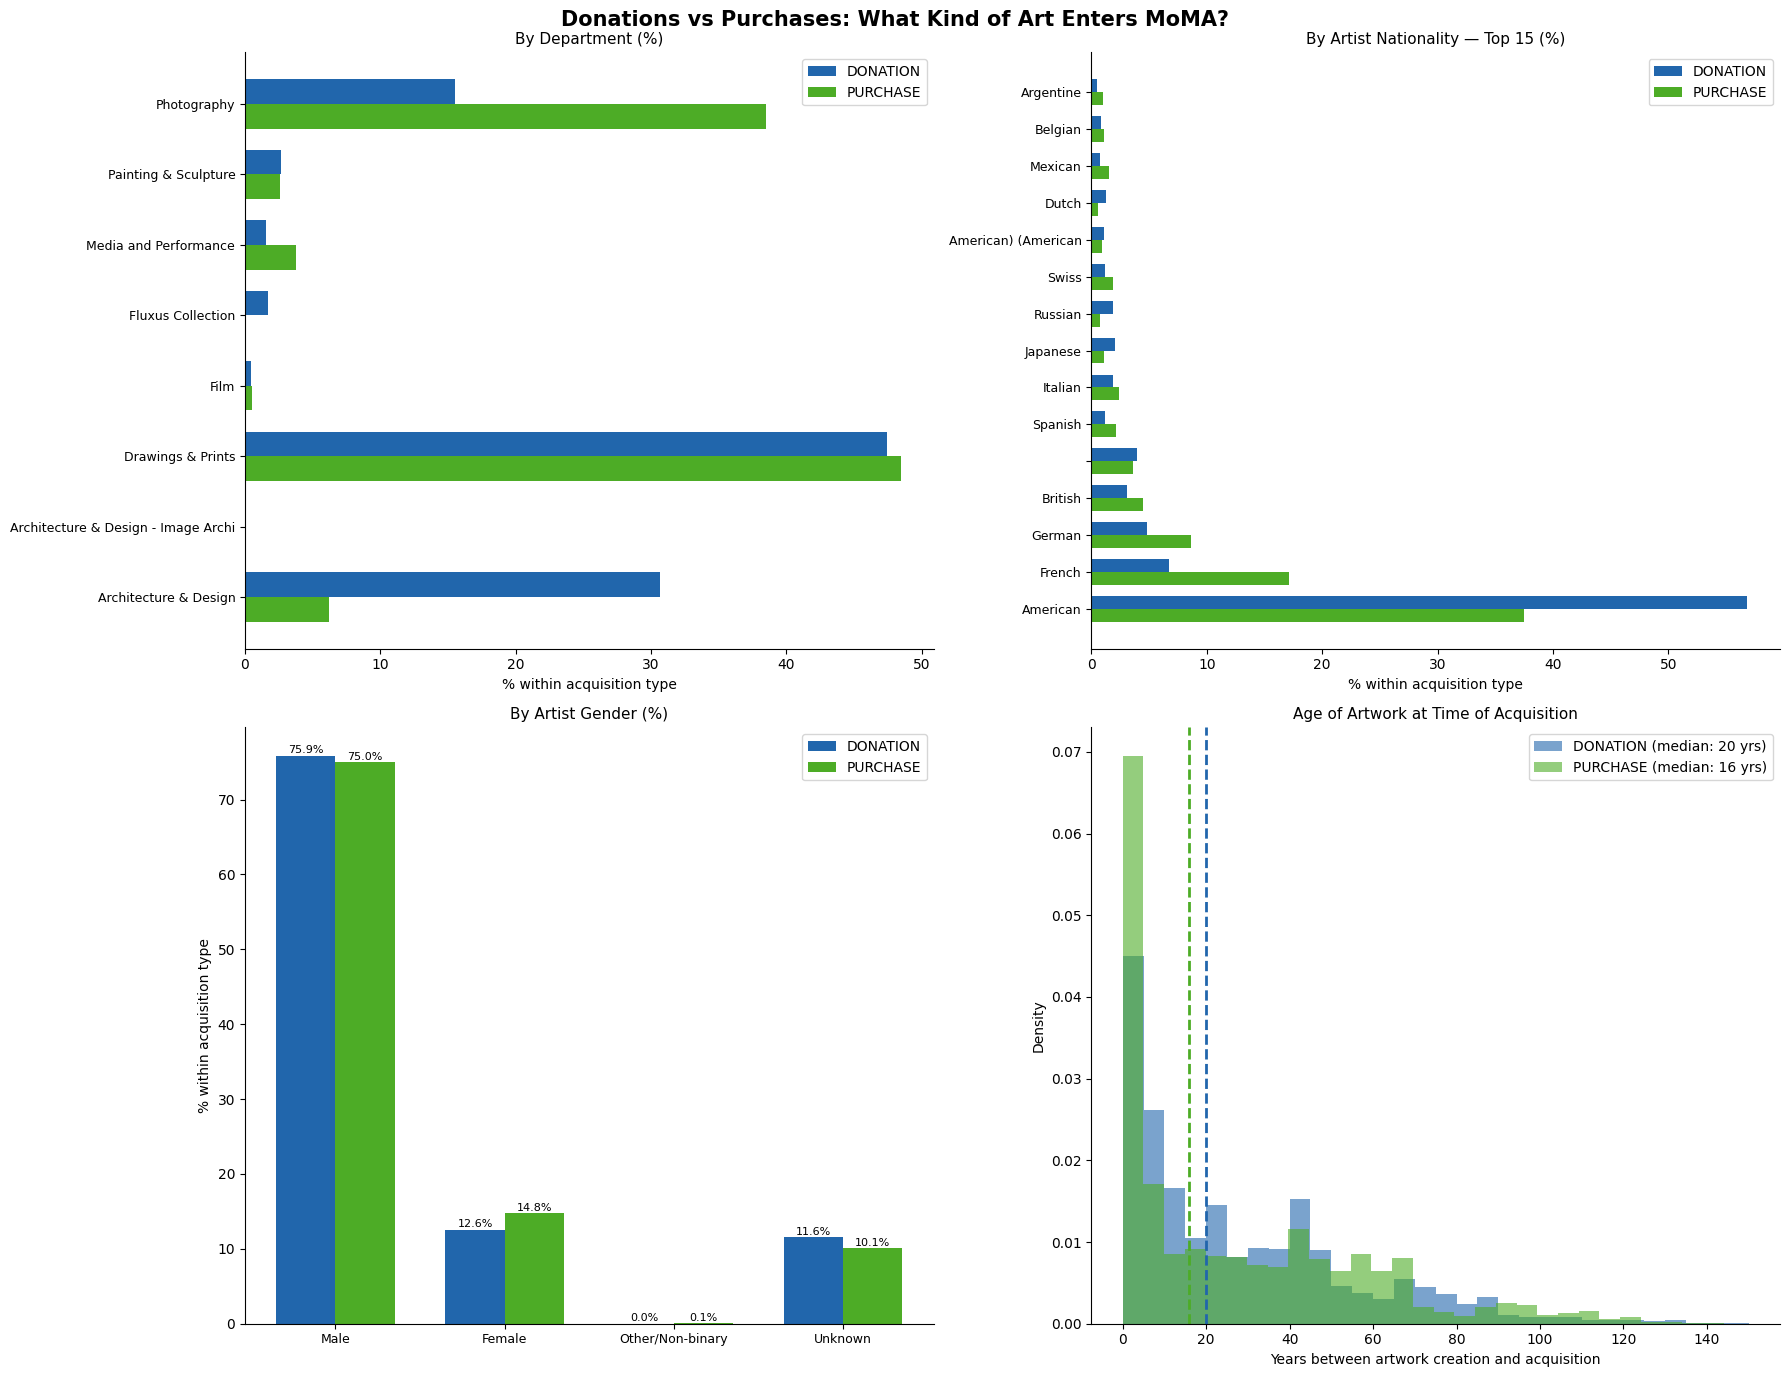

Saved.


In [44]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Donations vs Purchases: What Kind of Art Enters MoMA?',
             fontsize=15, fontweight='bold')

don = df_gender[df_gender['AcquisitionFinal'] == 'DONATION']
pur = df_gender[df_gender['AcquisitionFinal'] == 'PURCHASE']
width = 0.35

# ── Chart 1: Department breakdown ──
ax1 = axes[0, 0]
don_dept = don['Department'].value_counts(normalize=True) * 100
pur_dept = pur['Department'].value_counts(normalize=True) * 100
all_depts = don_dept.index.union(pur_dept.index)
don_dept = don_dept.reindex(all_depts, fill_value=0)
pur_dept = pur_dept.reindex(all_depts, fill_value=0)

x = range(len(all_depts))
ax1.barh([i + width/2 for i in x], don_dept.values,
         height=width, color='#2166ac', label='DONATION')
ax1.barh([i - width/2 for i in x], pur_dept.values,
         height=width, color='#4dac26', label='PURCHASE')
ax1.set_yticks(x)
ax1.set_yticklabels([d[:35] for d in all_depts], fontsize=9)
ax1.set_title('By Department (%)', fontsize=11)
ax1.set_xlabel('% within acquisition type')
ax1.legend()
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ── Chart 2: Top 15 nationalities ──
ax2 = axes[0, 1]
top_nats = df_gender['NationalityClean'].value_counts().head(15).index
don_nat = don['NationalityClean'].value_counts(normalize=True).reindex(top_nats, fill_value=0) * 100
pur_nat = pur['NationalityClean'].value_counts(normalize=True).reindex(top_nats, fill_value=0) * 100

x = range(len(top_nats))
ax2.barh([i + width/2 for i in x], don_nat.values,
         height=width, color='#2166ac', label='DONATION')
ax2.barh([i - width/2 for i in x], pur_nat.values,
         height=width, color='#4dac26', label='PURCHASE')
ax2.set_yticks(x)
ax2.set_yticklabels(top_nats, fontsize=9)
ax2.set_title('By Artist Nationality — Top 15 (%)', fontsize=11)
ax2.set_xlabel('% within acquisition type')
ax2.legend()
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# ── Chart 3: Gender breakdown ──
ax3 = axes[1, 0]
genders = ['Male', 'Female', 'Other/Non-binary', 'Unknown']
don_vals = [don['GenderSimple'].value_counts(normalize=True).get(g, 0) * 100 for g in genders]
pur_vals = [pur['GenderSimple'].value_counts(normalize=True).get(g, 0) * 100 for g in genders]

x = range(len(genders))
ax3.bar([i - width/2 for i in x], don_vals,
        width=width, color='#2166ac', label='DONATION')
ax3.bar([i + width/2 for i in x], pur_vals,
        width=width, color='#4dac26', label='PURCHASE')
ax3.set_xticks(x)
ax3.set_xticklabels(genders, fontsize=9)
ax3.set_title('By Artist Gender (%)', fontsize=11)
ax3.set_ylabel('% within acquisition type')
ax3.legend()
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

for i, (d, p) in enumerate(zip(don_vals, pur_vals)):
    ax3.text(i - width/2, d + 0.3, f'{d:.1f}%', ha='center', fontsize=8)
    ax3.text(i + width/2, p + 0.3, f'{p:.1f}%', ha='center', fontsize=8)

# ── Chart 4: Age of artwork at acquisition ──
ax4 = axes[1, 1]
don_age = don['AgeAtAcquisition'].dropna()
pur_age = pur['AgeAtAcquisition'].dropna()
don_age = don_age[(don_age >= 0) & (don_age <= 150)]
pur_age = pur_age[(pur_age >= 0) & (pur_age <= 150)]

ax4.hist(don_age, bins=30, alpha=0.6, color='#2166ac',
         label=f'DONATION (median: {don_age.median():.0f} yrs)', density=True)
ax4.hist(pur_age, bins=30, alpha=0.6, color='#4dac26',
         label=f'PURCHASE (median: {pur_age.median():.0f} yrs)', density=True)
ax4.axvline(don_age.median(), color='#2166ac', linestyle='--', linewidth=2)
ax4.axvline(pur_age.median(), color='#4dac26', linestyle='--', linewidth=2)
ax4.set_title('Age of Artwork at Time of Acquisition', fontsize=11)
ax4.set_xlabel('Years between artwork creation and acquisition')
ax4.set_ylabel('Density')
ax4.legend()
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('data/donation_vs_purchase_detail.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [47]:
# Fix type issue before apply
df_gender['EndDate'] = pd.to_numeric(df_gender['EndDate'], errors='coerce')
df_gender['YearAcquired'] = pd.to_numeric(df_gender['YearAcquired'], errors='coerce')

def artist_status(row):
    if pd.isna(row['EndDate']):
        return 'Living'
    elif pd.isna(row['YearAcquired']):
        return 'Unknown'
    elif row['EndDate'] < row['YearAcquired']:
        return 'Deceased at acquisition'
    else:
        return 'Living'

df_gender['ArtistStatus'] = df_gender.apply(artist_status, axis=1)

print("Done.")
print(df_gender['ArtworkPeriod'].value_counts())
print(df_gender['ArtistStatus'].value_counts())

Done.
ArtworkPeriod
1945–1969       47602
1900–1944       46744
1970–1989       27818
1990–2009       21169
19th century     6952
2010–present     5797
Unknown          4428
Before 1800        87
Name: count, dtype: int64
ArtistStatus
Living    160597
Name: count, dtype: int64


In [49]:
# Use the correct column
df_gender['EndDate'] = pd.to_numeric(df_gender['EndDate_artist'], errors='coerce')

def artist_status(row):
    if pd.isna(row['EndDate']):
        return 'Living'
    elif pd.isna(row['YearAcquired']):
        return 'Unknown'
    elif row['EndDate'] < row['YearAcquired']:
        return 'Deceased at acquisition'
    else:
        return 'Living'

df_gender['ArtistStatus'] = df_gender.apply(artist_status, axis=1)

print(df_gender['ArtistStatus'].value_counts())
print(f"\nEndDate non-null: {df_gender['EndDate'].notna().sum():,}")

ArtistStatus
Living                     111358
Deceased at acquisition     44863
Unknown                      4376
Name: count, dtype: int64

EndDate non-null: 108,347


In [56]:
recent_purchase = df_gender[
    (df_gender['ArtworkPeriod'] == '2010–present') &
    (df_gender['AcquisitionFinal'] == 'PURCHASE') &
    (df_gender['ArtworkYear'] <= 2026)  # exclude bad years
]
print(f"\n=== FUNDS BUYING 2010+ ART ===")
print(f"Total: {len(recent_purchase):,}")
print(recent_purchase['CreditLine'].value_counts().head(15).to_string())


=== FUNDS BUYING 2010+ ART ===
Total: 3,425
CreditLine
Fund for the Twenty-First Century                                                                                                                                                                                                                                                                                                                                                      716
Committee on Architecture and Design Funds                                                                                                                                                                                                                                                                                                                                             309
Acquired through the generosity of Mary M. and Sash A. Spencer                                                                                                                            

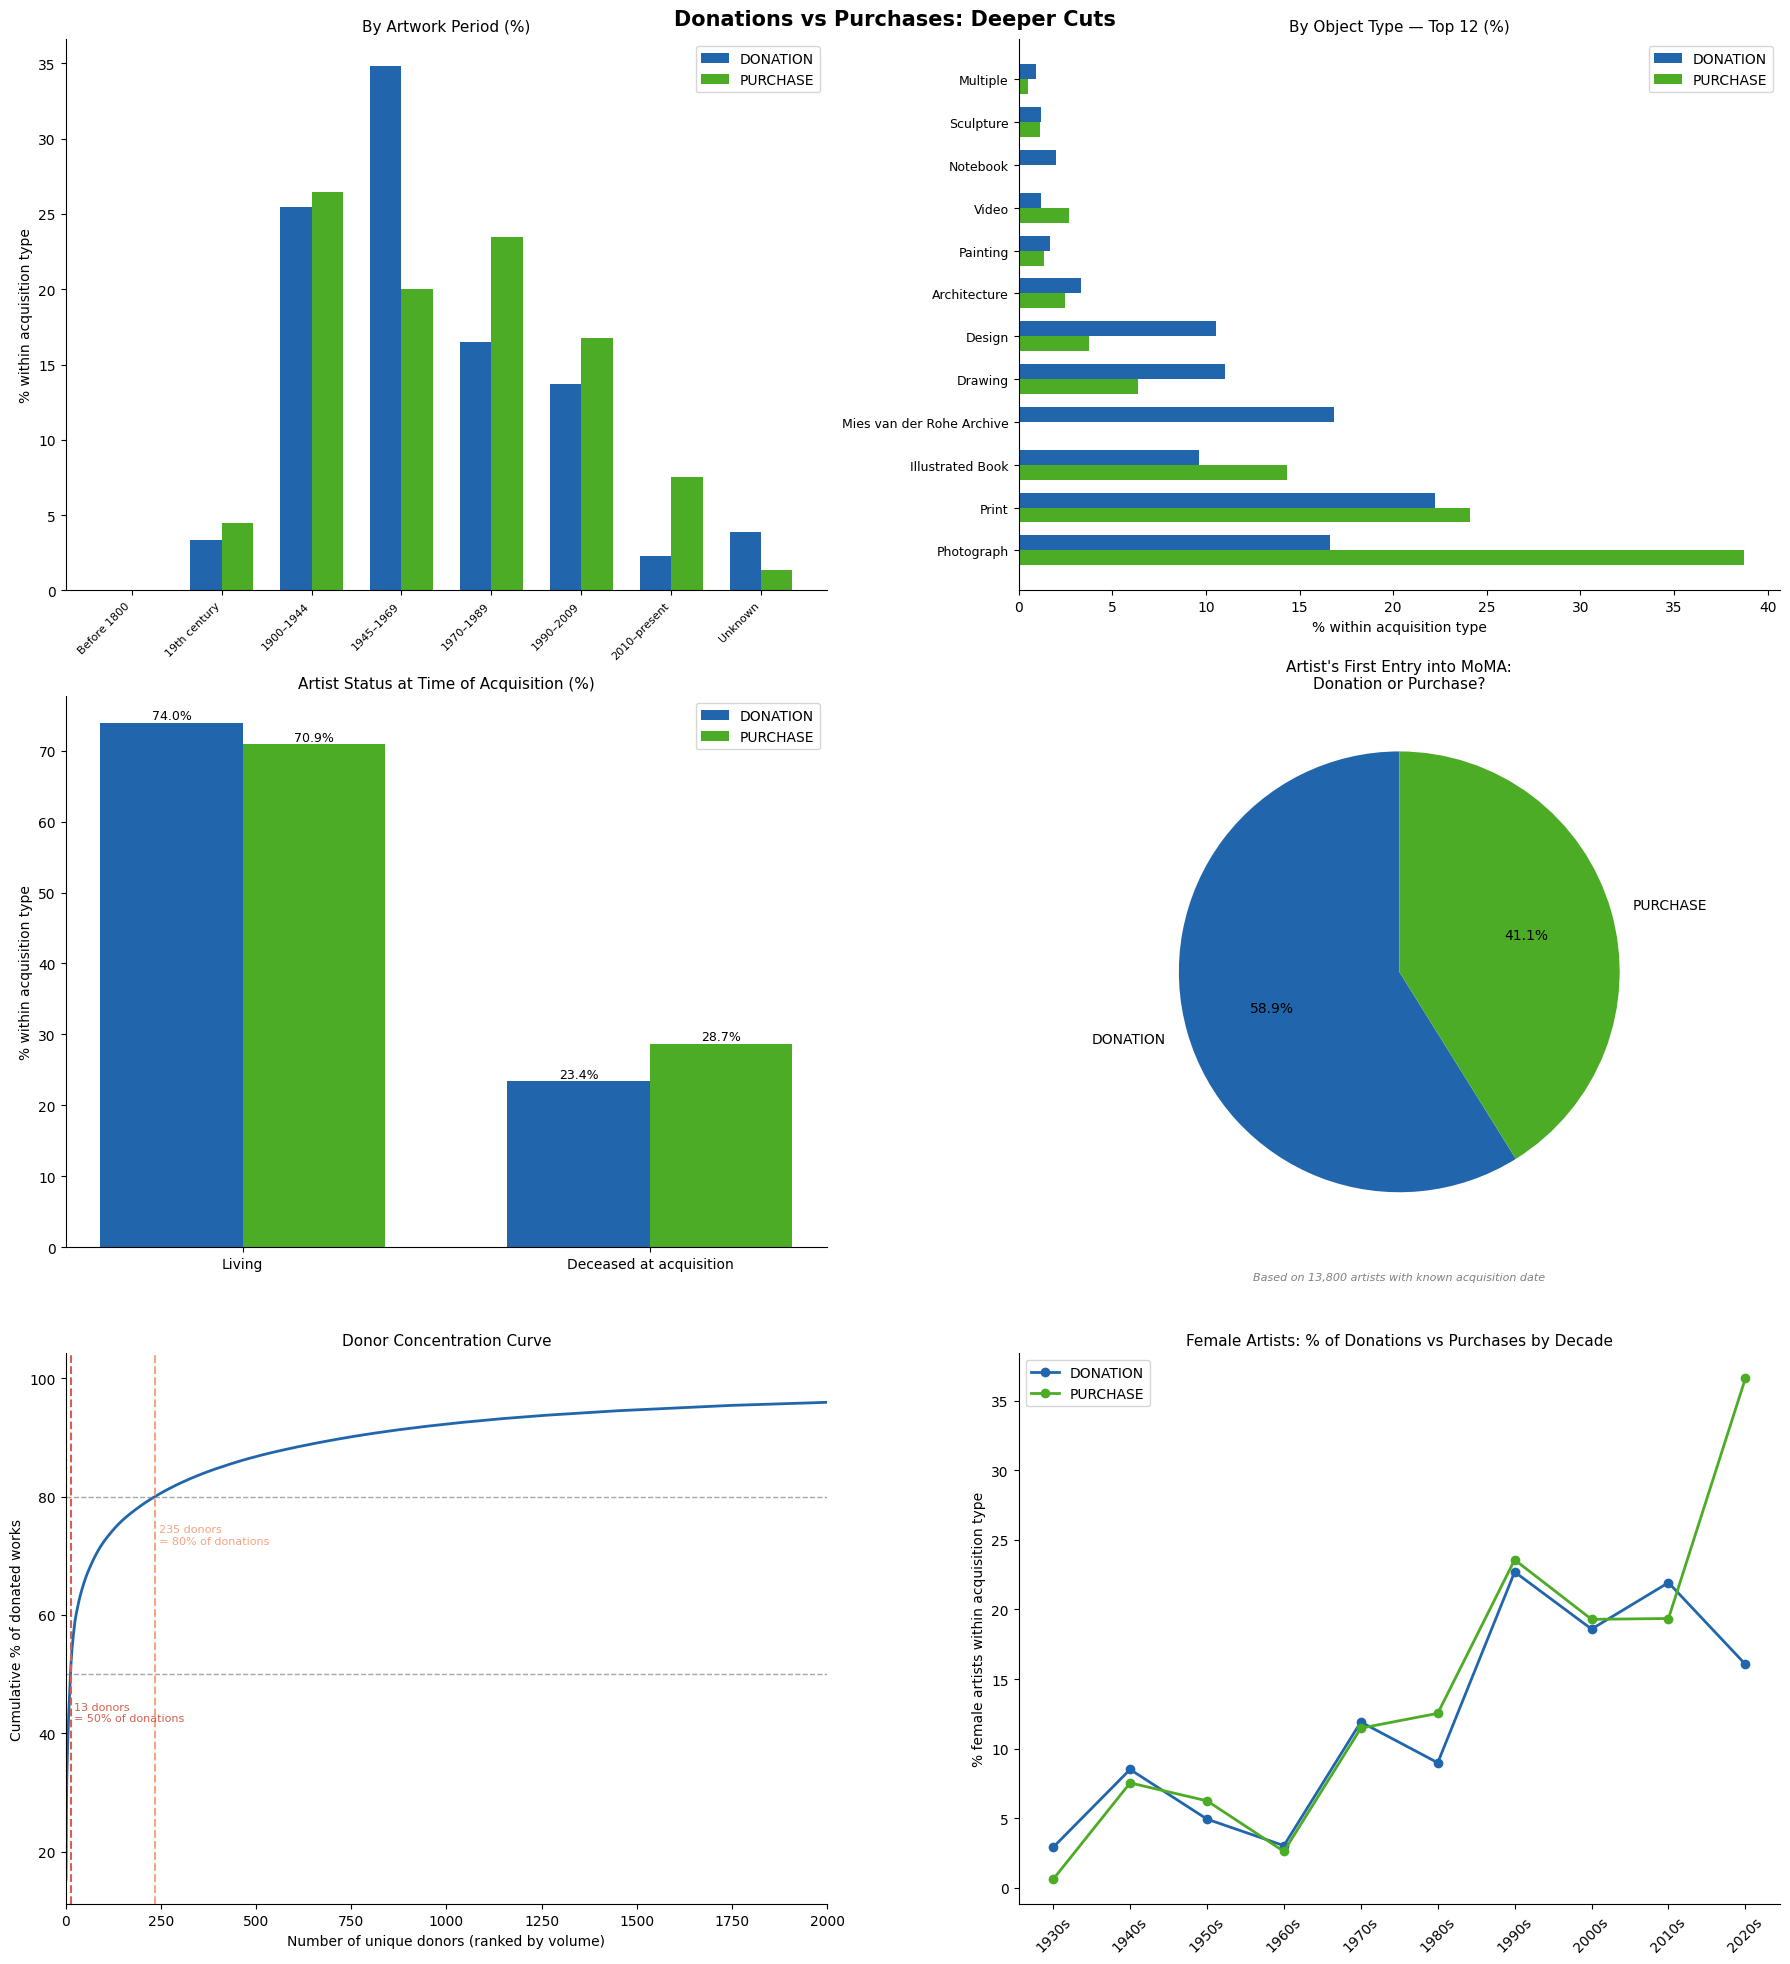

Saved.


In [50]:
fig, axes = plt.subplots(3, 2, figsize=(18, 20))
fig.suptitle('Donations vs Purchases: Deeper Cuts', fontsize=15, fontweight='bold')

don = df_gender[df_gender['AcquisitionFinal'] == 'DONATION']
pur = df_gender[df_gender['AcquisitionFinal'] == 'PURCHASE']
width = 0.35

# ── Chart 1: Period of artwork ──
ax1 = axes[0, 0]
periods = ['Before 1800', '19th century', '1900–1944', '1945–1969',
           '1970–1989', '1990–2009', '2010–present', 'Unknown']

don_period = don['ArtworkPeriod'].value_counts(normalize=True).reindex(periods, fill_value=0) * 100
pur_period = pur['ArtworkPeriod'].value_counts(normalize=True).reindex(periods, fill_value=0) * 100

x = range(len(periods))
ax1.bar([i - width/2 for i in x], don_period.values,
        width=width, color='#2166ac', label='DONATION')
ax1.bar([i + width/2 for i in x], pur_period.values,
        width=width, color='#4dac26', label='PURCHASE')
ax1.set_xticks(x)
ax1.set_xticklabels(periods, rotation=45, ha='right', fontsize=8)
ax1.set_title('By Artwork Period (%)', fontsize=11)
ax1.set_ylabel('% within acquisition type')
ax1.legend()
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ── Chart 2: Classification ──
ax2 = axes[0, 1]
top_class = df_gender['Classification'].value_counts().head(12).index
don_class = don['Classification'].value_counts(normalize=True).reindex(top_class, fill_value=0) * 100
pur_class = pur['Classification'].value_counts(normalize=True).reindex(top_class, fill_value=0) * 100

x = range(len(top_class))
ax2.barh([i + width/2 for i in x], don_class.values,
         height=width, color='#2166ac', label='DONATION')
ax2.barh([i - width/2 for i in x], pur_class.values,
         height=width, color='#4dac26', label='PURCHASE')
ax2.set_yticks(x)
ax2.set_yticklabels([c[:30] for c in top_class], fontsize=9)
ax2.set_title('By Object Type — Top 12 (%)', fontsize=11)
ax2.set_xlabel('% within acquisition type')
ax2.legend()
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# ── Chart 3: Artist alive vs dead ──
ax3 = axes[1, 0]
statuses = ['Living', 'Deceased at acquisition']
don_status = don['ArtistStatus'].value_counts(normalize=True).reindex(statuses, fill_value=0) * 100
pur_status = pur['ArtistStatus'].value_counts(normalize=True).reindex(statuses, fill_value=0) * 100

x = range(len(statuses))
ax3.bar([i - width/2 for i in x], don_status.values,
        width=width, color='#2166ac', label='DONATION')
ax3.bar([i + width/2 for i in x], pur_status.values,
        width=width, color='#4dac26', label='PURCHASE')
ax3.set_xticks(x)
ax3.set_xticklabels(statuses, fontsize=10)
ax3.set_title('Artist Status at Time of Acquisition (%)', fontsize=11)
ax3.set_ylabel('% within acquisition type')
ax3.legend()
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

for i, (d, p) in enumerate(zip(don_status.values, pur_status.values)):
    ax3.text(i - width/2, d + 0.5, f'{d:.1f}%', ha='center', fontsize=9)
    ax3.text(i + width/2, p + 0.5, f'{p:.1f}%', ha='center', fontsize=9)

# ── Chart 4: First entry per artist ──
ax4 = axes[1, 1]
first_entry = df_gender.sort_values('YearAcquired').groupby('ConstituentID').first().reset_index()
first_entry = first_entry[first_entry['AcquisitionFinal'].isin(['DONATION', 'PURCHASE'])]
first_counts = first_entry['AcquisitionFinal'].value_counts()

colors_pie = ['#2166ac', '#4dac26']
wedges, texts, autotexts = ax4.pie(
    first_counts.values, labels=first_counts.index,
    colors=colors_pie, autopct='%1.1f%%', startangle=90)
ax4.set_title("Artist's First Entry into MoMA:\nDonation or Purchase?", fontsize=11)
ax4.text(0, -1.4, f'Based on {first_counts.sum():,} artists with known acquisition date',
         ha='center', fontsize=8, style='italic', color='gray')

# ── Chart 5: Donor concentration curve ──
ax5 = axes[2, 0]
donor_counts = don['CreditLine'].value_counts()
total_don = donor_counts.sum()
cumulative = (donor_counts.cumsum() / total_don * 100).values
n_donors = range(1, len(cumulative) + 1)

ax5.plot(list(n_donors), cumulative, color='#2166ac', linewidth=2)
ax5.axhline(50, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax5.axhline(80, color='gray', linestyle='--', linewidth=1, alpha=0.7)

idx_50 = next(i for i, v in enumerate(cumulative) if v >= 50) + 1
idx_80 = next(i for i, v in enumerate(cumulative) if v >= 80) + 1

ax5.axvline(idx_50, color='#d6604d', linestyle='--', linewidth=1.5)
ax5.axvline(idx_80, color='#f4a582', linestyle='--', linewidth=1.5)
ax5.text(idx_50 + 10, 42, f'{idx_50} donors\n= 50% of donations',
         fontsize=8, color='#d6604d')
ax5.text(idx_80 + 10, 72, f'{idx_80} donors\n= 80% of donations',
         fontsize=8, color='#f4a582')

ax5.set_title('Donor Concentration Curve', fontsize=11)
ax5.set_xlabel('Number of unique donors (ranked by volume)')
ax5.set_ylabel('Cumulative % of donated works')
ax5.set_xlim(0, min(2000, len(cumulative)))
ax5.spines['top'].set_visible(False)
ax5.spines['right'].set_visible(False)

# ── Chart 6: Female artists % by decade — donation vs purchase ──
ax6 = axes[2, 1]
don_decade = don.groupby('Decade').size()
pur_decade = pur.groupby('Decade').size()
female_don_decade = don[don['GenderSimple'] == 'Female'].groupby('Decade').size()
female_pur_decade = pur[pur['GenderSimple'] == 'Female'].groupby('Decade').size()

don_female_pct = (female_don_decade / don_decade * 100).dropna()
pur_female_pct = (female_pur_decade / pur_decade * 100).dropna()

decades = sorted(set(don_female_pct.index) | set(pur_female_pct.index))
decades = [d for d in decades if not pd.isna(d)]
don_vals = [don_female_pct.get(d, 0) for d in decades]
pur_vals = [pur_female_pct.get(d, 0) for d in decades]
decade_labels = [f"{int(d)}s" for d in decades]

ax6.plot(decade_labels, don_vals, color='#2166ac', marker='o',
         linewidth=2, label='DONATION')
ax6.plot(decade_labels, pur_vals, color='#4dac26', marker='o',
         linewidth=2, label='PURCHASE')
ax6.set_title('Female Artists: % of Donations vs Purchases by Decade', fontsize=11)
ax6.set_ylabel('% female artists within acquisition type')
ax6.tick_params(axis='x', rotation=45)
ax6.legend()
ax6.spines['top'].set_visible(False)
ax6.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('data/deeper_cuts.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [51]:
# Confirm: artwork period distribution by acquisition type
print("=== ARTWORK PERIOD: DONATION vs PURCHASE (absolute counts) ===\n")

period_counts = df_gender.groupby(['ArtworkPeriod', 'AcquisitionFinal']).size().unstack(fill_value=0)
period_pct = period_counts.div(period_counts.sum(axis=1), axis=0) * 100

# Order periods chronologically
order = ['Before 1800', '19th century', '1900–1944', '1945–1969',
         '1970–1989', '1990–2009', '2010–present', 'Unknown']

period_counts = period_counts.reindex(order)
period_pct = period_pct.reindex(order)

print(f"{'Period':<20} {'DONATION':>10} {'PURCHASE':>10} {'HYBRID':>10} {'DON%':>8} {'PUR%':>8}")
print("-" * 70)
for period in order:
    if period in period_counts.index:
        don = period_counts.loc[period, 'DONATION'] if 'DONATION' in period_counts.columns else 0
        pur = period_counts.loc[period, 'PURCHASE'] if 'PURCHASE' in period_counts.columns else 0
        hyb = period_counts.loc[period, 'HYBRID'] if 'HYBRID' in period_counts.columns else 0
        don_pct = period_pct.loc[period, 'DONATION'] if 'DONATION' in period_pct.columns else 0
        pur_pct = period_pct.loc[period, 'PURCHASE'] if 'PURCHASE' in period_pct.columns else 0
        print(f"{period:<20} {don:>10,} {pur:>10,} {hyb:>10,} {don_pct:>7.1f}% {pur_pct:>7.1f}%")

=== ARTWORK PERIOD: DONATION vs PURCHASE (absolute counts) ===

Period                 DONATION   PURCHASE     HYBRID     DON%     PUR%
----------------------------------------------------------------------
Before 1800                   5          1          0     5.7%     1.1%
19th century              3,225      2,046          2    46.4%    29.4%
1900–1944                24,634     12,082        120    52.7%    25.8%
1945–1969                33,740      9,146        404    70.9%    19.2%
1970–1989                15,983     10,705        395    57.5%    38.5%
1990–2009                13,292      7,643         40    62.8%    36.1%
2010–present              2,192      3,425          6    37.8%    59.1%
Unknown                   3,725        610         15    84.1%    13.8%


In [52]:
# How many total works per period?
print("=== TOTAL WORKS PER PERIOD ===")
total_per_period = df_gender.groupby('ArtworkPeriod').size().reindex(order)
print(total_per_period)

# What years are in "2010-present"?
# Are these works actually created 2010+ or could ArtworkYear be wrong?
recent = df_gender[df_gender['ArtworkPeriod'] == '2010–present']
print(f"\n=== 2010-PRESENT DETAIL ===")
print(f"Total works: {len(recent):,}")
print(f"ArtworkYear range: {recent['ArtworkYear'].min():.0f} to {recent['ArtworkYear'].max():.0f}")
print(f"YearAcquired range: {recent['YearAcquired'].min():.0f} to {recent['YearAcquired'].max():.0f}")
print(f"\nAcquisition type breakdown:")
print(recent['AcquisitionType'].value_counts())

=== TOTAL WORKS PER PERIOD ===
ArtworkPeriod
Before 1800        87
19th century     6952
1900–1944       46744
1945–1969       47602
1970–1989       27818
1990–2009       21169
2010–present     5797
Unknown          4428
dtype: int64

=== 2010-PRESENT DETAIL ===
Total works: 5,797
ArtworkYear range: 2010 to 3000
YearAcquired range: 2005 to 2026

Acquisition type breakdown:
AcquisitionType
Fund                         2449
Gift                         1751
Other                        1021
Gift of the artist            403
Unknown                        68
Purchase                       49
Bequest                        29
Exchange                       13
Anonymous                       8
Purchase and gift (mixed)       6
Name: count, dtype: int64


In [58]:
# Focus: artwork period 2000+ — donations vs purchases vs hybrid
print("=== ARTWORK PERIOD 2000+: FULL BREAKDOWN ===\n")

recent = df_gender[
    (df_gender['ArtworkYear'] >= 2000) & 
    (df_gender['ArtworkYear'] <= 2026)
].copy()

print(f"Total works created 2000+: {len(recent):,}")

print("\nBy acquisition type (absolute):")
print(recent['AcquisitionFinal'].value_counts())

print("\nBy acquisition type (%):")
print((recent['AcquisitionFinal'].value_counts(normalize=True) * 100).round(1))

# By year
year_acq = recent.groupby(['ArtworkYear', 'AcquisitionFinal']).size().unstack(fill_value=0)
for col in ['DONATION', 'PURCHASE', 'HYBRID', 'OTHER']:
    if col not in year_acq.columns:
        year_acq[col] = 0

year_pct = year_acq[['DONATION','PURCHASE','HYBRID','OTHER']].div(
    year_acq[['DONATION','PURCHASE','HYBRID','OTHER']].sum(axis=1), axis=0) * 100

print("\nYear | DONATION% | PURCHASE% | HYBRID | OTHER | TOTAL")
print("-" * 60)
for year in sorted(year_acq.index):
    don = year_acq.loc[year, 'DONATION']
    pur = year_acq.loc[year, 'PURCHASE']
    hyb = year_acq.loc[year, 'HYBRID']
    oth = year_acq.loc[year, 'OTHER']
    total = don + pur + hyb + oth
    don_pct = year_pct.loc[year, 'DONATION']
    pur_pct = year_pct.loc[year, 'PURCHASE']
    print(f"{int(year)} | {don_pct:>8.1f}% | {pur_pct:>8.1f}% | {int(hyb):>6} | {int(oth):>5} | {int(total):>5}")

=== ARTWORK PERIOD 2000+: FULL BREAKDOWN ===

Total works created 2000+: 16,503

By acquisition type (absolute):
AcquisitionFinal
DONATION    8466
PURCHASE    7734
OTHER        267
HYBRID        36
Name: count, dtype: int64

By acquisition type (%):
AcquisitionFinal
DONATION    51.3
PURCHASE    46.9
OTHER        1.6
HYBRID       0.2
Name: proportion, dtype: float64

Year | DONATION% | PURCHASE% | HYBRID | OTHER | TOTAL
------------------------------------------------------------
2000 |     59.6% |     40.1% |      1 |     3 |  1036
2001 |     68.9% |     30.3% |      2 |     7 |  1262
2002 |     70.9% |     27.6% |      2 |    17 |  1262
2003 |     76.8% |     22.0% |     12 |     5 |  1542
2004 |     58.9% |     40.5% |      7 |     0 |  1179
2005 |     57.0% |     41.8% |      2 |     9 |   947
2006 |     40.9% |     58.8% |      0 |     4 |  1123
2007 |     43.5% |     56.1% |      2 |     1 |   806
2008 |     34.5% |     64.0% |      1 |    13 |   913
2009 |     54.8% |     39.7% |

In [59]:
first_entry = df_gender[df_gender['AcquisitionFinal'].isin(['DONATION','PURCHASE'])]\
    .sort_values('YearAcquired')\
    .groupby('ConstituentID')\
    .first()\
    .reset_index()

print("=== FIRST ENTRY VIA DONATION: ARTWORK PERIOD ===")
don_first = first_entry[first_entry['AcquisitionFinal'] == 'DONATION']
print(don_first['ArtworkPeriod'].value_counts())

print("\n=== FIRST ENTRY VIA PURCHASE: ARTWORK PERIOD ===")
pur_first = first_entry[first_entry['AcquisitionFinal'] == 'PURCHASE']
print(pur_first['ArtworkPeriod'].value_counts())

=== FIRST ENTRY VIA DONATION: ARTWORK PERIOD ===
ArtworkPeriod
1945–1969       2433
1900–1944       1863
1970–1989       1614
1990–2009       1417
2010–present     373
19th century     319
Unknown          171
Before 1800        1
Name: count, dtype: int64

=== FIRST ENTRY VIA PURCHASE: ARTWORK PERIOD ===
ArtworkPeriod
1970–1989       1465
1945–1969       1453
1990–2009       1138
1900–1944        900
2010–present     449
19th century     268
Unknown           54
Before 1800        1
Name: count, dtype: int64


In [60]:
# Classify each artist as "first timer" or "returning" per year
# Sort all acquisitions by year
df_sorted = df_gender[df_gender['AcquisitionFinal'].isin(['DONATION','PURCHASE'])]\
    .sort_values('YearAcquired').copy()

# Mark first appearance per artist
df_sorted['IsFirstEntry'] = ~df_sorted.duplicated(subset='ConstituentID', keep='first')

df_sorted['EntryType'] = df_sorted['IsFirstEntry'].map({
    True: 'First Entry',
    False: 'Returning'
})

print("=== OVERALL: FIRST ENTRY vs RETURNING ===")
print(df_sorted['EntryType'].value_counts())
print(df_sorted['EntryType'].value_counts(normalize=True) * 100)

print("\n=== FIRST ENTRY: DONATION vs PURCHASE ===")
first = df_sorted[df_sorted['EntryType'] == 'First Entry']
print(first['AcquisitionFinal'].value_counts())
print((first['AcquisitionFinal'].value_counts(normalize=True) * 100).round(1))

print("\n=== RETURNING: DONATION vs PURCHASE ===")
returning = df_sorted[df_sorted['EntryType'] == 'Returning']
print(returning['AcquisitionFinal'].value_counts())
print((returning['AcquisitionFinal'].value_counts(normalize=True) * 100).round(1))

print("\n=== BY DECADE: FIRST ENTRY vs RETURNING ===")
decade_entry = df_sorted.groupby(['Decade','EntryType']).size().unstack(fill_value=0)
decade_pct = decade_entry.div(decade_entry.sum(axis=1), axis=0) * 100
decade_pct = decade_pct[decade_pct.index.notna()]
decade_pct.index = [f"{int(d)}s" for d in decade_pct.index]
print(decade_pct.round(1).to_string())

=== OVERALL: FIRST ENTRY vs RETURNING ===
EntryType
Returning      128534
First Entry     13920
Name: count, dtype: int64
EntryType
Returning      90.228425
First Entry     9.771575
Name: proportion, dtype: float64

=== FIRST ENTRY: DONATION vs PURCHASE ===
AcquisitionFinal
DONATION    8191
PURCHASE    5729
Name: count, dtype: int64
AcquisitionFinal
DONATION    58.8
PURCHASE    41.2
Name: proportion, dtype: float64

=== RETURNING: DONATION vs PURCHASE ===
AcquisitionFinal
DONATION    88605
PURCHASE    39929
Name: count, dtype: int64
AcquisitionFinal
DONATION    68.9
PURCHASE    31.1
Name: proportion, dtype: float64

=== BY DECADE: FIRST ENTRY vs RETURNING ===
EntryType  First Entry  Returning
1920s             66.7       33.3
1930s             22.5       77.5
1940s             14.6       85.4
1950s             18.8       81.2
1960s              5.2       94.8
1970s              9.5       90.5
1980s             14.3       85.7
1990s             10.7       89.3
2000s             11.4    

In [62]:
print("=== TOP 20 RETURNING ARTISTS (most works after first entry) ===")
returning_counts = returning['ConstituentID'].value_counts().head(20)
id_to_name = df_gender.set_index('ConstituentID')['Artist'].to_dict()
for aid, count in returning_counts.items():
    print(f"  {count:,}x — {id_to_name.get(aid, 'Unknown')}")

=== TOP 20 RETURNING ARTISTS (most works after first entry) ===
  16,291x — Ludwig Mies van der Rohe
  5,001x — Eugène Atget
  3,322x — Louise Bourgeois
  2,730x — Unidentified photographer
  2,153x — Ellsworth Kelly
  1,319x — Lee Friedlander
  1,287x — Jean Dubuffet
  799x — George Maciunas
  749x — August Sander
  664x — Ben Kinmont
  662x — Pablo Picasso
  643x — Unknown artist
  600x — Sol LeWitt
  516x — Henri Matisse
  481x — Frédéric Bruly Bouabré
  473x — Dorothea Lange
  427x — Pierre Alechinsky
  424x — Jasper Johns
  419x — Jan Dibbets
  362x — Walker Evans


In [65]:
print("=== ARTWORK PERIOD OF RETURNING ARTISTS ===")
print(returning['ArtworkPeriod'].value_counts())
print()
print((returning['ArtworkPeriod'].value_counts(normalize=True) * 100).round(1))


=== ARTWORK PERIOD OF RETURNING ARTISTS ===
ArtworkPeriod
1945–1969       39000
1900–1944       33952
1970–1989       23609
1990–2009       18380
2010–present     4795
19th century     4684
Unknown          4110
Before 1800         4
Name: count, dtype: int64

ArtworkPeriod
1945–1969       30.3
1900–1944       26.4
1970–1989       18.4
1990–2009       14.3
2010–present     3.7
19th century     3.6
Unknown          3.2
Before 1800      0.0
Name: proportion, dtype: float64


In [63]:
print("\n=== TOP 20 FIRST ENTRY ARTISTS (by year of first entry) ===")
first_sorted = first.sort_values('YearAcquired', ascending=False).head(20)
for _, row in first_sorted.iterrows():
    print(f"  {int(row['YearAcquired'])} — {row['Artist']} ({row['AcquisitionFinal']})")


=== TOP 20 FIRST ENTRY ARTISTS (by year of first entry) ===
  2026 — Gunter Eckert (PURCHASE)
  2026 — Tatiana Bilbao (DONATION)
  2026 — Ralph Lemon, Kevin Beasley (PURCHASE)
  2026 — Mildred Grossman (PURCHASE)
  2026 — John Habraken (DONATION)
  2026 — Maruch Sántiz Gómez (DONATION)
  2026 — Alix Cléo Roubaud (PURCHASE)
  2026 — Vân-Nhi Nguyễn (PURCHASE)
  2026 — Mauricio Rocha (DONATION)
  2026 — Rafael Gamo, Mauricio Rocha (DONATION)
  2026 — David Van Severen, Kersten Geers (DONATION)
  2026 — Tommy Kha (PURCHASE)
  2026 — Ren Hang (PURCHASE)
  2026 — EJ Hill (PURCHASE)
  2026 — Sarah Friedland (PURCHASE)
  2026 — Katherine Hubbard (PURCHASE)
  2026 — Oscar Niemeyer, Anna Maria Niemeyer (PURCHASE)
  2026 — Pia Arke (PURCHASE)
  2026 — Inuuteq Storch (PURCHASE)
  2026 — Uwe Fischer, Klaus Achim Heine (PURCHASE)


In [66]:
print("\n=== ARTIST DEBUTS BY YEAR ===")
debuts_by_year = first.groupby('YearAcquired').size()
debuts_by_year = debuts_by_year[debuts_by_year.index.notna()]
debuts_by_year.index = debuts_by_year.index.astype(int)
print(debuts_by_year.sort_index().to_string())
print(f"\nPeak year: {debuts_by_year.idxmax()} ({debuts_by_year.max():,} debuts)")
print(f"Average per year: {debuts_by_year.mean():.0f}")


=== ARTIST DEBUTS BY YEAR ===
YearAcquired
1929      6
1930      6
1931      3
1932      8
1933      2
1934     52
1935     51
1936     51
1937    129
1938     38
1939     55
1940    200
1941    150
1942    158
1943    145
1944     80
1945     33
1946     17
1947     84
1948     84
1949    132
1950     67
1951     79
1952     84
1953     97
1954    156
1955     60
1956    172
1957     61
1958    201
1959    213
1960    107
1961    141
1962     77
1963    158
1964    200
1965    208
1966    135
1967    278
1968    182
1969    193
1970    120
1971     72
1972     87
1973    117
1974    186
1975    102
1976    104
1977    175
1978    111
1979    164
1980     95
1981    162
1982    139
1983    163
1984    119
1985    114
1986    143
1987    180
1988    140
1989    101
1990    120
1991     85
1992    139
1993    135
1994     96
1995     75
1996    101
1997    125
1998    190
1999    119
2000    152
2001    568
2002     55
2003     71
2004    102
2005    536
2006    498
2007    210
2008    

In [67]:
# What happened in 2001, 2005, 2006, 2008?
for year in [2001, 2005, 2006, 2008, 2013, 2015]:
    print(f"\n=== {year} DEBUTS ===")
    year_debuts = first[first['YearAcquired'] == year]
    print(f"Total debuts: {len(year_debuts)}")
    print(f"By acquisition type:")
    print(year_debuts['AcquisitionFinal'].value_counts())
    print(f"Top CreditLines:")
    print(year_debuts['CreditLine'].value_counts().head(5).to_string())


=== 2001 DEBUTS ===
Total debuts: 568
By acquisition type:
AcquisitionFinal
DONATION    511
PURCHASE     57
Name: count, dtype: int64
Top CreditLines:
CreditLine
Gift of The Judith Rothschild Foundation                             220
Gift of The Judith Rothschild Foundation (Boris Kerdimun Archive)    118
Thomas Walther Collection. Gift of Thomas Walther                     33
Gift of the manufacturer                                              29
Given anonymously                                                     16

=== 2005 DEBUTS ===
Total debuts: 536
By acquisition type:
AcquisitionFinal
DONATION    453
PURCHASE     83
Name: count, dtype: int64
Top CreditLines:
CreditLine
The Judith Rothschild Foundation Contemporary Drawings Collection Gift    362
Gift of the manufacturer                                                   42
Purchase                                                                   31
Fund for the Twenty-First Century                                          

In [68]:
print("=== ARTWORK PERIOD OF ALL DEBUTS ===")
print(first['ArtworkPeriod'].value_counts())
print()
print((first['ArtworkPeriod'].value_counts(normalize=True) * 100).round(1))

print("\n=== PRE vs POST 2000 DEBUTS ===")
first['EraSimple'] = first['ArtworkYear'].apply(
    lambda x: 'Post-2000' if x >= 2000 else ('Pre-2000' if x < 2000 else 'Unknown')
)
print(first['EraSimple'].value_counts())
print((first['EraSimple'].value_counts(normalize=True) * 100).round(1))

print("\n=== PRE vs POST 2000 BY ACQUISITION TYPE ===")
era_acq = first.groupby(['EraSimple','AcquisitionFinal']).size().unstack(fill_value=0)
era_pct = era_acq.div(era_acq.sum(axis=1), axis=0) * 100
print(era_acq)
print()
print(era_pct.round(1))

=== ARTWORK PERIOD OF ALL DEBUTS ===
ArtworkPeriod
1945–1969       3886
1970–1989       3079
1900–1944       2764
1990–2009       2555
2010–present     822
19th century     587
Unknown          225
Before 1800        2
Name: count, dtype: int64

ArtworkPeriod
1945–1969       27.9
1970–1989       22.1
1900–1944       19.9
1990–2009       18.4
2010–present     5.9
19th century     4.2
Unknown          1.6
Before 1800      0.0
Name: proportion, dtype: float64

=== PRE vs POST 2000 DEBUTS ===
EraSimple
Pre-2000     11463
Post-2000     2232
Unknown        225
Name: count, dtype: int64
EraSimple
Pre-2000     82.3
Post-2000    16.0
Unknown       1.6
Name: proportion, dtype: float64

=== PRE vs POST 2000 BY ACQUISITION TYPE ===
AcquisitionFinal  DONATION  PURCHASE
EraSimple                           
Post-2000             1135      1097
Pre-2000              6885      4578
Unknown                171        54

AcquisitionFinal  DONATION  PURCHASE
EraSimple                           
Post-2000 

In [69]:
# 1) Who are the 822 artists debuting with 2010-present works?
print("=== ARTISTS DEBUTING WITH 2010-PRESENT WORKS ===")
debuts_2010 = first[first['ArtworkPeriod'] == '2010–present'].copy()
print(f"Total: {len(debuts_2010):,}")
print(f"\nBy acquisition type:")
print(debuts_2010['AcquisitionFinal'].value_counts())
print(f"\nBy nationality:")
print(debuts_2010['NationalityClean'].value_counts().head(20))
print(f"\nBy year of debut:")
print(debuts_2010['YearAcquired'].value_counts().sort_index())
print(f"\nSample artists:")
print(debuts_2010[['Artist','NationalityClean','YearAcquired','AcquisitionFinal','CreditLine']]\
      .sort_values('YearAcquired', ascending=False).head(20).to_string())

=== ARTISTS DEBUTING WITH 2010-PRESENT WORKS ===
Total: 822

By acquisition type:
AcquisitionFinal
PURCHASE    449
DONATION    373
Name: count, dtype: int64

By nationality:
NationalityClean
American               201
                        52
German                  29
British                 23
Japanese                17
Mexican                 17
Canadian                16
French                  16
American) (American     16
Brazilian               15
Chinese                 14
Swiss                   13
Chinese) (Chinese       12
Swiss)                  11
Dutch                   10
Colombian                7
Argentine                7
Nigerian                 7
Indian                   6
Peruvian                 6
Name: count, dtype: int64

By year of debut:
YearAcquired
2010.0     7
2011.0    23
2012.0    38
2013.0    92
2014.0    48
2015.0    75
2016.0    47
2017.0    45
2018.0    82
2019.0    28
2020.0    58
2021.0    51
2022.0    37
2023.0    44
2024.0    44
2025.0    74
202

In [70]:
# 2) Post-2000 debuts by year — concentration analysis
print("=== POST-2000 DEBUTS BY YEAR ===")
post2000_debuts = first[first['EraSimple'] == 'Post-2000'].copy()

by_year = post2000_debuts.groupby('YearAcquired').size()
by_year.index = by_year.index.astype(int)

by_year_acq = post2000_debuts.groupby(['YearAcquired','AcquisitionFinal']).size().unstack(fill_value=0)
by_year_acq.index = by_year_acq.index.astype(int)
by_year_pct = by_year_acq.div(by_year_acq.sum(axis=1), axis=0) * 100

print(f"\n{'Year':<8} {'Total':>8} {'DONATION':>10} {'PURCHASE':>10} {'DON%':>8} {'PUR%':>8}")
print("-" * 55)
for year in sorted(by_year_acq.index):
    total = by_year.get(year, 0)
    don = by_year_acq.loc[year, 'DONATION'] if 'DONATION' in by_year_acq.columns else 0
    pur = by_year_acq.loc[year, 'PURCHASE'] if 'PURCHASE' in by_year_acq.columns else 0
    don_pct = by_year_pct.loc[year, 'DONATION'] if 'DONATION' in by_year_pct.columns else 0
    pur_pct = by_year_pct.loc[year, 'PURCHASE'] if 'PURCHASE' in by_year_pct.columns else 0
    print(f"{year:<8} {total:>8} {int(don):>10} {int(pur):>10} {don_pct:>7.1f}% {pur_pct:>7.1f}%")

print(f"\nPeak year: {by_year.idxmax()} ({by_year.max()} debuts)")
print(f"Post-2019 average: {by_year[by_year.index >= 2019].mean():.0f} debuts/year")
print(f"Pre-2019 average (2000-2018): {by_year[by_year.index < 2019].mean():.0f} debuts/year")

=== POST-2000 DEBUTS BY YEAR ===

Year        Total   DONATION   PURCHASE     DON%     PUR%
-------------------------------------------------------
2000           10          3          7    30.0%    70.0%
2001           42         26         16    61.9%    38.1%
2002           21          9         12    42.9%    57.1%
2003           30         13         17    43.3%    56.7%
2004           50         21         29    42.0%    58.0%
2005          365        325         40    89.0%    11.0%
2006          317         65        252    20.5%    79.5%
2007          107         36         71    33.6%    66.4%
2008           91         55         36    60.4%    39.6%
2009           56         29         27    51.8%    48.2%
2010           52         26         26    50.0%    50.0%
2011           76         40         36    52.6%    47.4%
2012           71         42         29    59.2%    40.8%
2013          146         44        102    30.1%    69.9%
2014           70         29         41 

In [71]:
# Confirm: 2001 debuts by artwork period
print("=== 2001 DEBUTS BY ARTWORK PERIOD ===")
debuts_2001 = first[first['YearAcquired'] == 2001]
print(debuts_2001['ArtworkPeriod'].value_counts())
print(f"\nTotal: {len(debuts_2001)}")

# Confirm: 2005 debuts by artwork period  
print("\n=== 2005 DEBUTS BY ARTWORK PERIOD ===")
debuts_2005 = first[first['YearAcquired'] == 2005]
print(debuts_2005['ArtworkPeriod'].value_counts())
print(f"\nTotal: {len(debuts_2005)}")

=== 2001 DEBUTS BY ARTWORK PERIOD ===
ArtworkPeriod
1900–1944       425
1990–2009        84
1945–1969        34
1970–1989        19
Unknown           4
19th century      2
Name: count, dtype: int64

Total: 568

=== 2005 DEBUTS BY ARTWORK PERIOD ===
ArtworkPeriod
1990–2009       431
1900–1944        39
1970–1989        36
1945–1969        20
19th century      8
Unknown           2
Name: count, dtype: int64

Total: 536


In [72]:
# 3) Post-2019 debuts — who is entering and how?
print("=== POST-2019 DEBUTS: DETAIL ===")
post2019 = first[first['YearAcquired'] >= 2019].copy()

print(f"Total debuts 2019-2026: {len(post2019):,}")
print(f"\nBy acquisition type:")
print(post2019['AcquisitionFinal'].value_counts())
print(f"\nBy nationality (top 20):")
print(post2019['NationalityClean'].value_counts().head(20))
print(f"\nBy department:")
print(post2019['Department'].value_counts())
print(f"\nTop CreditLines:")
print(post2019['CreditLine'].value_counts().head(15).to_string())

=== POST-2019 DEBUTS: DETAIL ===
Total debuts 2019-2026: 772

By acquisition type:
AcquisitionFinal
PURCHASE    394
DONATION    378
Name: count, dtype: int64

By nationality (top 20):
NationalityClean
American                          224
Brazilian                          24
                                   23
American) (American                22
Mexican                            21
German                             20
British                            18
French                             15
Japanese                           14
Argentine                          13
Chinese) (Chinese                  13
Nigerian                           11
Canadian                           10
Chinese                            10
Italian                             9
Dutch                               9
Native American                     9
Indian                              8
American) (American) (American      7
Colombian                           7
Name: count, dtype: int64

By departmen

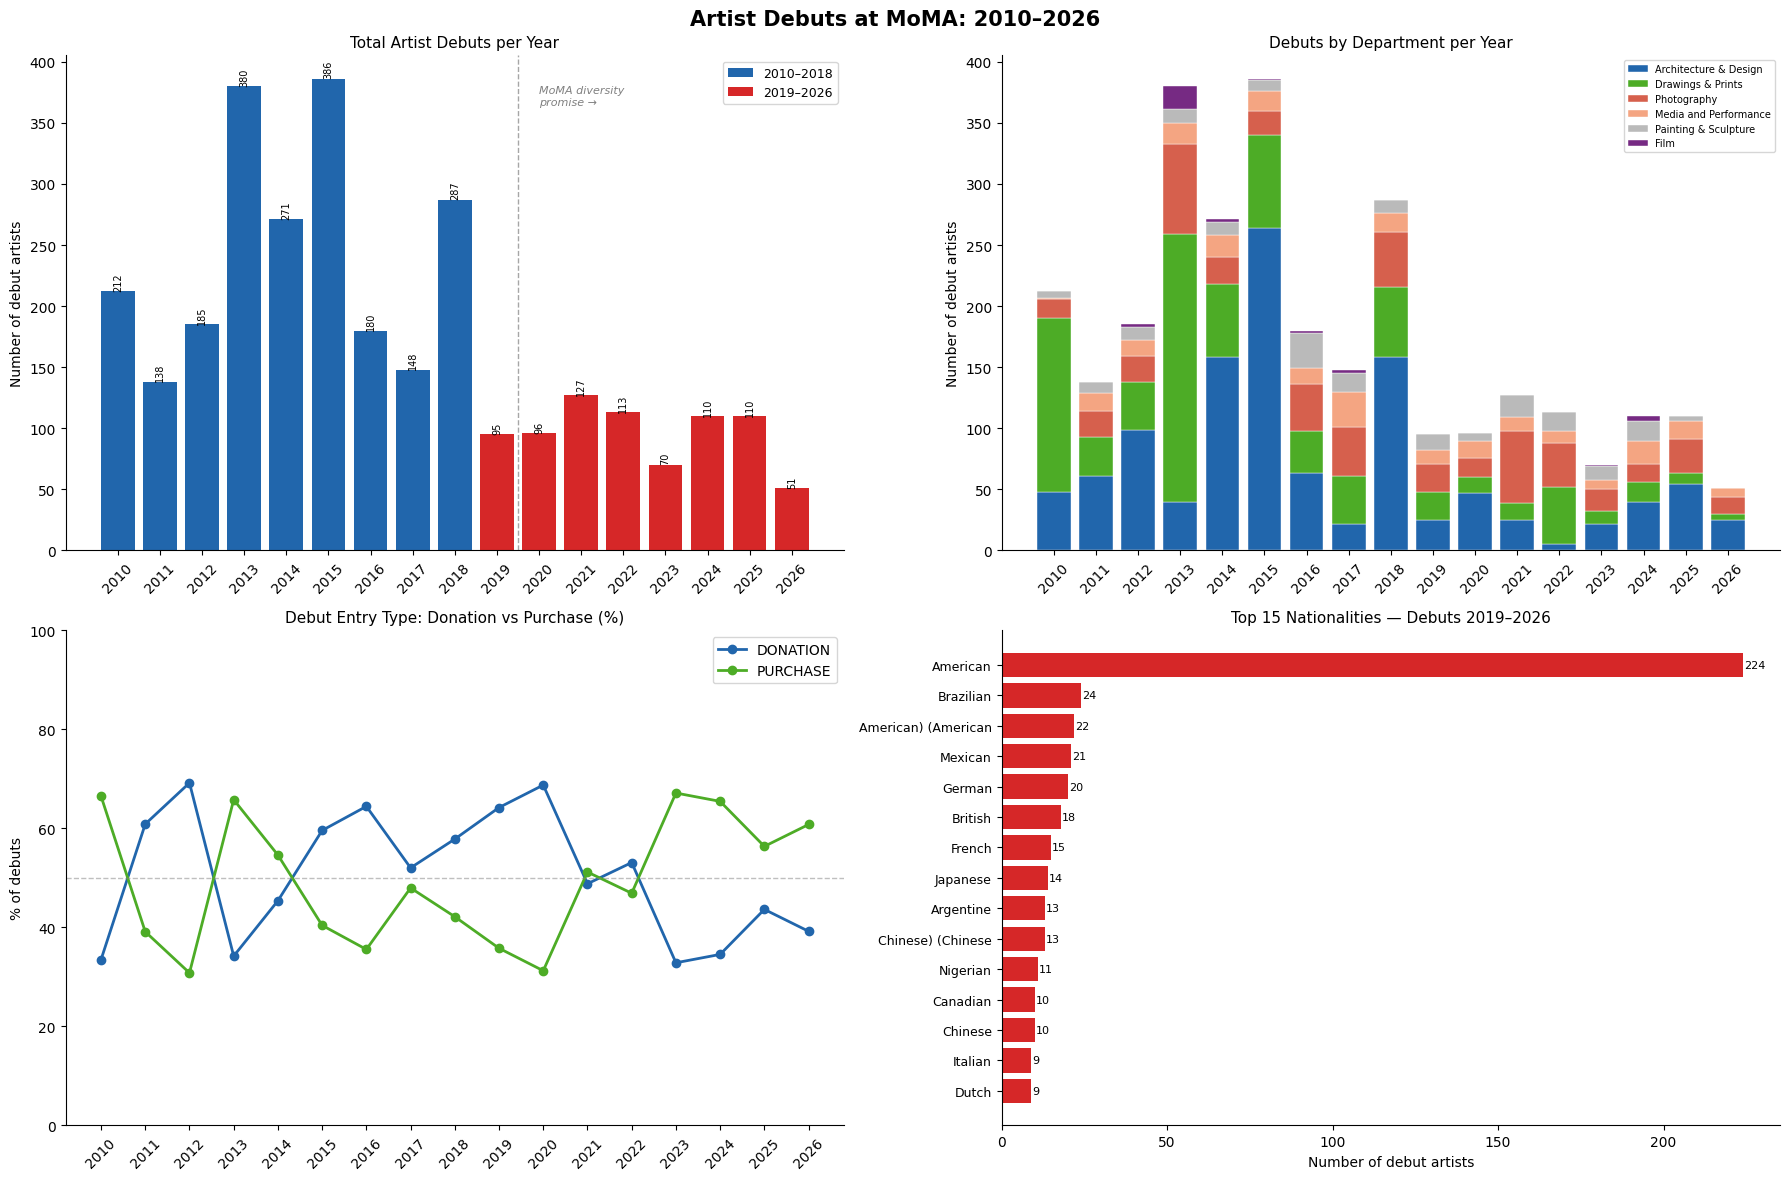

Saved.


In [74]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Artist Debuts at MoMA: 2010–2026', fontsize=15, fontweight='bold')

post2010 = first[first['YearAcquired'] >= 2010].copy()
post2010['YearAcquired'] = post2010['YearAcquired'].astype(int)

# ── Chart 1: Total debuts per year ──
ax1 = axes[0, 0]
by_year = post2010.groupby('YearAcquired').size()
colors = ['#d62728' if y >= 2019 else '#2166ac' for y in by_year.index]
bars = ax1.bar(by_year.index.astype(str), by_year.values, color=colors)
ax1.set_title('Total Artist Debuts per Year', fontsize=11)
ax1.set_ylabel('Number of debut artists')
ax1.tick_params(axis='x', rotation=45)
ax1.axvline(x=9.5, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax1.text(10, ax1.get_ylim()[1]*0.9, 'MoMA diversity\npromise →',
         fontsize=8, color='gray', style='italic')
for bar, val in zip(bars, by_year.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             str(val), ha='center', fontsize=7, rotation=90)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2166ac', label='2010–2018'),
                   Patch(facecolor='#d62728', label='2019–2026')]
ax1.legend(handles=legend_elements, fontsize=9)

# ── Chart 2: Debuts by department per year (stacked) ──
ax2 = axes[0, 1]
dept_year = post2010.groupby(['YearAcquired', 'Department']).size().unstack(fill_value=0)
top_depts = post2010['Department'].value_counts().head(6).index.tolist()
for col in top_depts:
    if col not in dept_year.columns:
        dept_year[col] = 0
dept_year = dept_year[top_depts]

dept_colors = ['#2166ac','#4dac26','#d6604d','#f4a582','#bababa','#762a83']
bottom = [0] * len(dept_year)
for i, dept in enumerate(top_depts):
    ax2.bar(dept_year.index.astype(str), dept_year[dept],
            bottom=bottom, label=dept[:25],
            color=dept_colors[i], edgecolor='white', linewidth=0.3)
    bottom = [b + v for b, v in zip(bottom, dept_year[dept])]

ax2.set_title('Debuts by Department per Year', fontsize=11)
ax2.set_ylabel('Number of debut artists')
ax2.tick_params(axis='x', rotation=45)
ax2.legend(fontsize=7, loc='upper right')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# ── Chart 3: Acquisition type per year ──
ax3 = axes[1, 0]
acq_year = post2010.groupby(['YearAcquired', 'AcquisitionFinal']).size().unstack(fill_value=0)
for col in ['DONATION', 'PURCHASE']:
    if col not in acq_year.columns:
        acq_year[col] = 0

acq_pct = acq_year[['DONATION','PURCHASE']].div(
    acq_year[['DONATION','PURCHASE']].sum(axis=1), axis=0) * 100

ax3.plot(acq_pct.index.astype(str), acq_pct['DONATION'],
         color='#2166ac', marker='o', linewidth=2, label='DONATION')
ax3.plot(acq_pct.index.astype(str), acq_pct['PURCHASE'],
         color='#4dac26', marker='o', linewidth=2, label='PURCHASE')
ax3.axhline(50, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax3.set_title('Debut Entry Type: Donation vs Purchase (%)', fontsize=11)
ax3.set_ylabel('% of debuts')
ax3.set_ylim(0, 100)
ax3.tick_params(axis='x', rotation=45)
ax3.legend()
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# ── Chart 4: Top nationalities of debuts 2019-2026 ──
ax4 = axes[1, 1]
post2019_nat = first[first['YearAcquired'] >= 2019]['NationalityClean'].value_counts()
post2019_nat = post2019_nat[post2019_nat.index != ''].head(15)

bars = ax4.barh(range(len(post2019_nat)), post2019_nat.values, color='#d62728')
ax4.set_yticks(range(len(post2019_nat)))
ax4.set_yticklabels(post2019_nat.index, fontsize=9)
ax4.invert_yaxis()
ax4.set_title('Top 15 Nationalities — Debuts 2019–2026', fontsize=11)
ax4.set_xlabel('Number of debut artists')
for bar, val in zip(bars, post2019_nat.values):
    ax4.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=8)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('data/debuts_2010_2026.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

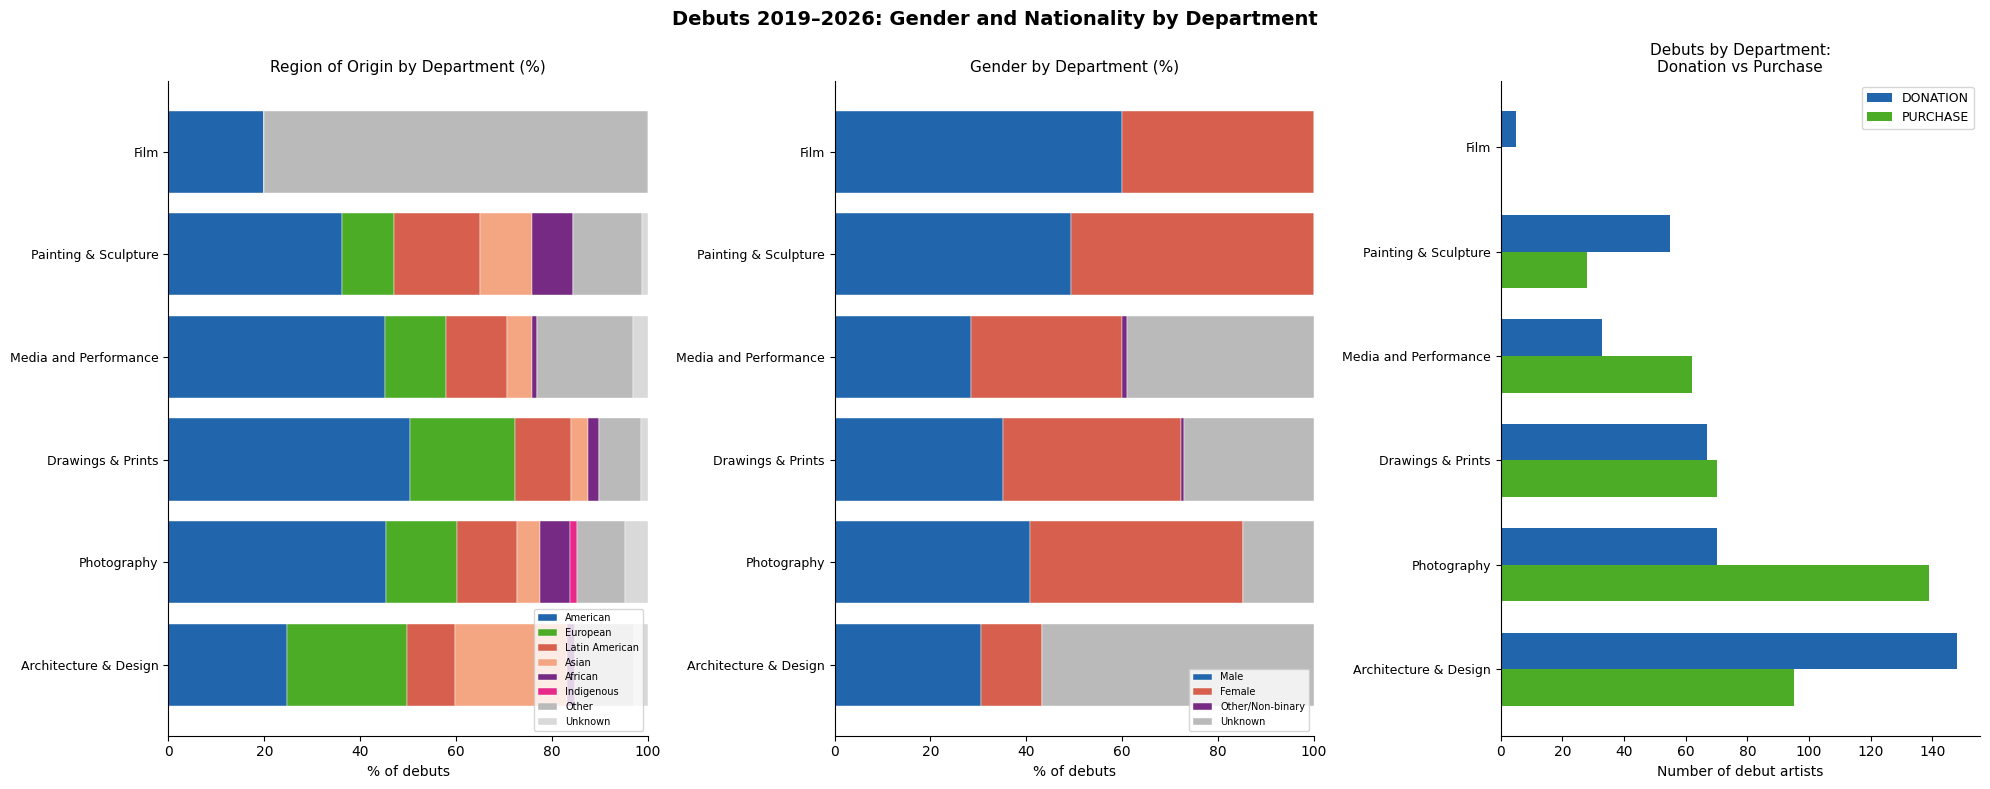

Saved.


In [75]:
fig, axes = plt.subplots(1, 3, figsize=(20, 8))
fig.suptitle('Debuts 2019–2026: Gender and Nationality by Department',
             fontsize=14, fontweight='bold')

post2019 = first[first['YearAcquired'] >= 2019].copy()
top_depts = post2019['Department'].value_counts().head(6).index.tolist()

# ── Chart 1: Nationality by department ──
ax1 = axes[0]
# Group non-American into regions
def classify_region(nat):
    if pd.isna(nat) or nat == '':
        return 'Unknown'
    nat = nat.lower()
    if 'american' in nat and 'latin' not in nat and 'south' not in nat:
        return 'American'
    elif any(x in nat for x in ['british','german','french','dutch','swiss',
                                  'italian','spanish','belgian','swedish',
                                  'norwegian','danish','austrian','polish']):
        return 'European'
    elif any(x in nat for x in ['brazilian','mexican','colombian','argentine',
                                  'peruvian','chilean','venezuelan','cuban']):
        return 'Latin American'
    elif any(x in nat for x in ['chinese','japanese','korean','indian',
                                  'vietnamese','thai','indonesian']):
        return 'Asian'
    elif any(x in nat for x in ['nigerian','ghanaian','kenyan','south african',
                                  'congolese','senegalese','egyptian']):
        return 'African'
    elif any(x in nat for x in ['native american','hmong','kalaaleq']):
        return 'Indigenous'
    else:
        return 'Other'

post2019['Region'] = post2019['NationalityClean'].apply(classify_region)

dept_region = post2019.groupby(['Department','Region']).size().unstack(fill_value=0)
dept_region = dept_region.reindex(top_depts)
dept_region_pct = dept_region.div(dept_region.sum(axis=1), axis=0) * 100

region_colors = {
    'American': '#2166ac',
    'European': '#4dac26',
    'Latin American': '#d6604d',
    'Asian': '#f4a582',
    'African': '#762a83',
    'Indigenous': '#e7298a',
    'Other': '#bababa',
    'Unknown': '#d9d9d9'
}

regions = [r for r in region_colors.keys() if r in dept_region_pct.columns]
bottom = [0] * len(dept_region_pct)
for region in regions:
    if region in dept_region_pct.columns:
        ax1.barh(range(len(dept_region_pct)), dept_region_pct[region],
                left=bottom, label=region,
                color=region_colors[region], edgecolor='white', linewidth=0.3)
        bottom = [b + v for b, v in zip(bottom, dept_region_pct[region])]

ax1.set_yticks(range(len(dept_region_pct)))
ax1.set_yticklabels([d[:25] for d in dept_region_pct.index], fontsize=9)
ax1.set_title('Region of Origin by Department (%)', fontsize=11)
ax1.set_xlabel('% of debuts')
ax1.legend(fontsize=7, loc='lower right')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ── Chart 2: Gender by department ──
ax2 = axes[1]
dept_gender = post2019.groupby(['Department','GenderSimple']).size().unstack(fill_value=0)
dept_gender = dept_gender.reindex(top_depts)
dept_gender_pct = dept_gender.div(dept_gender.sum(axis=1), axis=0) * 100

gender_colors = {
    'Male': '#2166ac',
    'Female': '#d6604d',
    'Other/Non-binary': '#762a83',
    'Unknown': '#bababa'
}

genders = [g for g in gender_colors.keys() if g in dept_gender_pct.columns]
bottom = [0] * len(dept_gender_pct)
for gender in genders:
    if gender in dept_gender_pct.columns:
        ax2.barh(range(len(dept_gender_pct)), dept_gender_pct[gender],
                left=bottom, label=gender,
                color=gender_colors[gender], edgecolor='white', linewidth=0.3)
        bottom = [b + v for b, v in zip(bottom, dept_gender_pct[gender])]

ax2.set_yticks(range(len(dept_gender_pct)))
ax2.set_yticklabels([d[:25] for d in dept_gender_pct.index], fontsize=9)
ax2.set_title('Gender by Department (%)', fontsize=11)
ax2.set_xlabel('% of debuts')
ax2.legend(fontsize=7, loc='lower right')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# ── Chart 3: Total debuts by department + acquisition type ──
ax3 = axes[2]
dept_acq = post2019.groupby(['Department','AcquisitionFinal']).size().unstack(fill_value=0)
dept_acq = dept_acq.reindex(top_depts)
for col in ['DONATION','PURCHASE']:
    if col not in dept_acq.columns:
        dept_acq[col] = 0

width = 0.35
x = range(len(dept_acq))
ax3.barh([i + width/2 for i in x], dept_acq['DONATION'],
         height=width, color='#2166ac', label='DONATION')
ax3.barh([i - width/2 for i in x], dept_acq['PURCHASE'],
         height=width, color='#4dac26', label='PURCHASE')
ax3.set_yticks(x)
ax3.set_yticklabels([d[:25] for d in dept_acq.index], fontsize=9)
ax3.set_title('Debuts by Department:\nDonation vs Purchase', fontsize=11)
ax3.set_xlabel('Number of debut artists')
ax3.legend(fontsize=9)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('data/debuts_dept_gender_nationality.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [73]:
# Painting & Sculpture debuts post-2019 — who gets in?
print("=== PAINTING & SCULPTURE DEBUTS 2019-2026 ===")
ps_debuts = post2019[post2019['Department'] == 'Painting & Sculpture']

print(f"Total: {len(ps_debuts)}")
print(f"\nBy acquisition type:")
print(ps_debuts['AcquisitionFinal'].value_counts())

print(f"\nBy nationality:")
print(ps_debuts['NationalityClean'].value_counts().head(15))

print(f"\nTop CreditLines:")
print(ps_debuts['CreditLine'].value_counts().head(10).to_string())

print(f"\nArtist list:")
print(ps_debuts[['Artist','NationalityClean','YearAcquired',
                 'AcquisitionFinal','CreditLine']]\
      .sort_values('YearAcquired').to_string())

=== PAINTING & SCULPTURE DEBUTS 2019-2026 ===
Total: 83

By acquisition type:
AcquisitionFinal
DONATION    55
PURCHASE    28
Name: count, dtype: int64

By nationality:
NationalityClean
American      30
Brazilian      6
Argentine      3
Korean         3
French         2
Venezuelan     2
Japanese       2
Congolese      2
Lebanese       2
Belgian        2
German         2
Egyptian       2
Colombian      2
Nigerian       2
Thai           2
Name: count, dtype: int64

Top CreditLines:
CreditLine
Fund for the Twenty-First Century                                 7
Latin American and Caribbean Fund                                 5
Gift of Joan H. Tisch (by exchange)                               3
The Jean Pigozzi African Art Collection.  Gift of Jean Pigozzi    3
Anonymous gift                                                    2
Gift of Steven and Alexandra Cohen                                2
Fund for the Twenty-First Century\r\n                             2
Committee on Painting and Scu

In [86]:
# Who are the recurring donors in P&S debuts 2019-2026?
# And how many artists does each bring?
print("=== RECURRING DONORS IN P&S DEBUTS 2019-2026 ===\n")

# Extract individual donor names from CreditLine
import re

def extract_donors(text):
    if pd.isna(text):
        return []
    # Remove common prefixes
    text = re.sub(r'Gift of |Acquired through the generosity of |Bequest of |Purchase of ', '', text)
    text = re.sub(r' in honor of .*', '', text)
    text = re.sub(r' in memory of .*', '', text)
    text = re.sub(r'\(by exchange\)', '', text)
    # Split by common separators
    donors = re.split(r',\s*and\s*|\s*and\s*|;\s*', text)
    return [d.strip() for d in donors if len(d.strip()) > 3]

ps_debuts['Donors'] = ps_debuts['CreditLine'].apply(extract_donors)

# Count artist debuts per donor
donor_artist_count = {}
for _, row in ps_debuts.iterrows():
    for donor in row['Donors']:
        if donor not in donor_artist_count:
            donor_artist_count[donor] = []
        donor_artist_count[donor].append(row['Artist'])

# Sort by count
donor_artist_count = {k: v for k, v in 
                      sorted(donor_artist_count.items(), 
                             key=lambda x: len(x[1]), reverse=True)}

print(f"{'Donor':<50} {'Artists':>8}")
print("-" * 70)
for donor, artists in list(donor_artist_count.items())[:20]:
    print(f"{donor[:50]:<50} {len(artists):>8}")
    for artist in artists:
        print(f"  → {artist}")

=== RECURRING DONORS IN P&S DEBUTS 2019-2026 ===

Donor                                               Artists
----------------------------------------------------------------------
Fund for the Twenty-First Century                         9
  → Guadalupe Maravilla
  → Marwan Rechmaoui
  → Christine Sun Kim
  → Jana Euler
  → Diamond Stingily
  → Zak Prekop
  → Cui Jie
  → Anne Imhof
  → Suki Seokyeong Kang
Caribbean Fund                                            8
  → Yente (Eugenia Crenovich)
  → Sigfredo Chacón
  → Dalton Paula
  → Fernanda Gomes
  → Joey Terrill
  → Carolina Caycedo
  → Analia Saban
  → Tomie Ohtake
Latin American                                            5
  → Yente (Eugenia Crenovich)
  → Sigfredo Chacón
  → Fernanda Gomes
  → Analia Saban
  → Tomie Ohtake
Anonymous gift                                            5
  → Helen Marden
  → Joey Terrill
  → Y.Z. Kami
  → Vivan Sundaram
  → Bertina Lopes
Committee on Painting                                     4
  → 

In [88]:
def classify_region(nat):
    if pd.isna(nat) or nat.strip() == '':
        return 'Unknown'
    nat = nat.lower()
    if 'american' in nat and not any(x in nat for x in ['latin','south','central']):
        return 'American'
    elif any(x in nat for x in ['brazilian','mexican','colombian','argentine',
                                  'peruvian','chilean','venezuelan','cuban',
                                  'salvadoran','uruguayan','bolivian']):
        return 'Latin American'
    elif any(x in nat for x in ['nigerian','ghanaian','kenyan','south african',
                                  'congolese','senegalese','egyptian','malian',
                                  'beninese','ivorian','cameroonian']):
        return 'African'
    elif any(x in nat for x in ['chinese','japanese','korean','indian',
                                  'vietnamese','thai','indonesian','iranian',
                                  'turkish','pakistani','iraqi','syrian',
                                  'lebanese','israeli']):
        return 'Asian / Middle Eastern'
    elif any(x in nat for x in ['british','german','french','dutch','swiss',
                                  'italian','spanish','belgian','swedish',
                                  'norwegian','danish','austrian','polish',
                                  'czech','croatian']):
        return 'European'
    else:
        return 'Other'

ps_debuts['Region'] = ps_debuts['NationalityClean'].apply(classify_region)
print(ps_debuts['Region'].value_counts())

Region
American                  30
Latin American            16
Asian / Middle Eastern    14
European                  10
African                    9
Other                      3
Unknown                    1
Name: count, dtype: int64


In [100]:
print("=== TOTAL IMPACT: FUNDS vs DONORS in P&S Debuts 2019-2026 ===\n")

total_debuts = len(ps_debuts_all)

# Funds — PURCHASE
funds_total = len(ps_debuts_all[ps_debuts_all['AcquisitionFinal'] == 'PURCHASE'])

# Donors — DONATION
donors_total = len(ps_debuts_all[ps_debuts_all['AcquisitionFinal'] == 'DONATION'])

print(f"Total P&S debuts 2019-2026:     {total_debuts}")
print(f"\nIntroduced via FUNDS (purchase): {funds_total} ({funds_total/total_debuts*100:.1f}%)")
print(f"Introduced via DONORS (donation): {donors_total} ({donors_total/total_debuts*100:.1f}%)")

print(f"\n--- FUNDS BREAKDOWN ---")
for fund, artists in fund_artist_map.items():
    print(f"  {fund[:60]}: {len(artists)}")

print(f"\n--- DONORS BREAKDOWN ---")
for donor, artists in merged_donors.items():
    print(f"  {donor}: {len(artists)}")

=== TOTAL IMPACT: FUNDS vs DONORS in P&S Debuts 2019-2026 ===

Total P&S debuts 2019-2026:     83

Introduced via FUNDS (purchase): 28 (33.7%)
Introduced via DONORS (donation): 55 (66.3%)

--- FUNDS BREAKDOWN ---
  Fund for the Twenty-First Century: 9
  Latin American and Caribbean Fund: 5
  Committee on Painting and Sculpture Funds: 2
  Painting and Sculpture Deaccession Funds: 2
  Enid A. Haupt Fund: 2
  Acquired through the generosity of The Modern Women’s Fund, : 1
  Blanchette Hooker Rockefeller Fund (by exchange): 1
  The Jill and Peter Kraus Endowed Fund for Contemporary Acqui: 1
  The William S. Paley Acquisition Fund: 1
  Pat Hearn and Colin de Land Acquisition Fund: 1
  The Philip L. Goodwin Collection (by exchange) and Maya Alma: 1
  Purchase: 1
  Pat Hearn and Colin de Land Acquisition Fund and Goldberg Co: 1

--- DONORS BREAKDOWN ---
  Pamela J. Joyner &
Alfred J. Giuffrida: 5
  James Keith Brown &
Eric Diefenbach: 4
  Joan H. Tisch: 3
  Jean Pigozzi: 3
  Sandra &
Tony Tam

In [76]:
# Who are the recurring donors in Painting & Sculpture debuts?
ps_debuts = first[
    (first['YearAcquired'] >= 2019) & 
    (first['Department'] == 'Painting & Sculpture')
]

print("=== RECURRING DONORS IN P&S DEBUTS 2019-2026 ===")
print(ps_debuts['CreditLine'].value_counts().head(20).to_string())

# How many unique donors brought how many artists?
print(f"\nUnique CreditLines: {ps_debuts['CreditLine'].nunique()}")
print(f"Total debuts: {len(ps_debuts)}")

=== RECURRING DONORS IN P&S DEBUTS 2019-2026 ===
CreditLine
Fund for the Twenty-First Century                                                                                               7
Latin American and Caribbean Fund                                                                                               5
Gift of Joan H. Tisch (by exchange)                                                                                             3
The Jean Pigozzi African Art Collection.  Gift of Jean Pigozzi                                                                  3
Anonymous gift                                                                                                                  2
Gift of Steven and Alexandra Cohen                                                                                              2
Fund for the Twenty-First Century\r\n                                                                                           2
Committee on Painting and Scul

In [92]:
total_ps = len(ps_debuts_all)
total_visible = sum(v['count'] for v in curators_visible.values())
total_invisible = total_ps - total_visible

print(f"Total P&S debuts: {total_ps}")
print(f"With curator mentioned: {total_visible}")
print(f"Without curator mentioned: {total_invisible} ({total_invisible/total_ps*100:.0f}%)")

Total P&S debuts: 83
With curator mentioned: 13
Without curator mentioned: 70 (84%)


In [94]:
print("=== DONORS ===")
donors_df = ps_debuts_all[ps_debuts_all['AcquisitionFinal'] == 'DONATION']
print(f"Total: {len(donors_df)}")
print(donors_df[['Artist', 'NationalityClean', 'YearAcquired', 'CreditLine']]\
      .sort_values('YearAcquired').to_string())

print("\n=== FUNDS ===")
funds_df = ps_debuts_all[ps_debuts_all['AcquisitionFinal'] == 'PURCHASE']
print(f"Total: {len(funds_df)}")
print(funds_df[['Artist', 'NationalityClean', 'YearAcquired', 'CreditLine']]\
      .sort_values('YearAcquired').to_string())

=== DONORS ===
Total: 55
                           Artist        NationalityClean  YearAcquired                                                                                                                      CreditLine
83429             Suzanne Duchamp                  French        2019.0                                                                                             Gift of Joan H. Tisch (by exchange)
135954           Tsuruko Yamazaki                Japanese        2019.0    Gift of Marlene Hess and James D. Zirin, Committee on Painting and Sculpture funds, and bequest of the Joan G. Toepfer Trust
135956                 Mary Kelly                American        2019.0                                                                                           Gift of Sam A. Lewisohn (by exchange)
135979                 Mary Corse                American        2019.0                                                            Committee on Painting and Sculpture Funds an

In [95]:
# Extract donors from CreditLine — let the data speak
donors_df = ps_debuts_all[ps_debuts_all['AcquisitionFinal'] == 'DONATION'].copy()

# Count unique donor mentions from raw CreditLine
donor_artist_map = {}

for _, row in donors_df.iterrows():
    credit = row['CreditLine']
    artist = row['Artist']
    nationality = row['NationalityClean']
    year = int(row['YearAcquired'])
    
    if pd.isna(credit):
        continue
    
    # Clean common suffixes
    credit_clean = credit.replace('\r\n', '').replace('\n', '')
    
    # Extract donor — text after "Gift of" or "Bequest of"
    import re
    
    # Remove exchange notes
    credit_clean = re.sub(r'\s*\(by exchange\)', '', credit_clean)
    credit_clean = re.sub(r'\s*\(all by exchange\)', '', credit_clean)
    
    # Remove "in honor of" and everything after
    credit_clean = re.sub(r',?\s*in honor of.*', '', credit_clean)
    credit_clean = re.sub(r',?\s*in memory of.*', '', credit_clean)
    credit_clean = re.sub(r',?\s*through the.*', '', credit_clean)
    credit_clean = re.sub(r',?\s*and bequest.*', '', credit_clean)
    
    # Extract after "Gift of" or "Bequest of"
    match = re.search(r'(?:Gift|Bequest|Promised gift) of (.+)', credit_clean, re.IGNORECASE)
    if match:
        donor_raw = match.group(1).strip()
        
        # Split multiple donors by " and " or ","
        donors_list = re.split(r',\s*and\s*|,\s*(?=[A-Z])', donor_raw)
        
        for donor in donors_list:
            donor = donor.strip().rstrip(',').strip()
            if len(donor) < 3:
                continue
            if donor not in donor_artist_map:
                donor_artist_map[donor] = []
            donor_artist_map[donor].append({
                'artist': artist,
                'nationality': nationality,
                'year': year
            })

# Sort by count
donor_artist_map = dict(sorted(donor_artist_map.items(),
                               key=lambda x: len(x[1]), reverse=True))

print("=== DONORS: ARTISTS INTRODUCED IN P&S 2019-2026 ===\n")
print(f"{'Donor':<50} {'Count':>6}")
print("-" * 60)
for donor, artists in donor_artist_map.items():
    print(f"{donor[:50]:<50} {len(artists):>6}")
    for a in artists:
        print(f"  → {a['artist']} ({a['nationality']}, {a['year']})")

=== DONORS: ARTISTS INTRODUCED IN P&S 2019-2026 ===

Donor                                               Count
------------------------------------------------------------
James Keith Brown and Eric Diefenbach                   4
  → Ivan Kožarić (Croatian, 2019)
  → Germán Cueto (Mexican, 2021)
  → Kahlil Robert Irving (American, 2022)
  → Randy Williams (American, 2023)
Joan H. Tisch                                           3
  → Suzanne Duchamp (French, 2019)
  → Agnes Pelton (American, 2023)
  → Emily Kam Kngwarray (Anmatyerr [Australian], 2025)
Jean Pigozzi                                            3
  → Romuald Hazoumè (Beninese, 2019)
  → Moké (Congolese, 2019)
  → Bodys Isek Kingelez (Congolese, 2019)
Sandra and Tony Tamer                                   3
  → Huguette Caland (Lebanese, 2021)
  → Abdias Nascimento (Brazilian, 2021)
  → Miyoko Ito (American, 2024)
Pamela J. Joyner and Alfred J. Giuffrida                3
  → Abdias Nascimento (Brazilian, 2021)
  → Janet Oliv

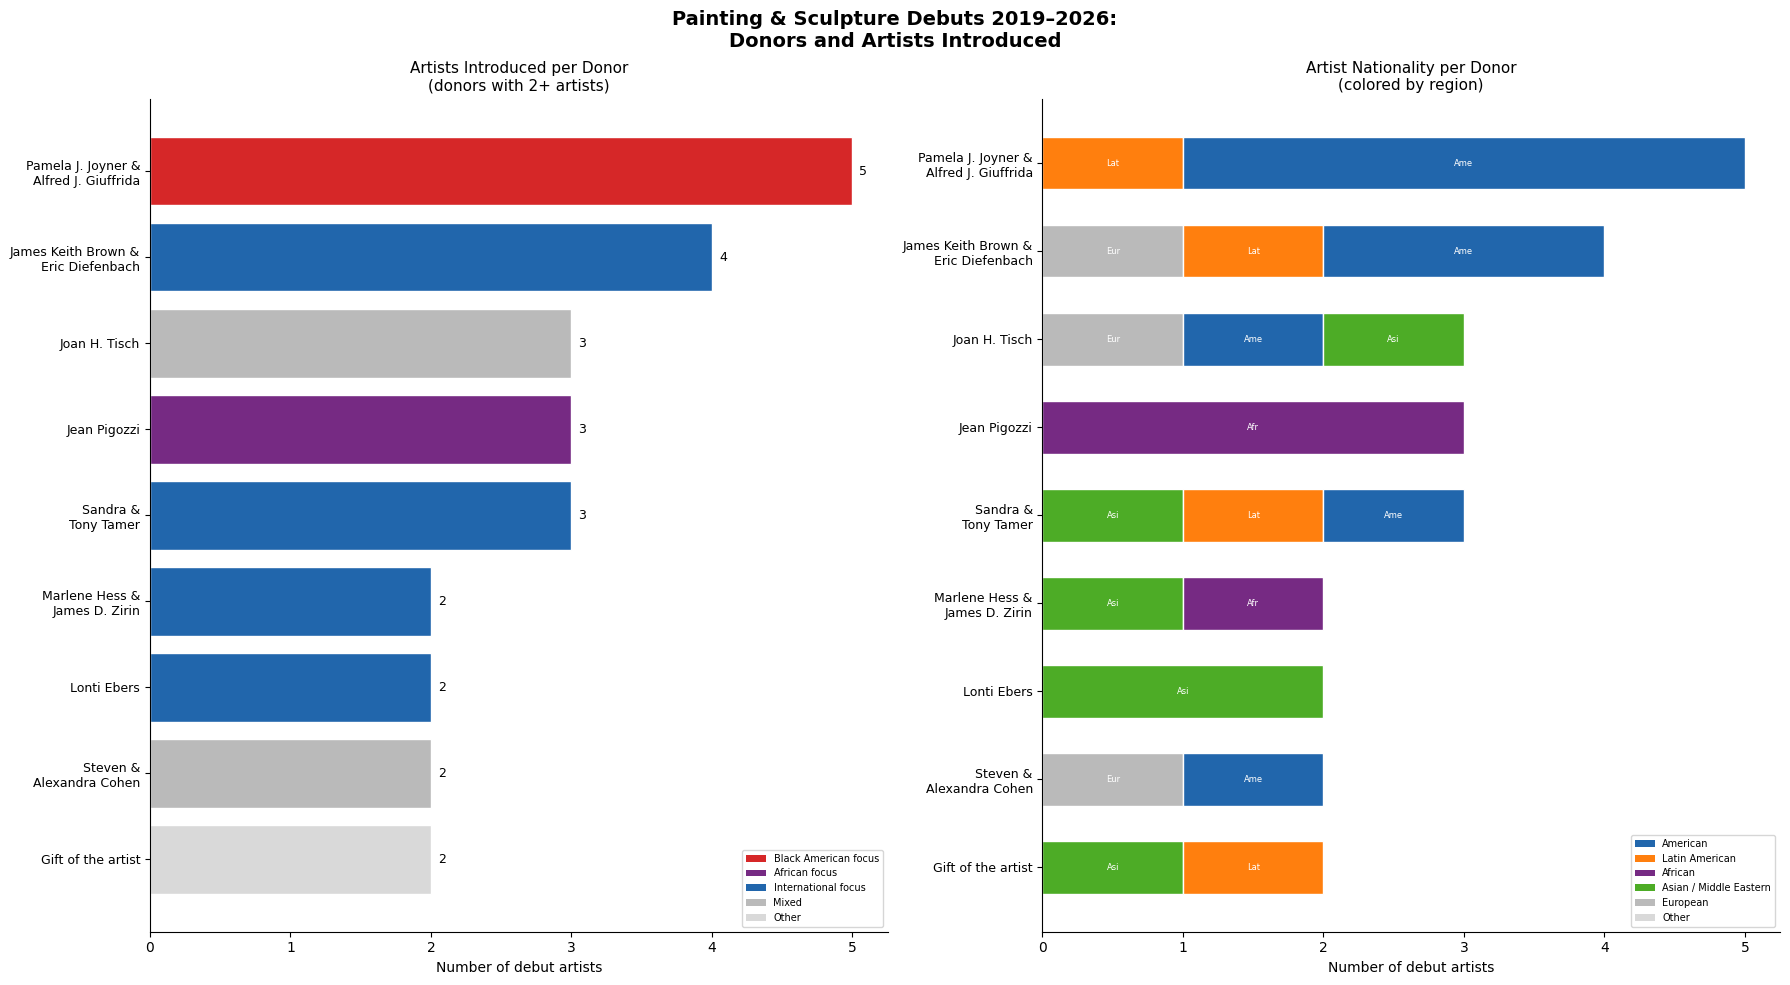

Saved.


In [96]:
fig, axes = plt.subplots(1, 2, figsize=(18, 10))
fig.suptitle('Painting & Sculpture Debuts 2019–2026:\nDonors and Artists Introduced',
             fontsize=14, fontweight='bold')

# Keep only donors with 2+ artists for clarity
top_donors = {k: v for k, v in donor_artist_map.items() if len(v) >= 2}

# Merge Joyner/Giuffrida entries
merged_donors = {}
for donor, artists in top_donors.items():
    if 'Joyner' in donor or 'Giuffrida' in donor:
        key = 'Pamela J. Joyner &\nAlfred J. Giuffrida'
    elif 'the artist' in donor:
        key = 'Gift of the artist'
    else:
        key = donor.replace(' and ', ' &\n', 1)
    if key not in merged_donors:
        merged_donors[key] = []
    merged_donors[key].extend(artists)

# Remove duplicates
for key in merged_donors:
    seen = set()
    unique = []
    for a in merged_donors[key]:
        if a['artist'] not in seen:
            seen.add(a['artist'])
            unique.append(a)
    merged_donors[key] = unique

merged_donors = dict(sorted(merged_donors.items(),
                            key=lambda x: len(x[1]), reverse=True))

donor_names = list(merged_donors.keys())
donor_counts = [len(v) for v in merged_donors.values()]

# Color by thematic focus
def donor_focus_color(name):
    name = name.lower()
    if 'joyner' in name or 'giuffrida' in name:
        return '#d62728'  # Black American focus
    elif 'pigozzi' in name:
        return '#762a83'  # African focus
    elif 'tisch' in name:
        return '#bababa'  # Mixed
    elif 'tamer' in name:
        return '#2166ac'  # International
    elif 'brown' in name or 'diefenbach' in name:
        return '#2166ac'  # International
    elif 'cohen' in name:
        return '#bababa'  # Mixed
    elif 'hess' in name:
        return '#2166ac'  # International
    elif 'ebers' in name:
        return '#2166ac'  # International
    else:
        return '#d9d9d9'

colors = [donor_focus_color(n) for n in donor_names]

# ── Chart 1: Donors by number of artists ──
ax1 = axes[0]
bars = ax1.barh(range(len(donor_names)), donor_counts,
                color=colors, edgecolor='white')
ax1.set_yticks(range(len(donor_names)))
ax1.set_yticklabels(donor_names, fontsize=9)
ax1.invert_yaxis()
ax1.set_title('Artists Introduced per Donor\n(donors with 2+ artists)', fontsize=11)
ax1.set_xlabel('Number of debut artists')

for bar, val in zip(bars, donor_counts):
    ax1.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=9)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#d62728', label='Black American focus'),
    Patch(facecolor='#762a83', label='African focus'),
    Patch(facecolor='#2166ac', label='International focus'),
    Patch(facecolor='#bababa', label='Mixed'),
    Patch(facecolor='#d9d9d9', label='Other'),
]
ax1.legend(handles=legend_elements, fontsize=7, loc='lower right')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ── Chart 2: Artists per donor with nationality ──
ax2 = axes[1]

region_colors = {
    'American':              '#2166ac',
    'Latin American':        '#ff7f0e',
    'African':               '#762a83',
    'Asian / Middle Eastern':'#4dac26',
    'European':              '#bababa',
    'Other':                 '#d9d9d9',
}

def get_region(nat):
    if pd.isna(nat) or nat.strip() == '':
        return 'Other'
    nat = nat.lower()
    if 'american' in nat and not any(x in nat for x in ['latin','south','central','brazilian',
                                                          'mexican','colombian','argentine']):
        return 'American'
    elif any(x in nat for x in ['brazilian','mexican','colombian','argentine','peruvian',
                                  'chilean','venezuelan','cuban','salvadoran','ivatan']):
        return 'Latin American'
    elif any(x in nat for x in ['nigerian','congolese','beninese','kenyan','malian',
                                  'ghanaian','egyptian','south african']):
        return 'African'
    elif any(x in nat for x in ['japanese','korean','chinese','thai','indian','iraqi',
                                  'lebanese','israeli','syrian','vietnamese','anmatyerr']):
        return 'Asian / Middle Eastern'
    elif any(x in nat for x in ['french','german','british','belgian','croatian','swedish',
                                  'italian','dutch','swiss','austrian','polish']):
        return 'European'
    return 'Other'

# Build stacked bar by region per donor
y_pos = 0
yticks = []
ytick_labels = []

for donor, artists in merged_donors.items():
    region_counts = {}
    for a in artists:
        region = get_region(a['nationality'])
        region_counts[region] = region_counts.get(region, 0) + 1

    left = 0
    for region, count in region_counts.items():
        ax2.barh(y_pos, count, left=left,
                 color=region_colors.get(region, '#d9d9d9'),
                 edgecolor='white', height=0.6)
        if count >= 1:
            ax2.text(left + count/2, y_pos, region[:3],
                     ha='center', va='center', fontsize=6, color='white')
        left += count

    yticks.append(y_pos)
    ytick_labels.append(donor)
    y_pos += 1

ax2.set_yticks(yticks)
ax2.set_yticklabels(ytick_labels, fontsize=9)
ax2.invert_yaxis()
ax2.set_title('Artist Nationality per Donor\n(colored by region)', fontsize=11)
ax2.set_xlabel('Number of debut artists')

legend_elements2 = [Patch(facecolor=v, label=k) for k, v in region_colors.items()]
ax2.legend(handles=legend_elements2, fontsize=7, loc='lower right')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('data/ps_donors_detail.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [97]:
print("=== NATIONALITY OF EACH DONOR (P&S Debuts 2019-2026) ===\n")

for donor, artists in merged_donors.items():
    print(f"{donor}:")
    for a in artists:
        print(f"  → {a['artist']} | {a['nationality']} | {a['year']}")
    print()

=== NATIONALITY OF EACH DONOR (P&S Debuts 2019-2026) ===

Pamela J. Joyner &
Alfred J. Giuffrida:
  → Abdias Nascimento | Brazilian | 2021
  → Janet Olivia Henry | American | 2023
  → Ficre Ghebreyesus | American | 2024
  → Leonardo Drew | American | 2021
  → Jordan Casteel | American | 2021

James Keith Brown &
Eric Diefenbach:
  → Ivan Kožarić | Croatian | 2019
  → Germán Cueto | Mexican | 2021
  → Kahlil Robert Irving | American | 2022
  → Randy Williams | American | 2023

Joan H. Tisch:
  → Suzanne Duchamp | French | 2019
  → Agnes Pelton | American | 2023
  → Emily Kam Kngwarray | Anmatyerr [Australian] | 2025

Jean Pigozzi:
  → Romuald Hazoumè | Beninese | 2019
  → Moké | Congolese | 2019
  → Bodys Isek Kingelez | Congolese | 2019

Sandra &
Tony Tamer:
  → Huguette Caland | Lebanese | 2021
  → Abdias Nascimento | Brazilian | 2021
  → Miyoko Ito | American | 2024

Marlene Hess &
James D. Zirin:
  → Tsuruko Yamazaki | Japanese | 2019
  → Gazbia Sirry | Egyptian | 2021

Lonti Ebers:

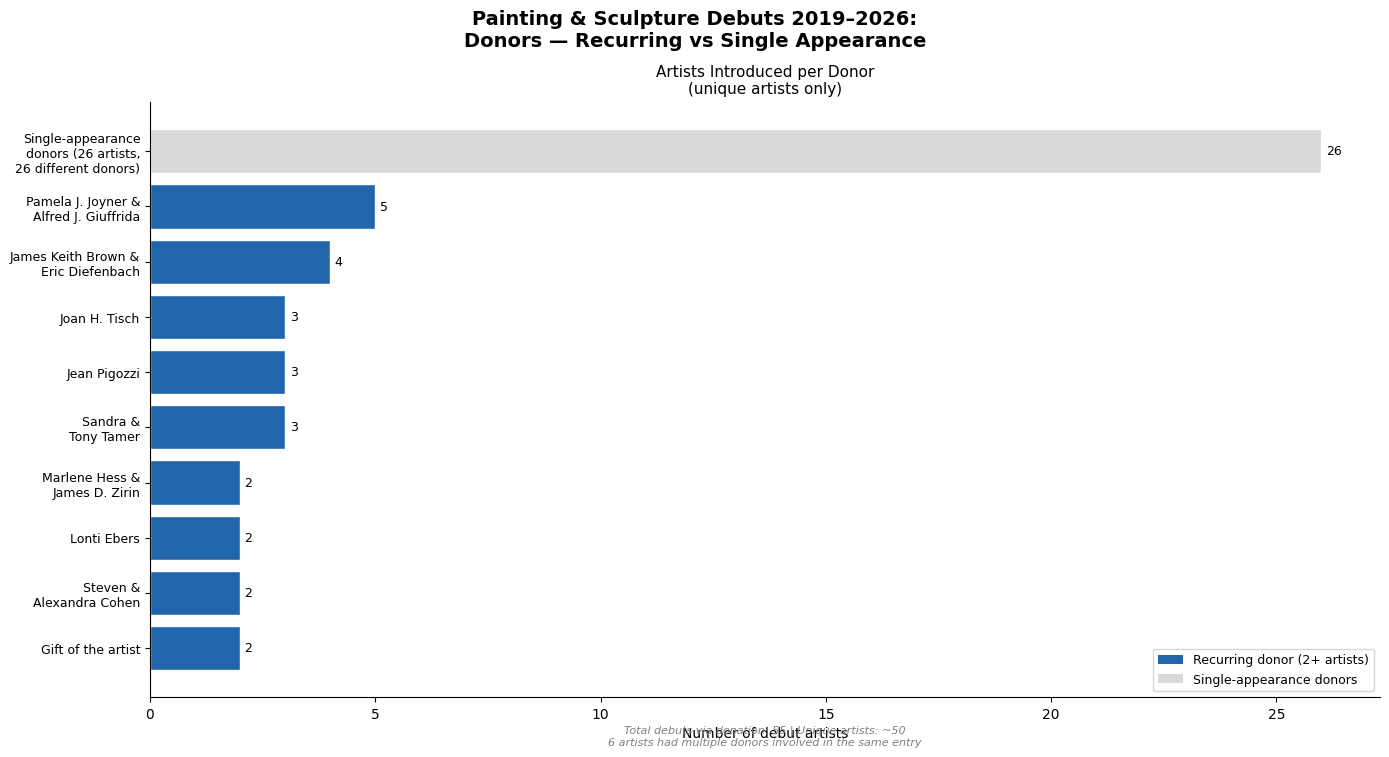

Saved.


In [103]:
fig, ax = plt.subplots(figsize=(14, 8))
fig.suptitle('Painting & Sculpture Debuts 2019–2026:\nDonors — Recurring vs Single Appearance',
             fontsize=14, fontweight='bold')

# Build chart data
chart_data = []

# Recurring donors (2+ artists)
for donor, artists in merged_donors.items():
    unique_artists = list({a['artist']: a for a in artists}.values())
    chart_data.append({
        'name': donor,
        'count': len(unique_artists),
        'artists': unique_artists,
        'type': 'Recurring donor'
    })

# Single donors — group as one bar per artist
single_unique = [a for a in 
                 [{'artist': a['artist'], 'nationality': a['nationality'], 'year': a['year']} 
                  for artists in single_donors.values() for a in artists]
                 if a['artist'] not in multi_artists]

# Deduplicate
seen = set()
single_unique_dedup = []
for a in single_unique:
    if a['artist'] not in seen:
        seen.add(a['artist'])
        single_unique_dedup.append(a)

chart_data.append({
    'name': 'Single-appearance\ndonors (26 artists,\n26 different donors)',
    'count': len(single_unique_dedup),
    'artists': single_unique_dedup,
    'type': 'Single donor'
})

chart_data = sorted(chart_data, key=lambda x: x['count'], reverse=True)

type_colors = {
    'Recurring donor': '#2166ac',
    'Single donor':    '#d9d9d9'
}

names = [d['name'] for d in chart_data]
counts = [d['count'] for d in chart_data]
colors = [type_colors[d['type']] for d in chart_data]

bars = ax.barh(range(len(names)), counts, color=colors, edgecolor='white')
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=9)
ax.invert_yaxis()
ax.set_title('Artists Introduced per Donor\n(unique artists only)', fontsize=11)
ax.set_xlabel('Number of debut artists')

for bar, val, d in zip(bars, counts, chart_data):
    label = str(val)
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            label, va='center', fontsize=9)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2166ac', label='Recurring donor (2+ artists)'),
    Patch(facecolor='#d9d9d9', label='Single-appearance donors'),
]
ax.legend(handles=legend_elements, fontsize=9)

ax.text(0.5, -0.08,
        f'Total debuts via donation: 55 | Unique artists: ~50\n'
        f'6 artists had multiple donors involved in the same entry',
        transform=ax.transAxes, ha='center', fontsize=8,
        style='italic', color='gray')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.subplots_adjust(bottom=0.12)
plt.savefig('data/ps_donors_corrected.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [98]:
# Extract funds from CreditLine — purchase only
funds_df = ps_debuts_all[ps_debuts_all['AcquisitionFinal'] == 'PURCHASE'].copy()

print("=== FUNDS: ARTISTS INTRODUCED IN P&S 2019-2026 ===\n")
print(f"Total via funds: {len(funds_df)}\n")

print(f"{'Fund':<55} {'Count':>6}")
print("-" * 65)

fund_artist_map = {}
for _, row in funds_df.iterrows():
    credit = str(row['CreditLine']).replace('\r\n','').replace('\n','').strip()
    artist = row['Artist']
    nationality = row['NationalityClean']
    year = int(row['YearAcquired'])
    
    if credit not in fund_artist_map:
        fund_artist_map[credit] = []
    fund_artist_map[credit].append({
        'artist': artist,
        'nationality': nationality,
        'year': year
    })

fund_artist_map = dict(sorted(fund_artist_map.items(),
                              key=lambda x: len(x[1]), reverse=True))

for fund, artists in fund_artist_map.items():
    print(f"\n{fund[:70]}")
    print(f"  Count: {len(artists)}")
    for a in artists:
        print(f"  → {a['artist']} ({a['nationality']}, {a['year']})")

=== FUNDS: ARTISTS INTRODUCED IN P&S 2019-2026 ===

Total via funds: 28

Fund                                                     Count
-----------------------------------------------------------------

Fund for the Twenty-First Century
  Count: 9
  → Guadalupe Maravilla (Salvadoran, 2019)
  → Marwan Rechmaoui (Lebanese, 2020)
  → Christine Sun Kim (American, 2021)
  → Jana Euler (German, 2021)
  → Diamond Stingily (American, 2021)
  → Zak Prekop (American, 2021)
  → Cui Jie (Chinese, 2021)
  → Anne Imhof (German, 2023)
  → Suki Seokyeong Kang (Korean, 2024)

Latin American and Caribbean Fund
  Count: 5
  → Yente (Eugenia Crenovich) (Argentine, 2019)
  → Sigfredo Chacón (Venezuelan, 2019)
  → Fernanda Gomes (Brazilian, 2021)
  → Analia Saban (Argentine, 2022)
  → Tomie Ohtake (Brazilian, 2024)

Committee on Painting and Sculpture Funds
  Count: 2
  → Abdoulaye Konaté (Malian, 2022)
  → Wanda Pimentel (Brazilian, 2024)

Painting and Sculpture Deaccession Funds
  Count: 2
  → Nike Davies

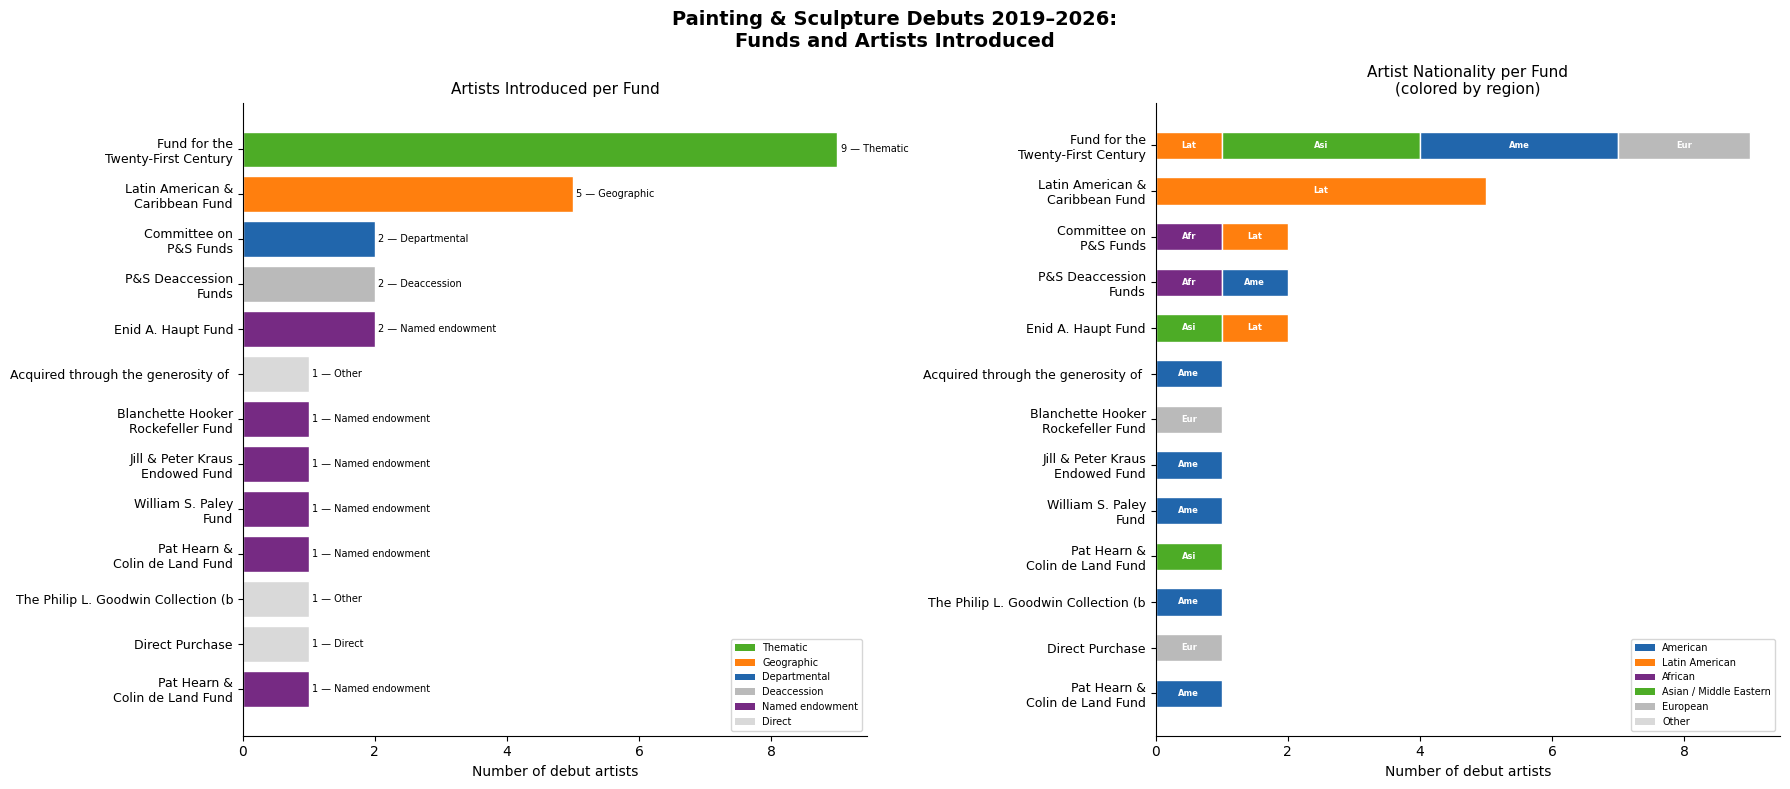

Saved.


In [99]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Painting & Sculpture Debuts 2019–2026:\nFunds and Artists Introduced',
             fontsize=14, fontweight='bold')

# Clean fund names for display
fund_display = {
    'Fund for the Twenty-First Century':                        'Fund for the\nTwenty-First Century',
    'Latin American and Caribbean Fund':                        'Latin American &\nCaribbean Fund',
    'Committee on Painting and Sculpture Funds':               'Committee on\nP&S Funds',
    'Painting and Sculpture Deaccession Funds':                'P&S Deaccession\nFunds',
    'Enid A. Haupt Fund':                                      'Enid A. Haupt Fund',
    'Blanchette Hooker Rockefeller Fund (by exchange)':        'Blanchette Hooker\nRockefeller Fund',
    'The Jill and Peter Kraus Endowed Fund for Contemporary Acquisitions': 'Jill & Peter Kraus\nEndowed Fund',
    'The William S. Paley Acquisition Fund':                   'William S. Paley\nFund',
    'Pat Hearn and Colin de Land Acquisition Fund':            'Pat Hearn &\nColin de Land Fund',
    'Purchase':                                                'Direct Purchase',
}

fund_type = {
    'Fund for the\nTwenty-First Century':    'Thematic',
    'Latin American &\nCaribbean Fund':      'Geographic',
    'Committee on\nP&S Funds':              'Departmental',
    'P&S Deaccession\nFunds':              'Deaccession',
    'Enid A. Haupt Fund':                   'Named endowment',
    'Blanchette Hooker\nRockefeller Fund':  'Named endowment',
    'Jill & Peter Kraus\nEndowed Fund':     'Named endowment',
    'William S. Paley\nFund':              'Named endowment',
    'Pat Hearn &\nColin de Land Fund':      'Named endowment',
    'Direct Purchase':                      'Direct',
}

fund_type_colors = {
    'Thematic':        '#4dac26',
    'Geographic':      '#ff7f0e',
    'Departmental':    '#2166ac',
    'Deaccession':     '#bababa',
    'Named endowment': '#762a83',
    'Direct':          '#d9d9d9',
}

# Build display data
display_data = []
for raw_fund, artists in fund_artist_map.items():
    # Match to display name
    display_name = None
    for k, v in fund_display.items():
        if k in raw_fund:
            display_name = v
            break
    if not display_name:
        display_name = raw_fund[:35]
    display_data.append({
        'name': display_name,
        'count': len(artists),
        'artists': artists,
        'type': fund_type.get(display_name, 'Other')
    })

display_data = sorted(display_data, key=lambda x: x['count'], reverse=True)

fund_names = [d['name'] for d in display_data]
fund_counts = [d['count'] for d in display_data]
fund_types = [d['type'] for d in display_data]
fund_colors = [fund_type_colors.get(t, '#d9d9d9') for t in fund_types]

# ── Chart 1: Funds by number of artists ──
ax1 = axes[0]
bars = ax1.barh(range(len(fund_names)), fund_counts,
                color=fund_colors, edgecolor='white')
ax1.set_yticks(range(len(fund_names)))
ax1.set_yticklabels(fund_names, fontsize=9)
ax1.invert_yaxis()
ax1.set_title('Artists Introduced per Fund', fontsize=11)
ax1.set_xlabel('Number of debut artists')

for bar, val, ftype in zip(bars, fund_counts, fund_types):
    ax1.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
             f'{val} — {ftype}', va='center', fontsize=7)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in fund_type_colors.items()]
ax1.legend(handles=legend_elements, fontsize=7, loc='lower right')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ── Chart 2: Artist nationality per fund ──
ax2 = axes[1]

region_colors = {
    'American':               '#2166ac',
    'Latin American':         '#ff7f0e',
    'African':                '#762a83',
    'Asian / Middle Eastern': '#4dac26',
    'European':               '#bababa',
    'Other':                  '#d9d9d9',
}

def get_region(nat):
    if pd.isna(nat) or nat.strip() == '':
        return 'Other'
    nat = nat.lower()
    if 'american' in nat and not any(x in nat for x in ['latin','south','central',
                                                          'brazilian','mexican','colombian',
                                                          'argentine','salvadoran','cuban']):
        return 'American'
    elif any(x in nat for x in ['brazilian','mexican','colombian','argentine','peruvian',
                                  'chilean','venezuelan','cuban','salvadoran','uruguayan']):
        return 'Latin American'
    elif any(x in nat for x in ['nigerian','congolese','beninese','kenyan','malian',
                                  'ghanaian','egyptian','south african']):
        return 'African'
    elif any(x in nat for x in ['japanese','korean','chinese','thai','indian','iraqi',
                                  'lebanese','israeli','syrian','vietnamese','anmatyerr']):
        return 'Asian / Middle Eastern'
    elif any(x in nat for x in ['french','german','british','belgian','croatian','swedish',
                                  'italian','dutch','swiss','austrian','polish']):
        return 'European'
    return 'Other'

for y_pos, d in enumerate(display_data):
    region_counts = {}
    for a in d['artists']:
        region = get_region(a['nationality'])
        region_counts[region] = region_counts.get(region, 0) + 1

    left = 0
    for region, count in region_counts.items():
        ax2.barh(y_pos, count, left=left,
                 color=region_colors.get(region, '#d9d9d9'),
                 edgecolor='white', height=0.6)
        if count >= 1:
            ax2.text(left + count/2, y_pos,
                     region[:3], ha='center', va='center',
                     fontsize=6, color='white', fontweight='bold')
        left += count

ax2.set_yticks(range(len(display_data)))
ax2.set_yticklabels(fund_names, fontsize=9)
ax2.invert_yaxis()
ax2.set_title('Artist Nationality per Fund\n(colored by region)', fontsize=11)
ax2.set_xlabel('Number of debut artists')

legend_elements2 = [Patch(facecolor=v, label=k) for k, v in region_colors.items()]
ax2.legend(handles=legend_elements2, fontsize=7, loc='lower right')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('data/ps_funds_detail.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [90]:
# Artists introduced per curator — using CreditLine mentions
# Plus a note on the volume not attributed to any curator

print("=== CURATORS MENTIONED IN P&S DEBUTS 2019-2026 ===")
ps_debuts_all = first[
    (first['YearAcquired'] >= 2019) &
    (first['Department'] == 'Painting & Sculpture')
].copy()

curators = [
    'Ann Temkin', 'Glenn Lowry', 'Christophe Cherix',
    'Jodi Hauptman', 'Stuart Comer', 'Roxana Marcoci',
    'Marie-Josée Kravis', 'Lanka Tattersall'
]

curator_results = {}
for curator in curators:
    mask = ps_debuts_all['CreditLine'].str.contains(curator, case=False, na=False)
    artists = ps_debuts_all[mask]['Artist'].tolist()
    if len(artists) > 0:
        curator_results[curator] = artists
        print(f"\n{curator}: {len(artists)} artists")
        for a in artists:
            print(f"  → {a}")

# How many have NO curator mentioned?
any_curator = ps_debuts_all['CreditLine'].str.contains(
    '|'.join(curators), case=False, na=False)
no_curator = ps_debuts_all[~any_curator]
print(f"\n=== NO CURATOR MENTIONED ===")
print(f"Total: {len(no_curator)} of {len(ps_debuts_all)} debuts ({len(no_curator)/len(ps_debuts_all)*100:.1f}%)")

=== CURATORS MENTIONED IN P&S DEBUTS 2019-2026 ===

Ann Temkin: 3 artists
  → Michael Armitage
  → Pacita Abad
  → Rose Piper

Glenn Lowry: 1 artists
  → Mohammed Sami

Christophe Cherix: 1 artists
  → Rose Piper

Jodi Hauptman: 1 artists
  → Rose Piper

Marie-Josée Kravis: 1 artists
  → Gazbia Sirry

=== NO CURATOR MENTIONED ===
Total: 78 of 83 debuts (94.0%)


In [101]:
# How many artists came via donors with only 1 appearance?
all_donor_counts = {k: len(v) for k, v in donor_artist_map.items()}
single_donors = {k: v for k, v in donor_artist_map.items() if len(v) == 1}
multi_donors = {k: v for k, v in donor_artist_map.items() if len(v) >= 2}

print(f"Total donors: {len(all_donor_counts)}")
print(f"Donors with 1 artist: {len(single_donors)} — total artists: {sum(len(v) for v in single_donors.values())}")
print(f"Donors with 2+ artists: {len(multi_donors)} — total artists: {sum(len(v) for v in multi_donors.values())}")
print(f"\nSingle-appearance donors and their artists:")
for donor, artists in single_donors.items():
    for a in artists:
        print(f"  {donor[:50]} → {a['artist']} ({a['nationality']}, {a['year']})")

Total donors: 52
Donors with 1 artist: 42 — total artists: 42
Donors with 2+ artists: 10 — total artists: 26

Single-appearance donors and their artists:
  Committee on Painting and Sculpture funds → Tsuruko Yamazaki (Japanese, 2019)
  Sam A. Lewisohn → Mary Kelly (American, 2019)
  Michael Straus → Mary Corse (American, 2019)
  Neda Young → Ivan Kožarić (Croatian, 2019)
  Agnes Gund → Ouattara Watts (American, 2020)
  Monita and Raymond Wong → Matthew Wong (Canadian, 2020)
  Ramiro Ortíz Mayorga → Dalton Paula (Brazilian, 2020)
  AC Hudgins → Marlon Mullen (American, 2020)
  the Drue Heinz Trust, acquired from the collection → T.C. Cannon (, 2020)
  Kohler Foundation → Barbara Rossi (American, 2021)
  Inc. → Barbara Rossi (American, 2021)
  the Latin American and Caribbean Fund → Joey Terrill (American, 2021)
  Anonymous → Huguette Caland (Lebanese, 2021)
  Xin Zhang → Huguette Caland (Lebanese, 2021)
  The Modern Women’s Fund → Huguette Caland (Lebanese, 2021)
  Janice H. Levin → Arc

In [102]:
# How many UNIQUE ARTISTS came via single-mention donors?
single_artists = set()
for donor, artists in single_donors.items():
    for a in artists:
        single_artists.add(a['artist'])

multi_artists = set()
for donor, artists in multi_donors.items():
    for a in artists:
        multi_artists.add(a['artist'])

print(f"Unique artists via single-mention donors: {len(single_artists)}")
print(f"Unique artists via recurring donors (2+): {len(multi_artists)}")
print(f"Artists in both groups: {len(single_artists & multi_artists)}")
print(f"\nArtists ONLY via single donors: {len(single_artists - multi_artists)}")
print(f"Artists ONLY via recurring donors: {len(multi_artists - single_artists)}")

Unique artists via single-mention donors: 32
Unique artists via recurring donors (2+): 24
Artists in both groups: 6

Artists ONLY via single donors: 26
Artists ONLY via recurring donors: 18


In [77]:
# Same analysis for all top departments
top_depts = ['Photography', 'Architecture & Design', 
             'Drawings & Prints', 'Media and Performance']

for dept in top_depts:
    dept_debuts = first[
        (first['YearAcquired'] >= 2019) & 
        (first['Department'] == dept)
    ]
    print(f"\n=== {dept.upper()} DEBUTS 2019-2026 ===")
    print(f"Total: {len(dept_debuts)}")
    print(f"By acquisition type:")
    print(dept_debuts['AcquisitionFinal'].value_counts())
    print(f"Top 5 CreditLines:")
    print(dept_debuts['CreditLine'].value_counts().head(5).to_string())
    print(f"Top 10 nationalities:")
    print(dept_debuts['NationalityClean'].value_counts().head(10).to_string())


=== PHOTOGRAPHY DEBUTS 2019-2026 ===
Total: 209
By acquisition type:
AcquisitionFinal
PURCHASE    139
DONATION     70
Name: count, dtype: int64
Top 5 CreditLines:
CreditLine
Gift of Helen Kornblum in honor of Roxana Marcoci    19
Fund for the Twenty-First Century                    12
Committee on Photography Fund                        11
The Photography Council Fund                          9
Purchase                                              9
Top 10 nationalities:
NationalityClean
American               79
                       10
German                 10
Brazilian               9
Canadian                8
Mexican                 8
British                 7
Native American         7
French                  5
American) (American     5

=== ARCHITECTURE & DESIGN DEBUTS 2019-2026 ===
Total: 243
By acquisition type:
AcquisitionFinal
DONATION    148
PURCHASE     95
Name: count, dtype: int64
Top 5 CreditLines:
CreditLine
Committee on Architecture and Design Funds    88
Gift of the 

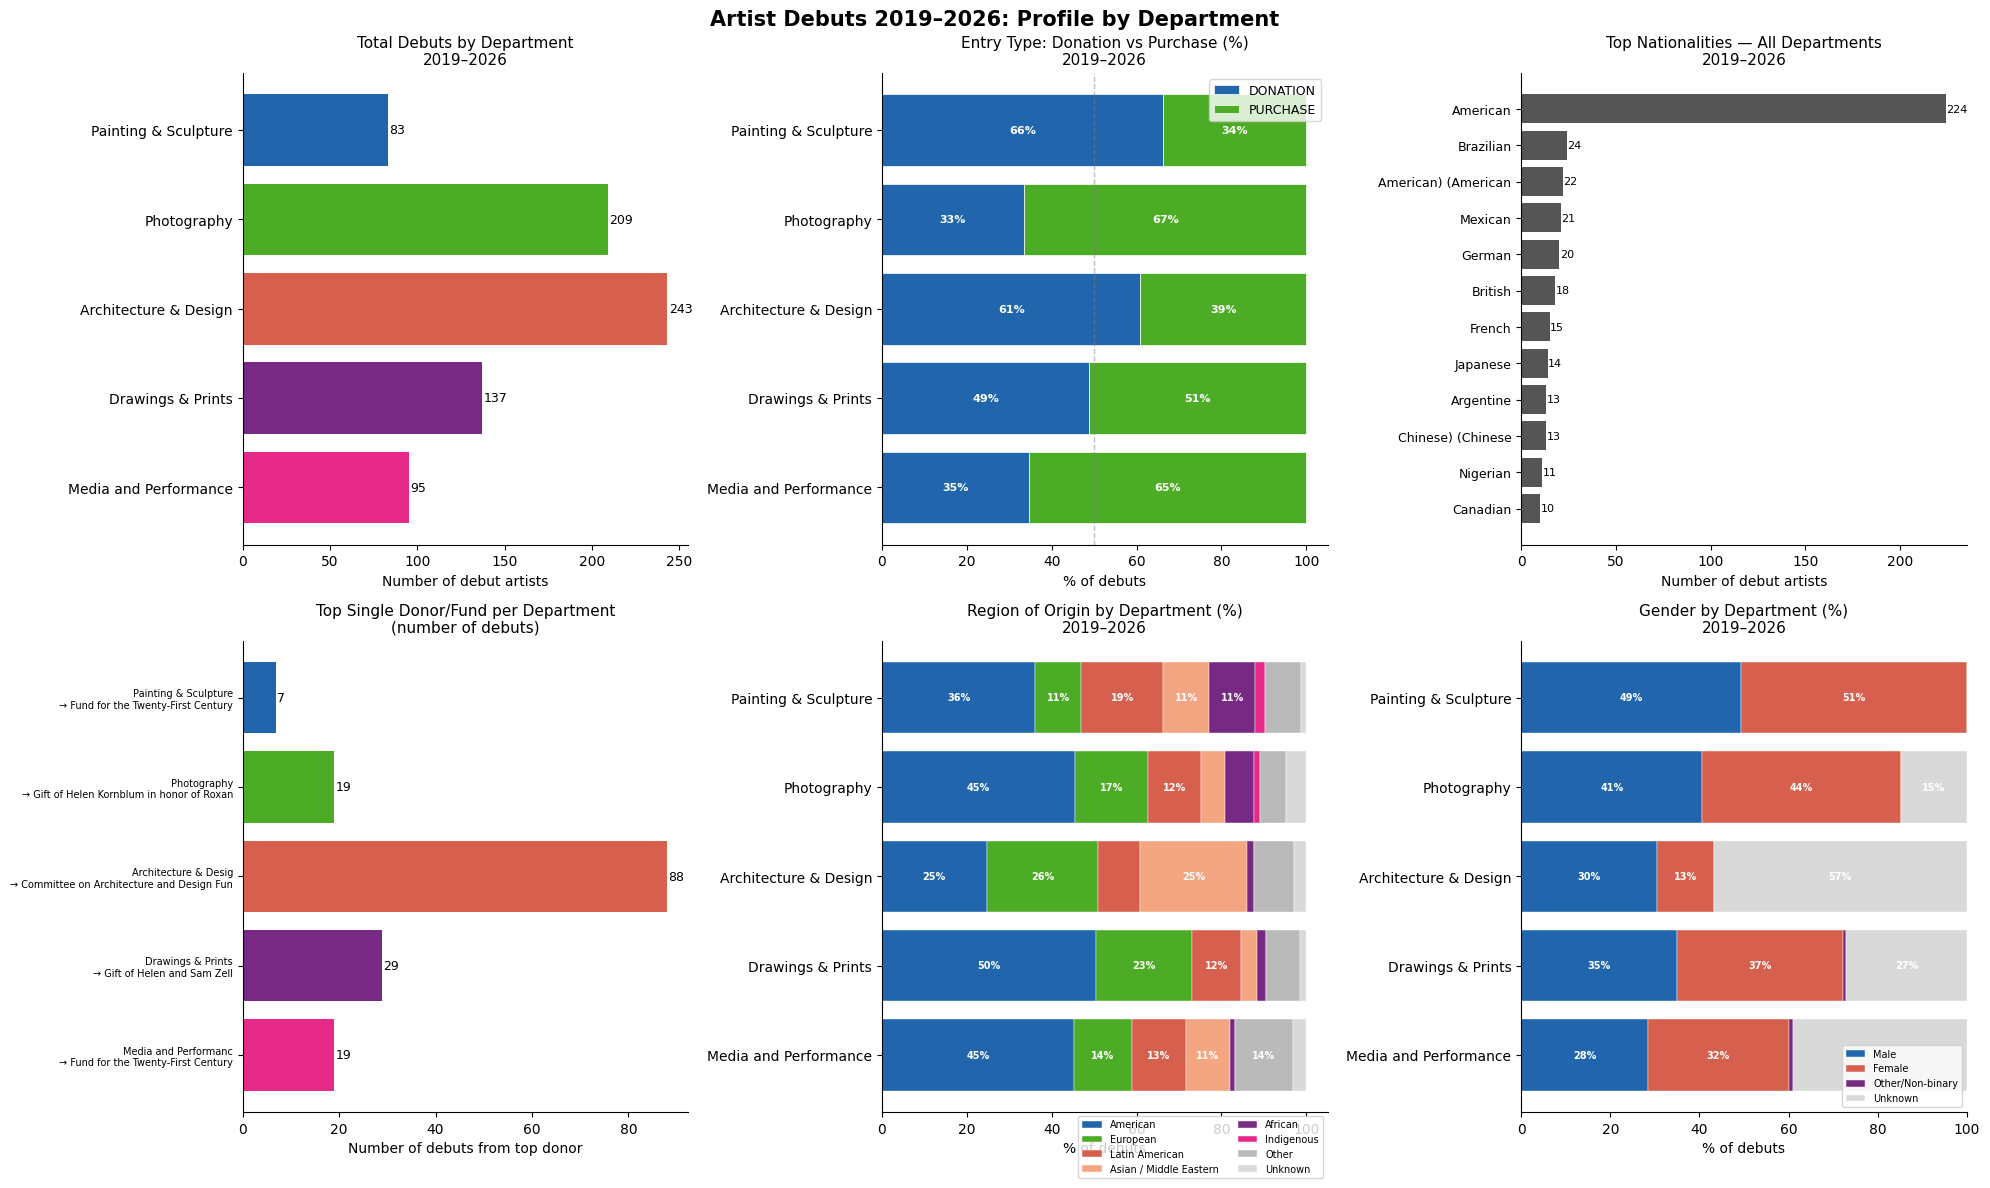

Saved.


In [78]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Artist Debuts 2019–2026: Profile by Department',
             fontsize=15, fontweight='bold')

depts = ['Painting & Sculpture', 'Photography', 'Architecture & Design',
         'Drawings & Prints', 'Media and Performance']

dept_colors = {
    'Painting & Sculpture':  '#2166ac',
    'Photography':           '#4dac26',
    'Architecture & Design': '#d6604d',
    'Drawings & Prints':     '#762a83',
    'Media and Performance': '#e7298a'
}

post2019 = first[first['YearAcquired'] >= 2019].copy()

# ── Chart 1: Total debuts by department ──
ax1 = axes[0, 0]
dept_totals = post2019['Department'].value_counts().reindex(depts, fill_value=0)
colors = [dept_colors[d] for d in depts]
bars = ax1.barh(depts, dept_totals.values, color=colors)
ax1.set_title('Total Debuts by Department\n2019–2026', fontsize=11)
ax1.set_xlabel('Number of debut artists')
ax1.invert_yaxis()
for bar, val in zip(bars, dept_totals.values):
    ax1.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=9)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ── Chart 2: Donation vs Purchase by department ──
ax2 = axes[0, 1]
dept_acq = post2019.groupby(['Department', 'AcquisitionFinal']).size().unstack(fill_value=0)
dept_acq = dept_acq.reindex(depts, fill_value=0)
for col in ['DONATION', 'PURCHASE']:
    if col not in dept_acq.columns:
        dept_acq[col] = 0

dept_acq_pct = dept_acq[['DONATION','PURCHASE']].div(
    dept_acq[['DONATION','PURCHASE']].sum(axis=1), axis=0) * 100

bottom = [0] * len(depts)
for acq_type, color in [('DONATION','#2166ac'), ('PURCHASE','#4dac26')]:
    vals = dept_acq_pct[acq_type].reindex(depts, fill_value=0).values
    bars = ax2.barh(depts, vals, left=bottom,
                    color=color, label=acq_type,
                    edgecolor='white', linewidth=0.5)
    for bar, val, b in zip(bars, vals, bottom):
        if val > 8:
            ax2.text(b + val/2, bar.get_y() + bar.get_height()/2,
                     f'{val:.0f}%', ha='center', va='center',
                     fontsize=8, color='white', fontweight='bold')
    bottom = [b + v for b, v in zip(bottom, vals)]

ax2.set_title('Entry Type: Donation vs Purchase (%)\n2019–2026', fontsize=11)
ax2.set_xlabel('% of debuts')
ax2.invert_yaxis()
ax2.axvline(50, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax2.legend(fontsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# ── Chart 3: Top nationalities overall ──
ax3 = axes[0, 2]
post2019_clean = post2019[post2019['NationalityClean'] != '']
top_nats = post2019_clean['NationalityClean'].value_counts().head(12)
bars = ax3.barh(range(len(top_nats)), top_nats.values, color='#555555')
ax3.set_yticks(range(len(top_nats)))
ax3.set_yticklabels(top_nats.index, fontsize=9)
ax3.invert_yaxis()
ax3.set_title('Top Nationalities — All Departments\n2019–2026', fontsize=11)
ax3.set_xlabel('Number of debut artists')
for bar, val in zip(bars, top_nats.values):
    ax3.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=8)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# ── Chart 4: Top donor/creditline per department ──
ax4 = axes[1, 0]
top_donors_per_dept = []
for dept in depts:
    dept_data = post2019[post2019['Department'] == dept]
    top = dept_data['CreditLine'].value_counts().head(1)
    if len(top) > 0:
        donor = top.index[0][:40]
        count = top.values[0]
        top_donors_per_dept.append((dept, donor, count))

depts_plot = [x[0] for x in top_donors_per_dept]
donors_plot = [x[1] for x in top_donors_per_dept]
counts_plot = [x[2] for x in top_donors_per_dept]
colors_plot = [dept_colors[d] for d in depts_plot]

bars = ax4.barh(range(len(depts_plot)), counts_plot, color=colors_plot)
ax4.set_yticks(range(len(depts_plot)))
ax4.set_yticklabels([f"{d[:20]}\n→ {don}" 
                     for d, don in zip(depts_plot, donors_plot)], fontsize=7)
ax4.invert_yaxis()
ax4.set_title('Top Single Donor/Fund per Department\n(number of debuts)', fontsize=11)
ax4.set_xlabel('Number of debuts from top donor')
for bar, val in zip(bars, counts_plot):
    ax4.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=9)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

# ── Chart 5: Region of origin by department ──
ax5 = axes[1, 1]

def classify_region(nat):
    if pd.isna(nat) or nat.strip() == '':
        return 'Unknown'
    nat = nat.lower()
    if 'american' in nat and not any(x in nat for x in ['latin','south','central']):
        return 'American'
    elif any(x in nat for x in ['british','german','french','dutch','swiss',
                                  'italian','spanish','belgian','swedish',
                                  'norwegian','danish','austrian','polish',
                                  'czech','hungarian','greek','portuguese',
                                  'irish','finnish','romanian']):
        return 'European'
    elif any(x in nat for x in ['brazilian','mexican','colombian','argentine',
                                  'peruvian','chilean','venezuelan','cuban',
                                  'salvadoran','uruguayan','bolivian']):
        return 'Latin American'
    elif any(x in nat for x in ['chinese','japanese','korean','indian',
                                  'vietnamese','thai','indonesian','iranian',
                                  'turkish','pakistani','bangladeshi']):
        return 'Asian / Middle Eastern'
    elif any(x in nat for x in ['nigerian','ghanaian','kenyan','south african',
                                  'congolese','senegalese','egyptian','malian',
                                  'beninese','ivorian','cameroonian']):
        return 'African'
    elif any(x in nat for x in ['native american','hmong','kalaaleq',
                                  'anmatyerr','ivatan','indigenous']):
        return 'Indigenous'
    else:
        return 'Other'

post2019['Region'] = post2019['NationalityClean'].apply(classify_region)

region_colors = {
    'American':              '#2166ac',
    'European':              '#4dac26',
    'Latin American':        '#d6604d',
    'Asian / Middle Eastern':'#f4a582',
    'African':               '#762a83',
    'Indigenous':            '#e7298a',
    'Other':                 '#bababa',
    'Unknown':               '#d9d9d9'
}

dept_region = post2019.groupby(['Department','Region']).size().unstack(fill_value=0)
dept_region = dept_region.reindex(depts, fill_value=0)
dept_region_pct = dept_region.div(dept_region.sum(axis=1), axis=0) * 100

regions = [r for r in region_colors if r in dept_region_pct.columns]
bottom = [0] * len(depts)
for region in regions:
    vals = dept_region_pct[region].values
    bars = ax5.barh(depts, vals, left=bottom,
                    color=region_colors[region], label=region,
                    edgecolor='white', linewidth=0.3)
    for bar, val, b in zip(bars, vals, bottom):
        if val > 10:
            ax5.text(b + val/2, bar.get_y() + bar.get_height()/2,
                     f'{val:.0f}%', ha='center', va='center',
                     fontsize=7, color='white', fontweight='bold')
    bottom = [b + v for b, v in zip(bottom, vals)]

ax5.set_title('Region of Origin by Department (%)\n2019–2026', fontsize=11)
ax5.set_xlabel('% of debuts')
ax5.invert_yaxis()
ax5.legend(fontsize=7, loc='lower right', bbox_to_anchor=(1.0, -0.15),
           ncol=2)
ax5.spines['top'].set_visible(False)
ax5.spines['right'].set_visible(False)

# ── Chart 6: Gender by department ──
ax6 = axes[1, 2]
dept_gender = post2019.groupby(['Department','GenderSimple']).size().unstack(fill_value=0)
dept_gender = dept_gender.reindex(depts, fill_value=0)
dept_gender_pct = dept_gender.div(dept_gender.sum(axis=1), axis=0) * 100

gender_colors = {
    'Male':             '#2166ac',
    'Female':           '#d6604d',
    'Other/Non-binary': '#762a83',
    'Unknown':          '#d9d9d9'
}

genders = [g for g in gender_colors if g in dept_gender_pct.columns]
bottom = [0] * len(depts)
for gender in genders:
    vals = dept_gender_pct[gender].values
    bars = ax6.barh(depts, vals, left=bottom,
                    color=gender_colors[gender], label=gender,
                    edgecolor='white', linewidth=0.3)
    for bar, val, b in zip(bars, vals, bottom):
        if val > 10:
            ax6.text(b + val/2, bar.get_y() + bar.get_height()/2,
                     f'{val:.0f}%', ha='center', va='center',
                     fontsize=7, color='white', fontweight='bold')
    bottom = [b + v for b, v in zip(bottom, vals)]

ax6.set_title('Gender by Department (%)\n2019–2026', fontsize=11)
ax6.set_xlabel('% of debuts')
ax6.invert_yaxis()
ax6.legend(fontsize=7, loc='lower right')
ax6.spines['top'].set_visible(False)
ax6.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('data/debuts_by_department.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [79]:
# Extract curator mentions from CreditLine
print("=== CURATOR MENTIONS IN CREDITLINE ===")

# Known MoMA curators
curators = [
    'Roxana Marcoci', 'Ann Temkin', 'Glenn Lowry', 'Kynaston McShine',
    'Christophe Cherix', 'Jodi Hauptman', 'Stuart Comer', 'Paola Antonelli',
    'Peter Galassi', 'John Szarkowski', 'Deborah Wye', 'Jennifer Winkworth',
    'Barry Bergdoll', 'Leah Dickerman', 'Sarah Suzuki'
]

for curator in curators:
    mask = df['CreditLine'].str.contains(curator, case=False, na=False)
    count = mask.sum()
    if count > 0:
        # By acquisition type
        by_type = df[mask]['AcquisitionFinal'].value_counts()
        # By department
        by_dept = df[mask]['Department'].value_counts().head(2)
        print(f"\n  {curator}: {count:,} works")
        print(f"    Acquisition: {dict(by_type)}")
        print(f"    Departments: {dict(by_dept)}")

=== CURATOR MENTIONS IN CREDITLINE ===

  Roxana Marcoci: 130 works
    Acquisition: {'DONATION': np.int64(122), 'PURCHASE': np.int64(8)}
    Departments: {'Photography': np.int64(129), 'Drawings & Prints': np.int64(1)}

  Ann Temkin: 15 works
    Acquisition: {'DONATION': np.int64(14), 'PURCHASE': np.int64(1)}
    Departments: {'Painting & Sculpture': np.int64(10), 'Drawings & Prints': np.int64(5)}

  Glenn Lowry: 19 works
    Acquisition: {'DONATION': np.int64(15), 'PURCHASE': np.int64(4)}
    Departments: {'Media and Performance': np.int64(7), 'Drawings & Prints': np.int64(6)}

  Kynaston McShine: 598 works
    Acquisition: {'DONATION': np.int64(594), 'PURCHASE': np.int64(4)}
    Departments: {'Photography': np.int64(557), 'Drawings & Prints': np.int64(33)}

  Christophe Cherix: 66 works
    Acquisition: {'PURCHASE': np.int64(37), 'DONATION': np.int64(29)}
    Departments: {'Drawings & Prints': np.int64(64), 'Painting & Sculpture': np.int64(2)}

  Jodi Hauptman: 3 works
    Acquisit

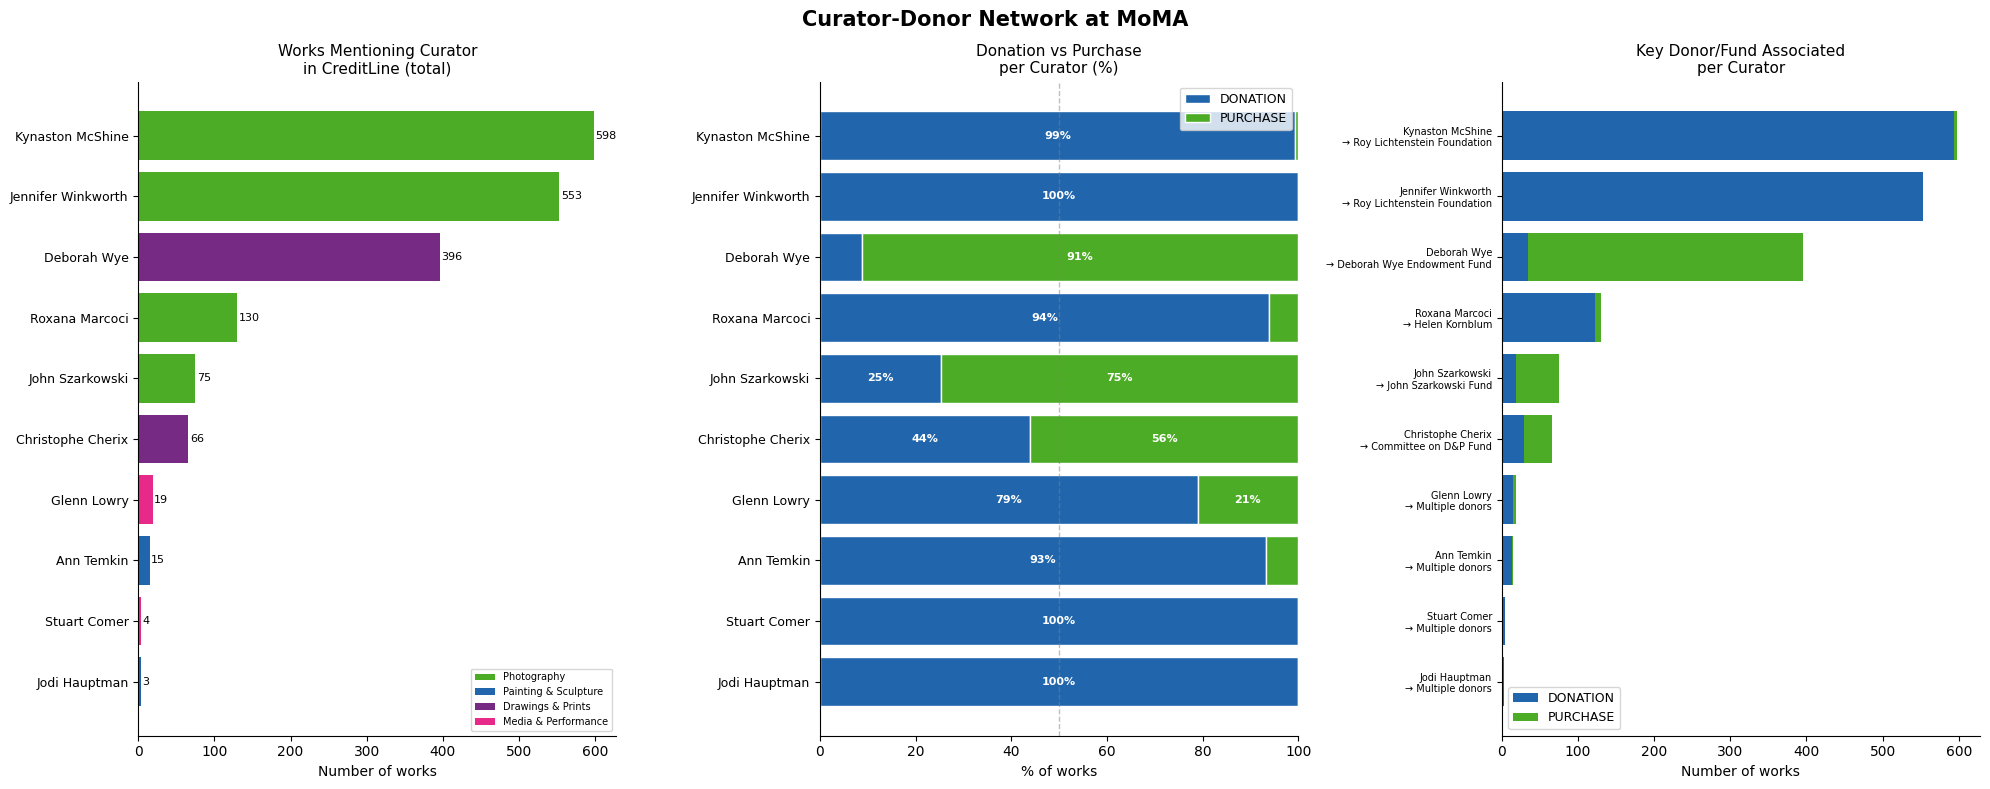

Saved.


In [80]:
fig, axes = plt.subplots(1, 3, figsize=(20, 8))
fig.suptitle('Curator-Donor Network at MoMA', 
             fontsize=15, fontweight='bold')

curators_data = {
    'Roxana Marcoci':    {'total': 130, 'donation': 122, 'purchase': 8,   'dept': 'Photography'},
    'Ann Temkin':        {'total': 15,  'donation': 14,  'purchase': 1,   'dept': 'Painting & Sculpture'},
    'Glenn Lowry':       {'total': 19,  'donation': 15,  'purchase': 4,   'dept': 'Media & Performance'},
    'Kynaston McShine':  {'total': 598, 'donation': 594, 'purchase': 4,   'dept': 'Photography'},
    'Christophe Cherix': {'total': 66,  'donation': 29,  'purchase': 37,  'dept': 'Drawings & Prints'},
    'Jennifer Winkworth':{'total': 553, 'donation': 553, 'purchase': 0,   'dept': 'Photography'},
    'Deborah Wye':       {'total': 396, 'donation': 35,  'purchase': 361, 'dept': 'Drawings & Prints'},
    'John Szarkowski':   {'total': 75,  'donation': 19,  'purchase': 56,  'dept': 'Photography'},
    'Stuart Comer':      {'total': 4,   'donation': 4,   'purchase': 0,   'dept': 'Media & Performance'},
    'Jodi Hauptman':     {'total': 3,   'donation': 3,   'purchase': 0,   'dept': 'Painting & Sculpture'},
}

curators_list = list(curators_data.keys())
totals = [curators_data[c]['total'] for c in curators_list]
donations = [curators_data[c]['donation'] for c in curators_list]
purchases = [curators_data[c]['purchase'] for c in curators_list]
depts = [curators_data[c]['dept'] for c in curators_list]

dept_color_map = {
    'Photography':          '#4dac26',
    'Painting & Sculpture': '#2166ac',
    'Drawings & Prints':    '#762a83',
    'Media & Performance':  '#e7298a',
}

# ── Chart 1: Total works per curator ──
ax1 = axes[0]
colors = [dept_color_map.get(d, '#bababa') for d in depts]
sorted_idx = sorted(range(len(totals)), key=lambda i: totals[i], reverse=True)
sorted_curators = [curators_list[i] for i in sorted_idx]
sorted_totals = [totals[i] for i in sorted_idx]
sorted_colors = [colors[i] for i in sorted_idx]

bars = ax1.barh(range(len(sorted_curators)), sorted_totals, color=sorted_colors)
ax1.set_yticks(range(len(sorted_curators)))
ax1.set_yticklabels(sorted_curators, fontsize=9)
ax1.invert_yaxis()
ax1.set_title('Works Mentioning Curator\nin CreditLine (total)', fontsize=11)
ax1.set_xlabel('Number of works')
for bar, val in zip(bars, sorted_totals):
    ax1.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=8)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Add department legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in dept_color_map.items()]
ax1.legend(handles=legend_elements, fontsize=7, loc='lower right')

# ── Chart 2: Donation vs Purchase per curator ──
ax2 = axes[1]
don_pcts = [d/t*100 for d, t in zip(donations, totals)]
pur_pcts = [p/t*100 for p, t in zip(purchases, totals)]

sorted_don_pcts = [don_pcts[i] for i in sorted_idx]
sorted_pur_pcts = [pur_pcts[i] for i in sorted_idx]

ax2.barh(range(len(sorted_curators)), sorted_don_pcts,
         color='#2166ac', label='DONATION', edgecolor='white')
ax2.barh(range(len(sorted_curators)), sorted_pur_pcts,
         left=sorted_don_pcts, color='#4dac26', 
         label='PURCHASE', edgecolor='white')

for i, (d, p) in enumerate(zip(sorted_don_pcts, sorted_pur_pcts)):
    if d > 10:
        ax2.text(d/2, i, f'{d:.0f}%', ha='center', va='center',
                 fontsize=8, color='white', fontweight='bold')
    if p > 10:
        ax2.text(d + p/2, i, f'{p:.0f}%', ha='center', va='center',
                 fontsize=8, color='white', fontweight='bold')

ax2.set_yticks(range(len(sorted_curators)))
ax2.set_yticklabels(sorted_curators, fontsize=9)
ax2.invert_yaxis()
ax2.axvline(50, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax2.set_title('Donation vs Purchase\nper Curator (%)', fontsize=11)
ax2.set_xlabel('% of works')
ax2.legend(fontsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# ── Chart 3: Key donor per curator ──
ax3 = axes[2]

curator_donors = {
    'Kynaston McShine':   'Roy Lichtenstein Foundation',
    'Jennifer Winkworth': 'Roy Lichtenstein Foundation',
    'Deborah Wye':        'Deborah Wye Endowment Fund',
    'John Szarkowski':    'John Szarkowski Fund',
    'Roxana Marcoci':     'Helen Kornblum',
    'Christophe Cherix':  'Committee on D&P Fund',
    'Glenn Lowry':        'Multiple donors',
    'Ann Temkin':         'Multiple donors',
    'Stuart Comer':       'Multiple donors',
    'Jodi Hauptman':      'Multiple donors',
}

sorted_donors = [curator_donors[c] for c in sorted_curators]
sorted_don_abs = [donations[i] for i in sorted_idx]
sorted_pur_abs = [purchases[i] for i in sorted_idx]

ax3.barh(range(len(sorted_curators)), sorted_don_abs,
         color='#2166ac', label='DONATION')
ax3.barh(range(len(sorted_curators)), sorted_pur_abs,
         left=sorted_don_abs, color='#4dac26', label='PURCHASE')

ax3.set_yticks(range(len(sorted_curators)))
ax3.set_yticklabels([f"{c}\n→ {curator_donors[c]}" 
                     for c in sorted_curators], fontsize=7)
ax3.invert_yaxis()
ax3.set_title('Key Donor/Fund Associated\nper Curator', fontsize=11)
ax3.set_xlabel('Number of works')
ax3.legend(fontsize=9)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('data/curator_donor_network.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [81]:
# Curator-donor network post-2019
print("=== CURATOR MENTIONS IN CREDITLINE — POST-2019 ===")

curators = [
    'Roxana Marcoci', 'Ann Temkin', 'Glenn Lowry', 'Kynaston McShine',
    'Christophe Cherix', 'Jodi Hauptman', 'Stuart Comer', 'Paola Antonelli',
    'Peter Galassi', 'John Szarkowski', 'Deborah Wye', 'Jennifer Winkworth',
    'Barry Bergdoll', 'Leah Dickerman', 'Sarah Suzuki', 'Roxana Marcoci',
    'Adrienne Edwards', 'Ugochukwu-Smooth Nzewi', 'Tobia Bezzola',
    'Natasha Boas', 'Esther Adler', 'Michelle Kuo'
]

post2019_df = df[df['YearAcquired'] >= 2019]
print(f"Total works post-2019: {len(post2019_df):,}")

results = []
for curator in set(curators):
    mask = post2019_df['CreditLine'].str.contains(curator, case=False, na=False)
    count = mask.sum()
    if count > 0:
        by_type = post2019_df[mask]['AcquisitionFinal'].value_counts()
        by_dept = post2019_df[mask]['Department'].value_counts().head(1)
        results.append({
            'curator': curator,
            'total': count,
            'donation': by_type.get('DONATION', 0),
            'purchase': by_type.get('PURCHASE', 0),
            'dept': by_dept.index[0] if len(by_dept) > 0 else 'Unknown'
        })
        print(f"\n  {curator}: {count} works")
        print(f"    Type: {dict(by_type)}")
        print(f"    Dept: {dict(by_dept)}")
        print(f"    Top CreditLines:")
        print(post2019_df[mask]['CreditLine'].value_counts().head(3).to_string())

=== CURATOR MENTIONS IN CREDITLINE — POST-2019 ===
Total works post-2019: 10,529

  John Szarkowski: 23 works
    Type: {'PURCHASE': np.int64(22), 'DONATION': np.int64(1)}
    Dept: {'Photography': np.int64(23)}
    Top CreditLines:
CreditLine
John Szarkowski Fund                              22
Gift of the artist in honor of John Szarkowski     1

  Stuart Comer: 1 works
    Type: {'DONATION': np.int64(1)}
    Dept: {'Photography': np.int64(1)}
    Top CreditLines:
CreditLine
Gift of Thiago Saddi Tannous in honor of Stuart Comer    1

  Deborah Wye: 52 works
    Type: {'PURCHASE': np.int64(52)}
    Dept: {'Drawings & Prints': np.int64(52)}
    Top CreditLines:
CreditLine
Deborah Wye Endowment Fund        39
The Deborah Wye Endowment Fund     7
Deborah Wye Endowment Fund\r\n     3

  Jodi Hauptman: 3 works
    Type: {'DONATION': np.int64(3)}
    Dept: {'Painting & Sculpture': np.int64(2)}
    Top CreditLines:
CreditLine
Gift of Merrill C. Berman and Dalia S. Berman in honor of Jodi Hau

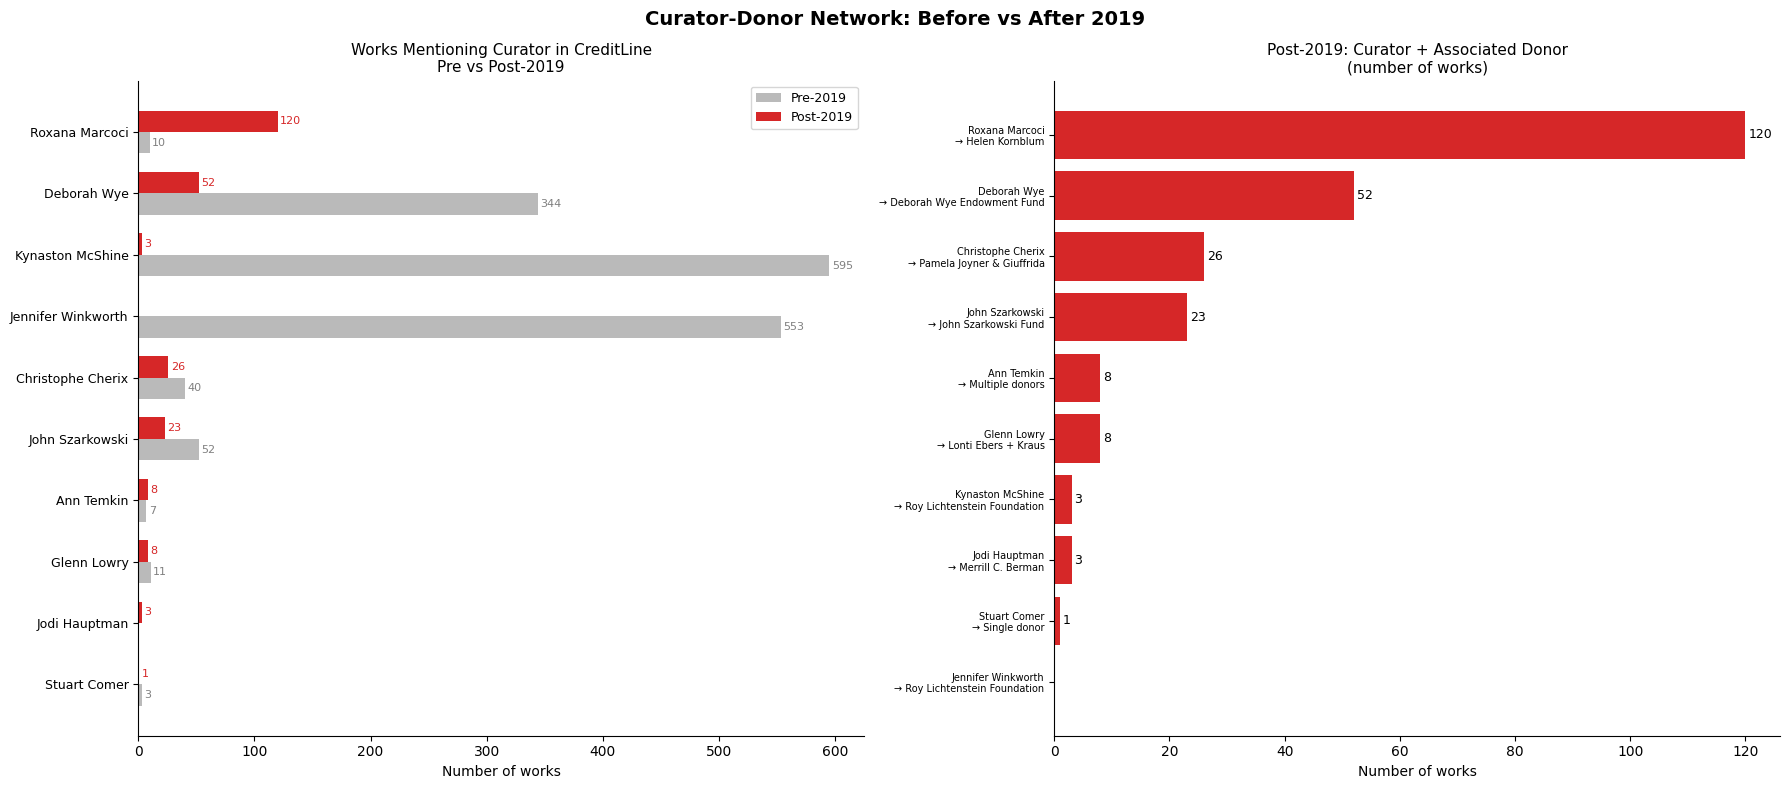

Saved.


In [82]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Curator-Donor Network: Before vs After 2019',
             fontsize=14, fontweight='bold')

# Data for both periods
curators_compare = {
    'Roxana Marcoci':     {'pre': 10,  'post': 120},
    'Deborah Wye':        {'pre': 344, 'post': 52},
    'Kynaston McShine':   {'pre': 595, 'post': 3},
    'Jennifer Winkworth': {'pre': 553, 'post': 0},
    'Christophe Cherix':  {'pre': 40,  'post': 26},
    'John Szarkowski':    {'pre': 52,  'post': 23},
    'Ann Temkin':         {'pre': 7,   'post': 8},
    'Glenn Lowry':        {'pre': 11,  'post': 8},
    'Jodi Hauptman':      {'pre': 0,   'post': 3},
    'Stuart Comer':       {'pre': 3,   'post': 1},
}

key_donors = {
    'Roxana Marcoci':     'Helen Kornblum',
    'Deborah Wye':        'Deborah Wye Endowment Fund',
    'Kynaston McShine':   'Roy Lichtenstein Foundation',
    'Jennifer Winkworth': 'Roy Lichtenstein Foundation',
    'Christophe Cherix':  'Pamela Joyner & Giuffrida',
    'John Szarkowski':    'John Szarkowski Fund',
    'Ann Temkin':         'Multiple donors',
    'Glenn Lowry':        'Lonti Ebers + Kraus',
    'Jodi Hauptman':      'Merrill C. Berman',
    'Stuart Comer':       'Single donor',
}

curators_list = list(curators_compare.keys())
pre_vals = [curators_compare[c]['pre'] for c in curators_list]
post_vals = [curators_compare[c]['post'] for c in curators_list]

# ── Chart 1: Side by side comparison ──
ax1 = axes[0]
x = range(len(curators_list))
width = 0.35

bars_pre = ax1.barh([i + width/2 for i in x], pre_vals,
                    height=width, color='#bababa', label='Pre-2019')
bars_post = ax1.barh([i - width/2 for i in x], post_vals,
                     height=width, color='#d62728', label='Post-2019')

ax1.set_yticks(x)
ax1.set_yticklabels(curators_list, fontsize=9)
ax1.invert_yaxis()
ax1.set_title('Works Mentioning Curator in CreditLine\nPre vs Post-2019', fontsize=11)
ax1.set_xlabel('Number of works')
ax1.legend(fontsize=9)

for bar, val in zip(bars_pre, pre_vals):
    if val > 0:
        ax1.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
                 str(val), va='center', fontsize=8, color='gray')
for bar, val in zip(bars_post, post_vals):
    if val > 0:
        ax1.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
                 str(val), va='center', fontsize=8, color='#d62728')

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ── Chart 2: Key donor per curator + post-2019 volume ──
ax2 = axes[1]

sorted_idx = sorted(range(len(post_vals)), key=lambda i: post_vals[i], reverse=True)
sorted_curators = [curators_list[i] for i in sorted_idx]
sorted_post = [post_vals[i] for i in sorted_idx]
sorted_donors = [key_donors[c] for c in sorted_curators]

bars = ax2.barh(range(len(sorted_curators)), sorted_post, color='#d62728')
ax2.set_yticks(range(len(sorted_curators)))
ax2.set_yticklabels([f"{c}\n→ {key_donors[c]}" 
                     for c in sorted_curators], fontsize=7)
ax2.invert_yaxis()
ax2.set_title('Post-2019: Curator + Associated Donor\n(number of works)', fontsize=11)
ax2.set_xlabel('Number of works')

for bar, val in zip(bars, sorted_post):
    if val > 0:
        ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 str(val), va='center', fontsize=9)

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('data/curator_donor_pre_post_2019.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [83]:
# Of curator mentions — how many are donations vs purchases?
print("=== CURATOR MENTIONS BY ACQUISITION TYPE ===")
curators = ['Roxana Marcoci', 'Ann Temkin', 'Glenn Lowry', 
            'Christophe Cherix', 'Deborah Wye', 'John Szarkowski',
            'Kynaston McShine', 'Jennifer Winkworth']

for curator in curators:
    mask = df['CreditLine'].str.contains(curator, case=False, na=False)
    by_type = df[mask]['AcquisitionFinal'].value_counts()
    print(f"\n{curator}: {mask.sum()} total")
    print(f"  {dict(by_type)}")

=== CURATOR MENTIONS BY ACQUISITION TYPE ===

Roxana Marcoci: 130 total
  {'DONATION': np.int64(122), 'PURCHASE': np.int64(8)}

Ann Temkin: 15 total
  {'DONATION': np.int64(14), 'PURCHASE': np.int64(1)}

Glenn Lowry: 19 total
  {'DONATION': np.int64(15), 'PURCHASE': np.int64(4)}

Christophe Cherix: 66 total
  {'PURCHASE': np.int64(37), 'DONATION': np.int64(29)}

Deborah Wye: 396 total
  {'PURCHASE': np.int64(361), 'DONATION': np.int64(35)}

John Szarkowski: 75 total
  {'PURCHASE': np.int64(56), 'DONATION': np.int64(19)}

Kynaston McShine: 598 total
  {'DONATION': np.int64(594), 'PURCHASE': np.int64(4)}

Jennifer Winkworth: 553 total
  {'DONATION': np.int64(553)}


In [85]:
# Painting & Sculpture debuts 2019-2026 — full profile
ps_debuts = first[
    (first['YearAcquired'] >= 2019) & 
    (first['Department'] == 'Painting & Sculpture')
].copy()

print(f"=== PAINTING & SCULPTURE DEBUTS 2019-2026 ===")
print(f"Total: {len(ps_debuts)}")

print(f"\nBy acquisition type:")
print(ps_debuts['AcquisitionFinal'].value_counts())

print(f"\nBy nationality:")
print(ps_debuts['NationalityClean'].value_counts().head(20).to_string())

print(f"\nBy artwork period:")
print(ps_debuts['ArtworkPeriod'].value_counts())

print(f"\nBy artist status at acquisition:")
print(ps_debuts['ArtistStatus'].value_counts())

print(f"\nBy year of debut:")
print(ps_debuts['YearAcquired'].value_counts().sort_index())

print(f"\nTop CreditLines:")
print(ps_debuts['CreditLine'].value_counts().head(15).to_string())

=== PAINTING & SCULPTURE DEBUTS 2019-2026 ===
Total: 83

By acquisition type:
AcquisitionFinal
DONATION    55
PURCHASE    28
Name: count, dtype: int64

By nationality:
NationalityClean
American      30
Brazilian      6
Argentine      3
Korean         3
French         2
Venezuelan     2
Japanese       2
Congolese      2
Lebanese       2
Belgian        2
German         2
Egyptian       2
Colombian      2
Nigerian       2
Thai           2
Salvadoran     1
Beninese       1
Croatian       1
Canadian       1
               1

By artwork period:
ArtworkPeriod
2010–present    28
1970–1989       25
1945–1969       17
1990–2009        9
1900–1944        4
Name: count, dtype: int64

By artist status at acquisition:
ArtistStatus
Living                     49
Deceased at acquisition    34
Name: count, dtype: int64

By year of debut:
YearAcquired
2019.0    13
2020.0     6
2021.0    18
2022.0    15
2023.0    11
2024.0    16
2025.0     4
Name: count, dtype: int64

Top CreditLines:
CreditLine
Fund for 

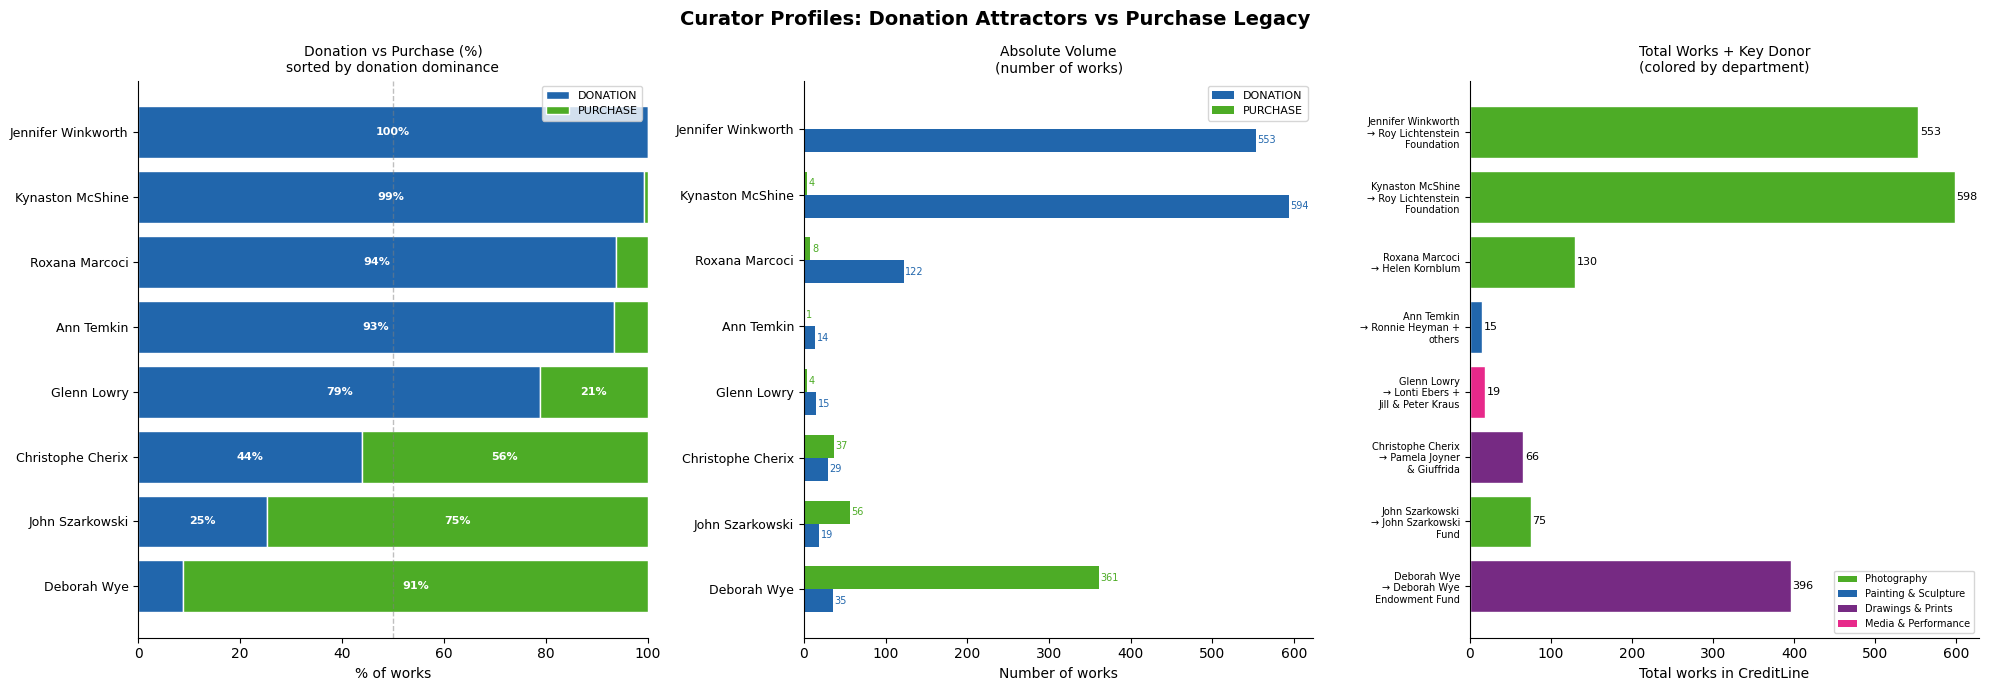

Saved.


In [84]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Curator Profiles: Donation Attractors vs Purchase Legacy',
             fontsize=14, fontweight='bold')

curators_data = {
    'Roxana Marcoci':     {'donation': 122, 'purchase': 8,   'dept': 'Photography'},
    'Ann Temkin':         {'donation': 14,  'purchase': 1,   'dept': 'Painting & Sculpture'},
    'Glenn Lowry':        {'donation': 15,  'purchase': 4,   'dept': 'Media & Performance'},
    'Kynaston McShine':   {'donation': 594, 'purchase': 4,   'dept': 'Photography'},
    'Jennifer Winkworth': {'donation': 553, 'purchase': 0,   'dept': 'Photography'},
    'Christophe Cherix':  {'donation': 29,  'purchase': 37,  'dept': 'Drawings & Prints'},
    'Deborah Wye':        {'donation': 35,  'purchase': 361, 'dept': 'Drawings & Prints'},
    'John Szarkowski':    {'donation': 19,  'purchase': 56,  'dept': 'Photography'},
}

key_donors = {
    'Roxana Marcoci':     'Helen Kornblum',
    'Ann Temkin':         'Ronnie Heyman +\nothers',
    'Glenn Lowry':        'Lonti Ebers +\nJill & Peter Kraus',
    'Kynaston McShine':   'Roy Lichtenstein\nFoundation',
    'Jennifer Winkworth': 'Roy Lichtenstein\nFoundation',
    'Christophe Cherix':  'Pamela Joyner\n& Giuffrida',
    'Deborah Wye':        'Deborah Wye\nEndowment Fund',
    'John Szarkowski':    'John Szarkowski\nFund',
}

curators_list = list(curators_data.keys())
donations = [curators_data[c]['donation'] for c in curators_list]
purchases = [curators_data[c]['purchase'] for c in curators_list]
totals = [d + p for d, p in zip(donations, purchases)]
don_pcts = [d/t*100 for d, t in zip(donations, totals)]
pur_pcts = [p/t*100 for p, t in zip(purchases, totals)]

dept_color_map = {
    'Photography':          '#4dac26',
    'Painting & Sculpture': '#2166ac',
    'Drawings & Prints':    '#762a83',
    'Media & Performance':  '#e7298a',
}
dept_colors = [dept_color_map[curators_data[c]['dept']] for c in curators_list]

# Sort by donation % descending
sorted_idx = sorted(range(len(don_pcts)), key=lambda i: don_pcts[i], reverse=True)
sorted_curators = [curators_list[i] for i in sorted_idx]
sorted_don_pcts = [don_pcts[i] for i in sorted_idx]
sorted_pur_pcts = [pur_pcts[i] for i in sorted_idx]
sorted_totals = [totals[i] for i in sorted_idx]
sorted_donations = [donations[i] for i in sorted_idx]
sorted_purchases = [purchases[i] for i in sorted_idx]
sorted_dept_colors = [dept_colors[i] for i in sorted_idx]

# ── Chart 1: Donation vs Purchase % stacked ──
ax1 = axes[0]
bars_don = ax1.barh(range(len(sorted_curators)), sorted_don_pcts,
                    color='#2166ac', label='DONATION', edgecolor='white')
bars_pur = ax1.barh(range(len(sorted_curators)), sorted_pur_pcts,
                    left=sorted_don_pcts, color='#4dac26',
                    label='PURCHASE', edgecolor='white')

for i, (d, p) in enumerate(zip(sorted_don_pcts, sorted_pur_pcts)):
    if d > 10:
        ax1.text(d/2, i, f'{d:.0f}%', ha='center', va='center',
                 fontsize=8, color='white', fontweight='bold')
    if p > 10:
        ax1.text(d + p/2, i, f'{p:.0f}%', ha='center', va='center',
                 fontsize=8, color='white', fontweight='bold')

ax1.set_yticks(range(len(sorted_curators)))
ax1.set_yticklabels(sorted_curators, fontsize=9)
ax1.invert_yaxis()
ax1.axvline(50, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax1.set_title('Donation vs Purchase (%)\nsorted by donation dominance', fontsize=10)
ax1.set_xlabel('% of works')
ax1.legend(fontsize=8)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ── Chart 2: Absolute volume ──
ax2 = axes[1]
x = range(len(sorted_curators))
width = 0.35
ax2.barh([i + width/2 for i in x], sorted_donations,
         height=width, color='#2166ac', label='DONATION')
ax2.barh([i - width/2 for i in x], sorted_purchases,
         height=width, color='#4dac26', label='PURCHASE')

ax2.set_yticks(x)
ax2.set_yticklabels(sorted_curators, fontsize=9)
ax2.invert_yaxis()
ax2.set_title('Absolute Volume\n(number of works)', fontsize=10)
ax2.set_xlabel('Number of works')
ax2.legend(fontsize=8)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

for i, (d, p) in enumerate(zip(sorted_donations, sorted_purchases)):
    if d > 0:
        ax2.text(d + 2, i + width/2, str(d), va='center', fontsize=7, color='#2166ac')
    if p > 0:
        ax2.text(p + 2, i - width/2, str(p), va='center', fontsize=7, color='#4dac26')

# ── Chart 3: Curator + key donor + department ──
ax3 = axes[2]
bars = ax3.barh(range(len(sorted_curators)), sorted_totals,
                color=sorted_dept_colors, edgecolor='white')

ax3.set_yticks(range(len(sorted_curators)))
ax3.set_yticklabels([f"{c}\n→ {key_donors[c]}"
                     for c in sorted_curators], fontsize=7)
ax3.invert_yaxis()
ax3.set_title('Total Works + Key Donor\n(colored by department)', fontsize=10)
ax3.set_xlabel('Total works in CreditLine')

for bar, val in zip(bars, sorted_totals):
    ax3.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=8)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in dept_color_map.items()]
ax3.legend(handles=legend_elements, fontsize=7, loc='lower right')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('data/curator_profiles.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

KeyError: 'ArtworkPeriod'

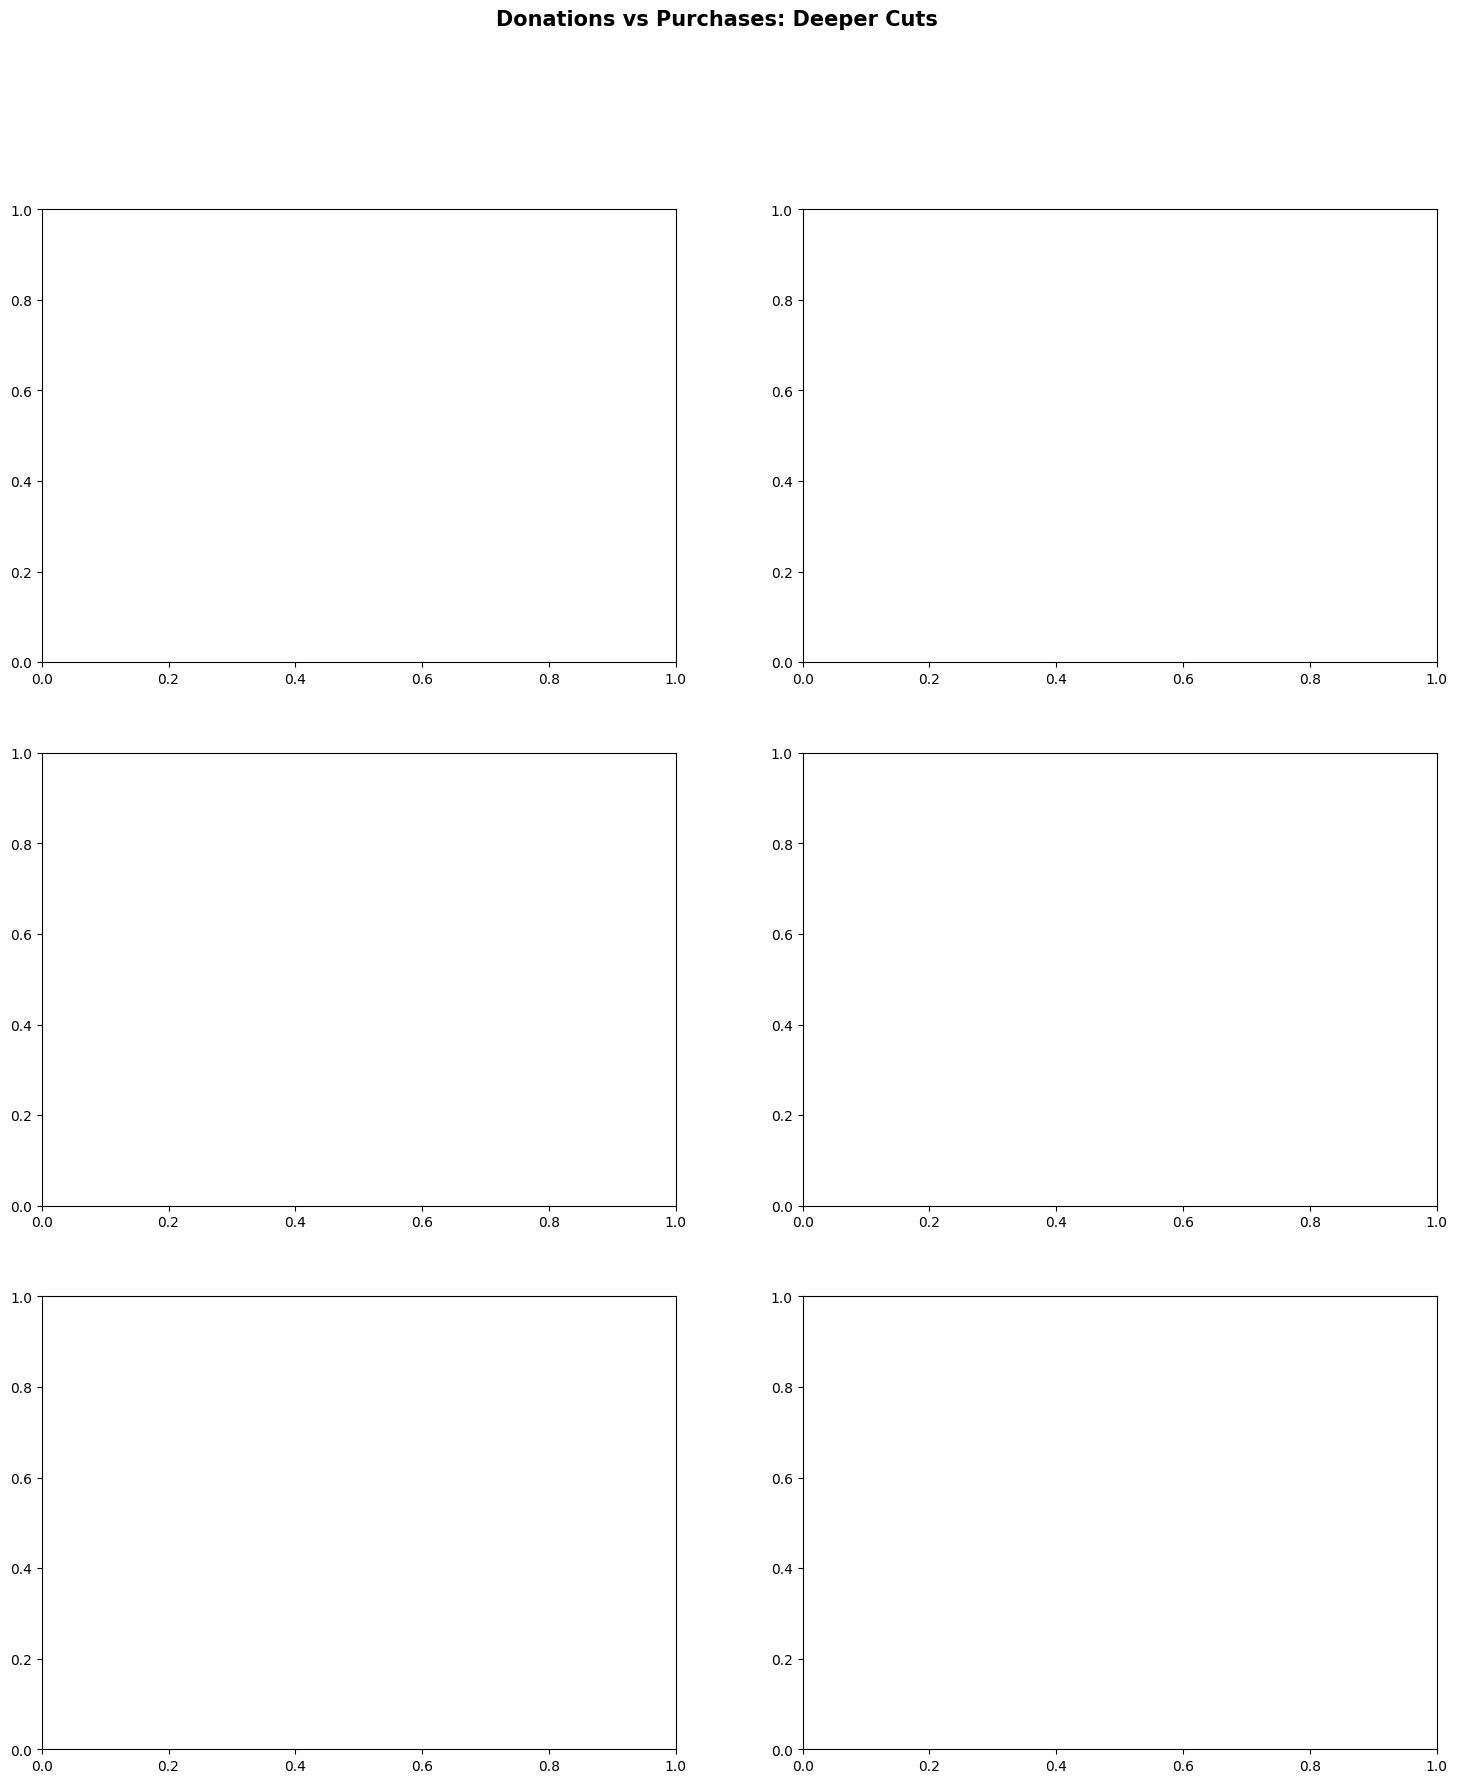

In [45]:
fig, axes = plt.subplots(3, 2, figsize=(18, 20))
fig.suptitle('Donations vs Purchases: Deeper Cuts', fontsize=15, fontweight='bold')

don = df_gender[df_gender['AcquisitionFinal'] == 'DONATION']
pur = df_gender[df_gender['AcquisitionFinal'] == 'PURCHASE']
width = 0.35

# ── Chart 1: Period of artwork (century) ──
ax1 = axes[0, 0]

def classify_century(year):
    if pd.isna(year):
        return 'Unknown'
    elif year < 1800:
        return 'Before 1800'
    elif year < 1900:
        return '19th century'
    elif year < 1945:
        return '1900–1944'
    elif year < 1970:
        return '1945–1969'
    elif year < 1990:
        return '1970–1989'
    elif year < 2010:
        return '1990–2009'
    else:
        return '2010–present'

df_gender['ArtworkPeriod'] = df_gender['ArtworkYear'].apply(classify_century)
periods = ['Before 1800', '19th century', '1900–1944', '1945–1969',
           '1970–1989', '1990–2009', '2010–present', 'Unknown']

don_period = don['ArtworkPeriod'].value_counts(normalize=True).reindex(periods, fill_value=0) * 100
pur_period = pur['ArtworkPeriod'].value_counts(normalize=True).reindex(periods, fill_value=0) * 100

x = range(len(periods))
ax1.bar([i - width/2 for i in x], don_period.values,
        width=width, color='#2166ac', label='DONATION')
ax1.bar([i + width/2 for i in x], pur_period.values,
        width=width, color='#4dac26', label='PURCHASE')
ax1.set_xticks(x)
ax1.set_xticklabels(periods, rotation=45, ha='right', fontsize=8)
ax1.set_title('By Artwork Period (%)', fontsize=11)
ax1.set_ylabel('% within acquisition type')
ax1.legend()
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ── Chart 2: Classification (type of object) ──
ax2 = axes[0, 1]

top_class = df_gender['Classification'].value_counts().head(12).index
don_class = don['Classification'].value_counts(normalize=True).reindex(top_class, fill_value=0) * 100
pur_class = pur['Classification'].value_counts(normalize=True).reindex(top_class, fill_value=0) * 100

x = range(len(top_class))
ax2.barh([i + width/2 for i in x], don_class.values,
         height=width, color='#2166ac', label='DONATION')
ax2.barh([i - width/2 for i in x], pur_class.values,
         height=width, color='#4dac26', label='PURCHASE')
ax2.set_yticks(x)
ax2.set_yticklabels([c[:30] for c in top_class], fontsize=9)
ax2.set_title('By Object Type / Classification — Top 12 (%)', fontsize=11)
ax2.set_xlabel('% within acquisition type')
ax2.legend()
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# ── Chart 3: Artist alive vs dead at time of acquisition ──
ax3 = axes[1, 0]

artists_full = pd.read_csv('collection/Artists.csv')
artists_full['ConstituentID'] = artists_full['ConstituentID'].astype(str)
artists_full['EndDate'] = pd.to_numeric(artists_full['EndDate'], errors='coerce')
artists_full['EndDate'] = artists_full['EndDate'].replace(0, pd.NA)

df_gender2 = df_gender.merge(
    artists_full[['ConstituentID', 'EndDate']], 
    on='ConstituentID', how='left', suffixes=('', '_artist')
)

def artist_status(row):
    if pd.isna(row['EndDate']):
        return 'Living'
    elif pd.isna(row['YearAcquired']):
        return 'Unknown'
    elif row['EndDate'] < row['YearAcquired']:
        return 'Deceased at acquisition'
    else:
        return 'Living'

df_gender2['ArtistStatus'] = df_gender2.apply(artist_status, axis=1)

don2 = df_gender2[df_gender2['AcquisitionFinal'] == 'DONATION']
pur2 = df_gender2[df_gender2['AcquisitionFinal'] == 'PURCHASE']

statuses = ['Living', 'Deceased at acquisition']
don_status = don2['ArtistStatus'].value_counts(normalize=True).reindex(statuses, fill_value=0) * 100
pur_status = pur2['ArtistStatus'].value_counts(normalize=True).reindex(statuses, fill_value=0) * 100

x = range(len(statuses))
bars_don = ax3.bar([i - width/2 for i in x], don_status.values,
                   width=width, color='#2166ac', label='DONATION')
bars_pur = ax3.bar([i + width/2 for i in x], pur_status.values,
                   width=width, color='#4dac26', label='PURCHASE')
ax3.set_xticks(x)
ax3.set_xticklabels(statuses, fontsize=10)
ax3.set_title('Artist Status at Time of Acquisition (%)', fontsize=11)
ax3.set_ylabel('% within acquisition type')
ax3.legend()
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

for i, (d, p) in enumerate(zip(don_status.values, pur_status.values)):
    ax3.text(i - width/2, d + 0.5, f'{d:.1f}%', ha='center', fontsize=9)
    ax3.text(i + width/2, p + 0.5, f'{p:.1f}%', ha='center', fontsize=9)

# ── Chart 4: First entry per artist — donation or purchase? ──
ax4 = axes[1, 1]

first_entry = df_gender.sort_values('YearAcquired').groupby('ConstituentID').first().reset_index()
first_entry = first_entry[first_entry['AcquisitionFinal'].isin(['DONATION', 'PURCHASE'])]

first_counts = first_entry['AcquisitionFinal'].value_counts()
colors_pie = ['#2166ac', '#4dac26']
ax4.pie(first_counts.values, labels=first_counts.index,
        colors=colors_pie, autopct='%1.1f%%', startangle=90)
ax4.set_title("Artist's First Entry into MoMA:\nDonation or Purchase?", fontsize=11)

total = first_counts.sum()
ax4.text(0, -1.4, f'Based on {total:,} artists with known acquisition date',
         ha='center', fontsize=8, style='italic', color='gray')

# ── Chart 5: Donor concentration curve ──
ax5 = axes[2, 0]

donor_counts = don['CreditLine'].value_counts()
total_don = donor_counts.sum()
cumulative = donor_counts.cumsum() / total_don * 100
n_donors = range(1, len(cumulative) + 1)

ax5.plot(list(n_donors), cumulative.values, color='#2166ac', linewidth=2)
ax5.axhline(50, color='gray', linestyle='--', linewidth=1)
ax5.axhline(80, color='gray', linestyle='--', linewidth=1)

# Find how many donors for 50% and 80%
n_50 = (cumulative >= 50).idxmax()
n_80 = (cumulative >= 80).idxmax()
idx_50 = donor_counts.index.get_loc(n_50) + 1
idx_80 = donor_counts.index.get_loc(n_80) + 1

ax5.axvline(idx_50, color='#d6604d', linestyle='--', linewidth=1)
ax5.axvline(idx_80, color='#f4a582', linestyle='--', linewidth=1)
ax5.text(idx_50 + 20, 45, f'{idx_50} donors\n= 50% of donations',
         fontsize=8, color='#d6604d')
ax5.text(idx_80 + 20, 75, f'{idx_80} donors\n= 80% of donations',
         fontsize=8, color='#f4a582')

ax5.set_title('Donor Concentration Curve\n(how many donors account for X% of donations)',
              fontsize=11)
ax5.set_xlabel('Number of unique donors (ranked by volume)')
ax5.set_ylabel('Cumulative % of donated works')
ax5.set_xlim(0, min(2000, len(cumulative)))
ax5.spines['top'].set_visible(False)
ax5.spines['right'].set_visible(False)

# ── Chart 6: Donation vs Purchase by decade — gender female only ──
ax6 = axes[2, 1]

female_don = don[don['GenderSimple'] == 'Female']
female_pur = pur[pur['GenderSimple'] == 'Female']

don_decade = don.groupby('Decade').size()
pur_decade = pur.groupby('Decade').size()
female_don_decade = female_don.groupby('Decade').size()
female_pur_decade = female_pur.groupby('Decade').size()

don_female_pct = (female_don_decade / don_decade * 100).dropna()
pur_female_pct = (female_pur_decade / pur_decade * 100).dropna()

decades = sorted(set(don_female_pct.index) | set(pur_female_pct.index))
decades = [d for d in decades if not pd.isna(d)]
don_vals = [don_female_pct.get(d, 0) for d in decades]
pur_vals = [pur_female_pct.get(d, 0) for d in decades]
decade_labels = [f"{int(d)}s" for d in decades]

ax6.plot(decade_labels, don_vals, color='#2166ac', marker='o',
         linewidth=2, label='DONATION')
ax6.plot(decade_labels, pur_vals, color='#4dac26', marker='o',
         linewidth=2, label='PURCHASE')
ax6.set_title('Female Artists: % of Donations vs Purchases by Decade',
              fontsize=11)
ax6.set_ylabel('% female artists')
ax6.tick_params(axis='x', rotation=45)
ax6.legend()
ax6.spines['top'].set_visible(False)
ax6.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('data/deeper_cuts.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [22]:
# Clean up "the architect" / "the artist" / "the designer" - these are not donors
# Focus on real named donors

def extract_clean_donor(text):
    if pd.isna(text):
        return None
    t = text.lower()
    for pattern in ['gift of ', 'bequest of ', 'purchase of ']:
        if pattern in t:
            idx = t.index(pattern) + len(pattern)
            donor = text[idx:].strip()
            # Skip generic non-names
            if donor.lower().startswith(('the artist', 'the architect', 
                                          'the designer', 'the manufacturer',
                                          'the photographer')):
                return None
            return donor
    return None

df['CleanDonor'] = df['CreditLine'].apply(extract_clean_donor)

print("=== TOP 30 NAMED DONORS ===")
top = df['CleanDonor'].value_counts().head(30)
for donor, count in top.items():
    print(f"  {count:,}x — {donor}")

print("\n=== ACQUISITION TYPE BY DECADE ===")
df['YearAcquired'] = pd.to_datetime(df['DateAcquired'], errors='coerce').dt.year
df['Decade'] = (df['YearAcquired'] // 10 * 10).astype('Int64')

pivot = df.groupby(['Decade', 'AcquisitionType']).size().unstack(fill_value=0)
# Show only main types
main_types = ['Gift', 'Gift of the artist', 'Purchase', 'Fund', 'Bequest']
available = [c for c in main_types if c in pivot.columns]
print(pivot[available].to_string())

print("\n=== POST-2019 ACQUISITIONS: WHO IS GIVING? ===")
recent = df[df['YearAcquired'] >= 2019]
print(f"Total acquisitions 2019-2026: {len(recent):,}")
print(f"\nBy type:")
print(recent['AcquisitionType'].value_counts())
print(f"\nTop donors post-2019:")
print(recent['CleanDonor'].value_counts().head(20))

=== TOP 30 NAMED DONORS ===
  2,733x — Kleiner, Bell & Co.
  2,046x — Jack Shear
  1,889x — Abby Aldrich Rockefeller
  1,688x — The Judith Rothschild Foundation
  1,341x — Peter J. Cohen
  1,084x — Philip Johnson
  952x — Mr. and Mrs. Ralph F. Colin
  723x — Lawrence Benenson and the Committee on Architecture and Design Funds
  648x — Emily Fisher Landau
  553x — the Roy Lichtenstein Foundation in honor of Jennifer Winkworth and Kynaston McShine and in memory of Harry Shunk and János Kender
  529x — Jean Pigozzi
  526x — Lincoln Kirstein
  521x — Helen and Sam Zell
  472x — The Judith Rothschild Foundation (Boris Kerdimun Archive)
  366x — Celeste Bartos
  335x — the Celeste and Armand Bartos Foundation
  332x — Warner Communications, Inc.
  312x — Kleiner, Bell and Co.
  304x — David H. McAlpin
  303x — Chris Lewis
  301x — Edward Steichen
  294x — the Gilbert B. and Lila Silverman Instruction Drawing Collection, Detroit
  287x — Lawrence Benenson
  266x — Lee and Ann Fensterstock, in

In [23]:
# Confirm we are reading the full dataset
print(f"Total rows in dataset: {len(df):,}")
print(f"Total non-null CreditLine: {df['CreditLine'].notna().sum():,}")
print(f"Total non-null DateAcquired: {df['DateAcquired'].notna().sum():,}")

# Jack Shear - full picture
shear = df[df['CreditLine'].str.contains('Jack Shear', na=False)]
print(f"\nJack Shear total works in full dataset: {len(shear):,}")

# Confirm value_counts reads all rows
print(f"\nAcquisitionType counts sum: {df['AcquisitionType'].value_counts().sum():,}")
print(f"Should equal total rows: {len(df):,}")

Total rows in dataset: 160,597
Total non-null CreditLine: 159,241
Total non-null DateAcquired: 155,128

Jack Shear total works in full dataset: 2,316

AcquisitionType counts sum: 160,597
Should equal total rows: 160,597


In [24]:
# Who is Jack Shear in this dataset - full picture
shear = df[df['CreditLine'].str.contains('Jack Shear', na=False)]

print(f"Total works: {len(shear):,}")
print(f"\nFull CreditLine variations:")
print(shear['CreditLine'].value_counts().head(20).to_string())
print(f"\nYear range:")
print(shear['YearAcquired'].value_counts().sort_index().to_string())
print(f"\nDepartments:")
print(shear['Department'].value_counts().to_string())
print(f"\nArtist nationalities:")
print(shear['Nationality'].value_counts().head(20).to_string())

Total works: 2,316

Full CreditLine variations:
CreditLine
Gift of Jack Shear                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      1985
The Merrill C. Berman Collection. Acquired through the generosity of Alice and Tom Tisch, Jo Carole and Ronald S. Lauder, Sue and Edgar Wachenheim III, David Booth, Marlene Hess and James D. Zirin, Marie-Josée and Henry R. Kravis, Jack Shear, the Patricia Bonfield Endowed Acquisition Fund for the Design Collection, Daniel and Jane Och

In [25]:
# What artists did Jack Shear actually donate?
print("=== ARTISTS DONATED BY JACK SHEAR ===")
shear = df[df['CreditLine'].str.contains('Jack Shear', na=False)]
print(shear['Artist'].value_counts().head(30).to_string())

# Is this the Ellsworth Kelly estate?
kelly = df[df['Artist'].str.contains('Ellsworth Kelly', na=False)]
print(f"\n=== ELLSWORTH KELLY IN FULL DATASET ===")
print(f"Total Kelly works: {len(kelly):,}")
print(f"Kelly works from Shear: {len(shear[shear['Artist'].str.contains('Ellsworth Kelly', na=False)]):,}")
print(f"\nKelly CreditLine variations:")
print(kelly['CreditLine'].value_counts().head(10).to_string())

=== ARTISTS DONATED BY JACK SHEAR ===
Artist
Ellsworth Kelly                                                                                1948
Hilma af Klint                                                                                   47
Obiora Udechukwu                                                                                 25
Paula Rego                                                                                       21
Vija Celmins                                                                                     15
Gavin Jantjes                                                                                    13
Bart van der Leck                                                                                10
Kamala Ibrahim Ishag                                                                             10
Gustav Klutsis                                                                                    9
Herbert Bayer                                          